<a href="https://colab.research.google.com/github/sajad95/Flowise/blob/main/moreresultsforPaperFina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Importingt librarries** <a class="anchor" id="1"></a>

[Table of Contents](#0.1)


In [1]:
%pip install tensorflow keras numpy

import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

from sklearn.preprocessing import MinMaxScaler

from google.colab import drive

In [2]:
'''import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pandas import DataFrame
from pandas import concat
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('white')
from sklearn.metrics import mean_absolute_error
from pandas import DataFrame, concat
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
'''

"import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport tensorflow as tf\nfrom pandas import DataFrame\nfrom pandas import concat\nfrom numpy import array\nfrom numpy import hstack\nfrom keras.models import Sequential\nfrom keras.layers import LSTM\nfrom keras.layers import Dense\nfrom google.colab import drive\nimport seaborn as sns\nimport pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n%matplotlib inline\nsns.set_style('white')\nfrom sklearn.metrics import mean_absolute_error\nfrom pandas import DataFrame, concat\nfrom sklearn.ensemble import RandomForestRegressor\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import mean_squared_error\n"

In [3]:
'''import pandas as pd
import numpy as np
from dataclasses import dataclass
import math
import matplotlib.pyplot as plt
import tensorflow as tf
from pandas import DataFrame
from pandas import concat
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from keras.layers import Flatten

from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv2D, MaxPooling2D, Flatten,Conv1D,Dropout,MaxPooling1D,AveragePooling1D
# saving and loading the .h5 model
from keras.models import Model
# define the model architecture
from keras.callbacks import Callback
from keras.callbacks import ReduceLROnPlateau
from keras.optimizers import Adam
from keras.layers import LSTM, Dropout, Dense, Input, Dot, Activation
from keras.layers import SimpleRNN
#####
from keras import backend as K
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
# make the model reproducible Ask Luc
import time
import os
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input
from keras.optimizers import Adam
from keras.losses import Huber
from keras import backend as K
from random import seed'''

'import pandas as pd\nimport numpy as np\nfrom dataclasses import dataclass\nimport math\nimport matplotlib.pyplot as plt\nimport tensorflow as tf\nfrom pandas import DataFrame\nfrom pandas import concat\nfrom numpy import array\nfrom numpy import hstack\nfrom keras.models import Sequential\nfrom keras.layers import LSTM, Dense, Dropout\nfrom keras.models import Sequential\nfrom keras.layers import Flatten\n\nfrom keras.models import Sequential\nfrom keras.layers import Dense, LSTM, Conv2D, MaxPooling2D, Flatten,Conv1D,Dropout,MaxPooling1D,AveragePooling1D\n# saving and loading the .h5 model\nfrom keras.models import Model\n# define the model architecture\nfrom keras.callbacks import Callback\nfrom keras.callbacks import ReduceLROnPlateau\nfrom keras.optimizers import Adam\nfrom keras.layers import LSTM, Dropout, Dense, Input, Dot, Activation\nfrom keras.layers import SimpleRNN\n#####\nfrom keras import backend as K\nfrom keras.optimizers import Adam\nfrom keras.callbacks import Reduce

## **2. Basic Functions** <a class="anchor" id="2"></a>

[Table of Contents](#0.1)

In [4]:
'''class Metric:
    def __init__(self):
        self.metrics = pd.DataFrame(columns=['R-squared', 'MAE', 'MSE', 'CVRMSE', 'Overprediction', 'Underprediction'])

    def add(self, y_true, y_pred):
        residuals = y_true - y_pred
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)
        mae = np.mean(np.abs(residuals))
        mse = np.mean(residuals ** 2)
        rmse = np.sqrt(mse)
        cvrmse = (rmse / np.mean(y_true)) * 100

        overprediction, underprediction = self.over_under_prediction(y_true, y_pred)

        self.metrics.loc[len(self.metrics)] = [r_squared, mae, mse, cvrmse, overprediction, underprediction]

    def get(self):
        return self.metrics

    def over_under_prediction(self, y_true, y_pred):
        overprediction = np.mean(np.where(y_pred > y_true, 1, 0))
        underprediction = np.mean(np.where(y_pred < y_true, 1, 0))
        return overprediction, underprediction
'''


"class Metric:\n    def __init__(self):\n        self.metrics = pd.DataFrame(columns=['R-squared', 'MAE', 'MSE', 'CVRMSE', 'Overprediction', 'Underprediction'])\n\n    def add(self, y_true, y_pred):\n        residuals = y_true - y_pred\n        ss_res = np.sum(residuals ** 2)\n        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)\n        r_squared = 1 - (ss_res / ss_tot)\n        mae = np.mean(np.abs(residuals))\n        mse = np.mean(residuals ** 2)\n        rmse = np.sqrt(mse)\n        cvrmse = (rmse / np.mean(y_true)) * 100\n\n        overprediction, underprediction = self.over_under_prediction(y_true, y_pred)\n\n        self.metrics.loc[len(self.metrics)] = [r_squared, mae, mse, cvrmse, overprediction, underprediction]\n\n    def get(self):\n        return self.metrics\n\n    def over_under_prediction(self, y_true, y_pred):\n        overprediction = np.mean(np.where(y_pred > y_true, 1, 0))\n        underprediction = np.mean(np.where(y_pred < y_true, 1, 0))\n        return overp

In [5]:
'''
class MetricsPlotter:
    def __init__(self, metric_obj):
        """
        Initialize with a Metric instance.
        """
        self.metrics = metric_obj.get()

    def plot(self, title="Model Performance Metrics"):
        """
        Plots all metrics recorded in the Metric instance.
        """
        if self.metrics.empty:
            print("No metrics to plot.")
            return

        # Create subplots dynamically based on number of metrics
        num_metrics = self.metrics.shape[1]
        fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 3 * num_metrics), sharex=True)
        if num_metrics == 1:
            axes = [axes]  # make iterable if only one metric

        for ax, column in zip(axes, self.metrics.columns):
            ax.plot(self.metrics.index, self.metrics[column], marker='o', label=column)
            ax.set_ylabel(column)
            ax.legend(loc='best')
            ax.grid(True, linestyle='--', alpha=0.5)

        axes[-1].set_xlabel("Run / Epoch")
        fig.suptitle(title, fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()
'''

'\nclass MetricsPlotter:\n    def __init__(self, metric_obj):\n        """\n        Initialize with a Metric instance.\n        """\n        self.metrics = metric_obj.get()\n\n    def plot(self, title="Model Performance Metrics"):\n        """\n        Plots all metrics recorded in the Metric instance.\n        """\n        if self.metrics.empty:\n            print("No metrics to plot.")\n            return\n\n        # Create subplots dynamically based on number of metrics\n        num_metrics = self.metrics.shape[1]\n        fig, axes = plt.subplots(num_metrics, 1, figsize=(10, 3 * num_metrics), sharex=True)\n        if num_metrics == 1:\n            axes = [axes]  # make iterable if only one metric\n\n        for ax, column in zip(axes, self.metrics.columns):\n            ax.plot(self.metrics.index, self.metrics[column], marker=\'o\', label=column)\n            ax.set_ylabel(column)\n            ax.legend(loc=\'best\')\n            ax.grid(True, linestyle=\'--\', alpha=0.5)\n\n     

use the metric and its plotter

```
metric = Metric()

# Simulate adding some results
for i in range(10):
    y_true = np.random.rand(100)
    y_pred = y_true + np.random.normal(0, 0.05, 100)
    metric.add(y_true, y_pred)

# Plot results
plotter = MetricsPlotter(metric)
plotter.plot("Model Evaluation Over Multiple Runs")
```



In [6]:
# Splitting the data

def split_sequences(sequences, n_steps_in, n_steps_out):
	X, y = list(), list()
	for i in range(len(sequences)):
		# find the end of this pattern
		end_ix = i + n_steps_in
		out_end_ix = end_ix + n_steps_out
		# check if we are beyond the dataset
		if out_end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix:out_end_ix, -1]
		X.append(seq_x)
		y.append(seq_y)
	return array(X), array(y)

# Data is splitted with thime (Miroslava)

import pandas as pd


def split_data(series):
    """
    Splits input series into train and test sets (80/20 split).

    Args:
        series: The input series or DataFrame to split.

    Returns:
        train_data: 80% of the data for training.
        test_data: 20% of the data for testing.
    """
    # Calculate the index for the split
    split_index = int(len(series) * 0.8)

    # Split the data
    train_data = series[:split_index]
    test_data = series[split_index:]

    return train_data, test_data


In [7]:
# stop the randomness
np.random.seed(1)
tf.random.set_seed(2)

## Reading merged data

In [8]:
# mounting google drive and uploading the data
drive.mount('/content/saj')

Mounted at /content/saj


In [9]:
from pathlib import Path

folder = Path('/content/saj/MyDrive/DataElecOntario/ISO/Ontario New data /Weather files of Ontario')

city_file_map = {
    'Toronto'   : 'Toronto',
    'Kitchener' : 'Kitchener',
    'Niagara'   : 'Niagara Falls',   # note the space in the real file name
    'Ottawa'    : 'Ottawa',
    'Sudbury'   : 'Sudbury',
}

df_all = {
    city: pd.read_csv(folder / f'{filename}.csv')
    for city, filename in city_file_map.items()
}

# Example:
print(df_all['Toronto'].head())
print(df_all['Niagara'].shape)

              datetime  humidity  precip  windspeed  sealevelpressure  \
0  2015-01-01T00:00:00     50.98     0.0       41.9            1016.1   
1  2015-01-01T01:00:00     49.43     0.0       12.3            1015.1   
2  2015-01-01T02:00:00     53.74     0.0       43.9            1014.8   
3  2015-01-01T03:00:00     56.60     0.0       31.3            1014.9   
4  2015-01-01T04:00:00     58.50     0.0       35.0            1014.1   

   cloudcover  solarradiation  temp  Toronto  Essa  
0         0.0             0.0  -6.5     5317  1040  
1        97.8             0.0  -6.4     5135   995  
2         0.9             0.0  -6.6     4976   957  
3        30.0             0.0  -6.5     4851   933  
4        50.0             0.0  -6.5     4789   929  
(78887, 9)


In [10]:
df_all

{'Toronto':                   datetime  humidity  precip  windspeed  sealevelpressure  \
 0      2015-01-01T00:00:00     50.98   0.000       41.9            1016.1   
 1      2015-01-01T01:00:00     49.43   0.000       12.3            1015.1   
 2      2015-01-01T02:00:00     53.74   0.000       43.9            1014.8   
 3      2015-01-01T03:00:00     56.60   0.000       31.3            1014.9   
 4      2015-01-01T04:00:00     58.50   0.000       35.0            1014.1   
 ...                    ...       ...     ...        ...               ...   
 78882  2023-12-31T18:00:00     86.17   0.000       31.0            1015.3   
 78883  2023-12-31T19:00:00     87.98   0.198       27.1            1015.7   
 78884  2023-12-31T20:00:00     90.63   0.241       25.5            1015.9   
 78885  2023-12-31T21:00:00     93.39   0.241       27.2            1016.0   
 78886  2023-12-31T22:00:00     89.74   0.270       25.4            1016.2   
 
        cloudcover  solarradiation  temp  Toronto  

In [11]:
df_all['Toronto'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          78887 non-null  object 
 1   humidity          78887 non-null  float64
 2   precip            78887 non-null  float64
 3   windspeed         78887 non-null  float64
 4   sealevelpressure  78887 non-null  float64
 5   cloudcover        78871 non-null  float64
 6   solarradiation    78871 non-null  float64
 7   temp              78887 non-null  float64
 8   Toronto           78887 non-null  int64  
 9   Essa              78887 non-null  int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 6.0+ MB


In [12]:
# Imputting the data

# Simple linear interpolation for all DataFrames in df_all
for city, df in df_all.items():

    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.set_index('datetime').sort_index()

    # Apply linear interpolation to all numeric columns
    df_all[city] = df.interpolate(method='linear', limit_direction='both').reset_index()

In [13]:
df_all['Ottawa'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          78887 non-null  datetime64[ns]
 1   humidity          78887 non-null  float64       
 2   precip            78887 non-null  float64       
 3   windspeed         78887 non-null  float64       
 4   sealevelpressure  78887 non-null  float64       
 5   cloudcover        78887 non-null  float64       
 6   solarradiation    78887 non-null  float64       
 7   temp              78887 non-null  float64       
 8   Ottawa            78887 non-null  int64         
 9   East              78887 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2)
memory usage: 6.0 MB


In [14]:
# Your function (slightly improved to work directly on DataFrame column)
def make_time_features(df, time_col='datetime'):
    times = pd.to_datetime(df[time_col])
    datetimes = pd.DatetimeIndex(times)

    df['hour']   = datetimes.hour
    df['dayofw'] = datetimes.dayofweek   # 0 = Monday, 6 = Sunday
    df['month']  = datetimes.month
    return df

# ------------------------------------------------------------------
# Apply to ALL cities in df_all
# ------------------------------------------------------------------
for city, df in df_all.items():
    # 1. Ensure datetime column exists and is parsed
    if 'datetime' not in df.columns:
        raise ValueError(f"Column 'datetime' not found in {city} DataFrame")

    df['datetime'] = pd.to_datetime(df['datetime'])

    # 2. Format datetime as "2015-01-01T00:00:00" (ISO with T)
    df['datetime'] = df['datetime'].dt.strftime('%Y-%m-%dT%H:%M:%S')

    # 3. Re-parse it back (so pandas knows it's datetime again for feature extraction)
    df['datetime'] = pd.to_datetime(df['datetime'])

    # 4. Add time features
    df_all[city] = make_time_features(df, time_col='datetime')



In [15]:
df_all['Sudbury'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        78887 non-null  datetime64[ns]
 1   temp            78887 non-null  float64       
 2   humidity        78887 non-null  float64       
 3   precip          78887 non-null  float64       
 4   windspeed       78887 non-null  float64       
 5   cloudcover      78887 non-null  float64       
 6   solarradiation  78887 non-null  float64       
 7   Northwest       78887 non-null  int64         
 8   Northeast       78887 non-null  int64         
 9   West            78887 non-null  int64         
 10  hour            78887 non-null  int32         
 11  dayofw          78887 non-null  int32         
 12  month           78887 non-null  int32         
dtypes: datetime64[ns](1), float64(6), int32(3), int64(3)
memory usage: 6.9 MB


In [16]:
East = df_all['Ottawa'].drop(columns = ['Ottawa'])
Ottawa = df_all['Ottawa'].drop(columns = ['East'])

Toronto = df_all['Toronto'].drop(columns = ['Essa'])
Essa = df_all['Toronto'].drop(columns = ['Toronto'])

Southwest = df_all['Kitchener'].drop(columns = ['West'])

West = df_all['Sudbury'].drop(columns = ['Northwest','Northeast'])

Northwest = df_all['Sudbury'].drop(columns = ['Northeast','West'])

Northeast = df_all['Sudbury'].drop(columns = ['Northwest','West'])

Niagara = df_all['Niagara']

In [17]:
# Extract each region's energy column using the datetime column
energy_data = {}

# Helper function to extract energy column with datetime
def extract_energy(df_source, region_name):
    if region_name in df_source.columns and 'datetime' in df_source.columns:
        df_temp = df_source[['datetime', region_name]].copy()
        df_temp.set_index('datetime', inplace=True)
        return df_temp[region_name]
    return None

# Extract each region
energy_data['East'] = extract_energy(df_all['Ottawa'], 'East')
energy_data['Ottawa'] = extract_energy(df_all['Ottawa'], 'Ottawa')
energy_data['Toronto'] = extract_energy(df_all['Toronto'], 'Toronto')
energy_data['Essa'] = extract_energy(df_all['Toronto'], 'Essa')
energy_data['Southwest'] = extract_energy(df_all['Kitchener'], 'Southwest')
energy_data['West'] = extract_energy(df_all['Sudbury'], 'West')
energy_data['Northwest'] = extract_energy(df_all['Sudbury'], 'Northwest')
energy_data['Northeast'] = extract_energy(df_all['Sudbury'], 'Northeast')
energy_data['Niagara'] = extract_energy(df_all['Niagara'], 'Niagara')

# Remove None values
energy_data = {k: v for k, v in energy_data.items() if v is not None}

# Combine into single DataFrame with datetime as index
if energy_data:
    df_energy = pd.DataFrame(energy_data)

    # Ensure datetime index is properly formatted (only if needed)
    if not isinstance(df_energy.index, pd.DatetimeIndex):
        df_energy.index = pd.to_datetime(df_energy.index, errors='coerce')

    print(f"Energy DataFrame created with shape: {df_energy.shape}")
    print(f"Date range: {df_energy.index.min()} to {df_energy.index.max()}")
    print(f"Columns: {list(df_energy.columns)}")
    print(f"\nFirst few rows:")
    print(df_energy.head())

Energy DataFrame created with shape: (78887, 9)
Date range: 2015-01-01 00:00:00 to 2023-12-31 22:00:00
Columns: ['East', 'Ottawa', 'Toronto', 'Essa', 'Southwest', 'West', 'Northwest', 'Northeast', 'Niagara']

First few rows:
                     East  Ottawa  Toronto  Essa  Southwest  West  Northwest  \
datetime                                                                       
2015-01-01 00:00:00   935    1026     5317  1040       2881  1346        604   
2015-01-01 01:00:00   911     988     5135   995       2784  1289        597   
2015-01-01 02:00:00   900     966     4976   957       2679  1249        592   
2015-01-01 03:00:00   903     954     4851   933       2576  1221        590   
2015-01-01 04:00:00   904     954     4789   929       2543  1217        585   

                     Northeast  Niagara  
datetime                                 
2015-01-01 00:00:00       1314      411  
2015-01-01 01:00:00       1282      388  
2015-01-01 02:00:00       1280      372  
2015

In [18]:
# Add Ontario column as the sum of all energy columns
df_energy['Ontario'] = df_energy.sum(axis=1)

print(f"\nAdded 'Ontario' column (sum of all regions)")
print(f"Updated DataFrame shape: {df_energy.shape}")
print(f"Columns: {list(df_energy.columns)}")
print(f"\nFirst few rows with Ontario column:")
print(df_energy.head())


Added 'Ontario' column (sum of all regions)
Updated DataFrame shape: (78887, 10)
Columns: ['East', 'Ottawa', 'Toronto', 'Essa', 'Southwest', 'West', 'Northwest', 'Northeast', 'Niagara', 'Ontario']

First few rows with Ontario column:
                     East  Ottawa  Toronto  Essa  Southwest  West  Northwest  \
datetime                                                                       
2015-01-01 00:00:00   935    1026     5317  1040       2881  1346        604   
2015-01-01 01:00:00   911     988     5135   995       2784  1289        597   
2015-01-01 02:00:00   900     966     4976   957       2679  1249        592   
2015-01-01 03:00:00   903     954     4851   933       2576  1221        590   
2015-01-01 04:00:00   904     954     4789   929       2543  1217        585   

                     Northeast  Niagara  Ontario  
datetime                                          
2015-01-01 00:00:00       1314      411    14874  
2015-01-01 01:00:00       1282      388    14369  


In [19]:
# Get top 5 energy values for each year
years = [2021, 2022, 2023]
top_5_by_year = {}

for year in years:
    # Filter data for this year
    df_year = df_energy[df_energy.index.year == year].copy()

    if len(df_year) > 0:
        # Get top 5 Ontario energy values for this year
        top_5 = df_year.nlargest(5, 'Ontario')[['Ontario']].copy()
        top_5['datetime'] = top_5.index
        top_5['year'] = year

        top_5_by_year[year] = top_5

        print(f"\n{'='*70}")
        print(f"Top 5 Ontario Energy Values in {year}")
        print(f"{'='*70}")
        print(top_5.to_string(index=False))
        print(f"\nSummary for {year}:")
        print(f"  Maximum: {df_year['Ontario'].max():,.2f}")
        print(f"  Minimum: {df_year['Ontario'].min():,.2f}")
        print(f"  Mean: {df_year['Ontario'].mean():,.2f}")
    else:
        print(f"\nNo data found for year {year}")

# Optional: Create a combined DataFrame with all top 5 values
if top_5_by_year:
    print(f"\n{'='*70}")
    print(f"Combined Top 5 Energy Values (All Years)")
    print(f"{'='*70}")

    all_top_5 = pd.concat(top_5_by_year.values(), ignore_index=False)
    all_top_5 = all_top_5.sort_values('Ontario', ascending=False)

    print(all_top_5[['datetime', 'year', 'Ontario']].to_string(index=False))


Top 5 Ontario Energy Values in 2021
 Ontario            datetime  year
   22807 2021-08-24 17:00:00  2021
   22743 2021-08-26 14:00:00  2021
   22705 2021-08-26 15:00:00  2021
   22643 2021-08-26 13:00:00  2021
   22615 2021-08-24 18:00:00  2021

Summary for 2021:
  Maximum: 22,807.00
  Minimum: 10,519.00
  Mean: 15,272.27

Top 5 Ontario Energy Values in 2022
 Ontario            datetime  year
   22614 2022-07-19 17:00:00  2022
   22552 2022-07-19 18:00:00  2022
   22312 2022-07-19 16:00:00  2022
   22226 2022-07-19 19:00:00  2022
   22148 2022-07-19 15:00:00  2022

Summary for 2022:
  Maximum: 22,614.00
  Minimum: 10,675.00
  Mean: 15,634.50

Top 5 Ontario Energy Values in 2023
 Ontario            datetime  year
   23403 2023-09-05 17:00:00  2023
   23209 2023-09-05 18:00:00  2023
   23092 2023-09-05 16:00:00  2023
   23074 2023-09-05 19:00:00  2023
   23060 2023-09-05 20:00:00  2023

Summary for 2023:
  Maximum: 23,403.00
  Minimum: 10,937.00
  Mean: 15,624.39

Combined Top 5 Energy

In [20]:
East.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78887 entries, 0 to 78886
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          78887 non-null  datetime64[ns]
 1   humidity          78887 non-null  float64       
 2   precip            78887 non-null  float64       
 3   windspeed         78887 non-null  float64       
 4   sealevelpressure  78887 non-null  float64       
 5   cloudcover        78887 non-null  float64       
 6   solarradiation    78887 non-null  float64       
 7   temp              78887 non-null  float64       
 8   East              78887 non-null  int64         
 9   hour              78887 non-null  int32         
 10  dayofw            78887 non-null  int32         
 11  month             78887 non-null  int32         
dtypes: datetime64[ns](1), float64(7), int32(3), int64(1)
memory usage: 6.3 MB


# Running the model with the Selected Hyperparamters



## Common hyperparameters across cities (best configs)

**Strongly consistent (6/6 cities):**

* **activation = tanh**
* **use_normalization = True**
* **use_target_lags = True**

**Mostly consistent (5/6 cities):**

* **use_lstm = False** → meaning **GRU** was best for 5 cities (only Southwest preferred LSTM)
* **use_bidirectional = True** (only Ottawa preferred unidirectional)
* **use_stage2 = True** (only Toronto preferred stage2 = False)

**Most common numeric choices (mode):**

* **dropout_rate = 0.2** (4/6 cities)
* **lstm_units** varies a lot (64–256), with **256** appearing in 3 cities.
* **learning_rate** tends to sit in the **~1.4e-4 to 6.1e-4** range in your winners.

---

## Best hyperparameters in each city (Excel-ready table)

One row per city (so you can paste into Excel easily), with **many columns**:

| City      | Best val_loss |  Best R2 | activation | RNN type (use_lstm) | Bidirectional | Dropout | Units | Learning rate | Normalization | Target lags | Stage 2   |
| --------- | ------------: | -------: | ---------- | ------------------- | ------------- | ------: | ----: | ------------: | ------------- | ----------- | --------- |
| Toronto   |      0.032890 | 0.923184 | tanh       | GRU (False)         | True          |     0.3 |    64 |  0.0003245435 | True          | True        | **False** |
| Ottawa    |      0.043051 | 0.873594 | tanh       | GRU (False)         | **False**     |     0.2 |   128 |  0.0002238693 | True          | True        | True      |
| Essa      |      0.056459 | 0.868597 | tanh       | GRU (False)         | True          |     0.4 |   256 |  0.0006065100 | True          | True        | True      |
| Southwest |      0.044680 | 0.873109 | tanh       | **LSTM (True)**     | True          |     0.2 |   256 |  0.0001430487 | True          | True        | True      |
| West      |      0.118883 | 0.780383 | tanh       | GRU (False)         | True          |     0.2 |   128 |  0.0003489653 | True          | True        | True      |
| Northwest |      0.088124 | 0.803265 | tanh       | GRU (False)         | True          |     0.2 |   256 |  0.0002382439 | True          | True        | True      |

---

## Quick takeaways you can use immediately

* If you want a **strong “default starting point”** for a new city based on your results:
  **tanh + GRU + bidirectional + dropout 0.2 + normalization + lags + stage2**
  (This matches the majority winners.)
* Toronto is the main exception: **stage2 off** and **smaller units (64)** with **dropout 0.3**.

If you paste the other cities’ results too (East, Niagara, etc.), I can expand the same table and also compute a “most robust” configuration based on frequency + performance.


## Load data , top five peaks are based on IESO

In [21]:
# IESO Top 5 Peak Hours Configuration
IESO_TOP5_PEAKS = {
    2021: [
        {'date': '2021-08-24', 'hour_ending': 17, 'rank': 1},
        {'date': '2021-08-26', 'hour_ending': 14, 'rank': 2},
        {'date': '2021-08-23', 'hour_ending': 17, 'rank': 3},
        {'date': '2021-08-09', 'hour_ending': 17, 'rank': 4},
        {'date': '2021-08-25', 'hour_ending': 20, 'rank': 5},
    ],
    2022: [
        {'date': '2022-07-19', 'hour_ending': 17, 'rank': 1},
        {'date': '2022-07-20', 'hour_ending': 15, 'rank': 2},
        {'date': '2022-06-22', 'hour_ending': 17, 'rank': 3},
        {'date': '2022-08-29', 'hour_ending': 17, 'rank': 4},
        {'date': '2022-08-06', 'hour_ending': 18, 'rank': 5},
    ],
    2023: [
        {'date': '2023-09-05', 'hour_ending': 17, 'rank': 1},
        {'date': '2023-09-06', 'hour_ending': 17, 'rank': 2},
        {'date': '2023-07-05', 'hour_ending': 17, 'rank': 3},
        {'date': '2023-07-04', 'hour_ending': 19, 'rank': 4},
        {'date': '2023-07-06', 'hour_ending': 12, 'rank': 5},
    ]
}

Loading saved forecasts and Ontario aggregation
load_city_bundle loads the model, scaler, and target_mean/target_scale per city.
load_saved_forecasts:
Iterates through all cities, prepares test sequences, runs model.predict(X_test) to get multistep forecasts.
Denormalizes predictions and targets using target_mean and target_scale.
Stores per-city results (predictions, actuals, timestamps).
Sums the per-city predictions and actuals to create an Ontario-wide aggregate series (ontario dict).

In [22]:
%pip install tensorflow keras numpy pandas seaborn matplotlib scikit-learn joblib

In [23]:
sns.set(style='whitegrid')

SAVE_ROOT = Path('/content/saj/MyDrive/OntarioPredictionModel/OptimalHyperparametrs')

INPUT_FEATURES = [
    'temp', 'solarradiation', 'humidity', 'precip',
    'windspeed', 'cloudcover', 'hour', 'dayofw'
]
INFERENCE_CFG = {
    'input_features': INPUT_FEATURES.copy(),
    'train_size': 52560,
    'n_steps_in': 24,
    'n_steps_out': 24,
    'use_normalization': True,
    'use_target_lags': True,
    'lag_window': 8,
}

In [24]:
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = [], []
    for i in range(len(sequences)):
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        if out_end_ix > len(sequences):
            break
        seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix:out_end_ix, -1]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

def R_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def load_city_bundle(city_name, base_path=SAVE_ROOT):
    model = load_model(base_path / f'{city_name}_model.keras')
    scaler_bundle = joblib.load(base_path / f'{city_name}_scaler.pkl')
    return (
        model,
        scaler_bundle.get('scaler'),
        scaler_bundle.get('target_mean'),
        scaler_bundle.get('target_scale')
    )

def _apply_feature_engineering(df, city_name, cfg):
    df_proc = df.copy()
    input_features = cfg['input_features'].copy()
    rows_lost = 0

    if cfg['use_target_lags']:
        for lag in range(1, cfg['lag_window'] + 1):
            df_proc[f'{city_name}_lag{lag}'] = df_proc[city_name].shift(lag)
        df_proc = df_proc.iloc[cfg['lag_window']:]
        input_features += [f'{city_name}_lag{lag}' for lag in range(1, cfg['lag_window'] + 1)]
        rows_lost += cfg['lag_window']



    numeric_columns = input_features + [city_name]
    df_proc[numeric_columns] = df_proc[numeric_columns].apply(pd.to_numeric, errors='coerce')
    df_proc = df_proc.bfill().ffill()
    return df_proc, input_features, rows_lost

def prepare_city_sequences(df_city, city_name, scaler, cfg, train_size_override=None):
    df_proc, input_features, rows_lost = _apply_feature_engineering(df_city, city_name, cfg)
    effective_index = df_proc.index

    train_size_adj = cfg['train_size'] - rows_lost if train_size_override is None else train_size_override
    train_size_adj = max(train_size_adj, 0)
    if train_size_adj >= len(df_proc):
        raise ValueError(f"Not enough rows for {city_name} after feature engineering.")

    if cfg['use_normalization'] and scaler is not None:
        df_scaled = pd.DataFrame(
            scaler.transform(df_proc[input_features + [city_name]]),
            columns=input_features + [city_name],
            index=effective_index
        )
    else:
        df_scaled = df_proc[input_features + [city_name]]

    test_data = df_scaled.iloc[train_size_adj:]
    feature_blocks = [test_data[col].values.reshape(-1, 1) for col in input_features]
    target_block = test_data[city_name].values.reshape(-1, 1)
    dataset_test = np.hstack(feature_blocks + [target_block])

    X_test, y_test = split_sequences(dataset_test, cfg['n_steps_in'], cfg['n_steps_out'])

    timestamp_windows = []
    for i in range(len(y_test)):
        idx_slice = test_data.index[i + cfg['n_steps_in']: i + cfg['n_steps_in'] + cfg['n_steps_out']]
        timestamp_windows.append(idx_slice.to_numpy(dtype='datetime64[ns]'))
    timestamps = np.stack(timestamp_windows)

    return X_test, y_test, timestamps, input_features

def load_saved_forecasts(city_dataframes, base_path=SAVE_ROOT, cfg=INFERENCE_CFG):
    per_city = {}
    aggregated_pred = None
    aggregated_real = None
    timestamps_ref = None

    for city_name, df_city in city_dataframes.items():
        model, scaler, target_mean, target_scale = load_city_bundle(city_name, base_path)
        X_test, y_test, timestamps, _ = prepare_city_sequences(df_city, city_name, scaler, cfg)

        preds = model.predict(X_test, verbose=0)

        if cfg['use_normalization'] and scaler is not None:
            preds_denorm = preds * target_scale + target_mean
            y_denorm = y_test * target_scale + target_mean
        else:
            preds_denorm = preds
            y_denorm = y_test

        per_city[city_name] = {
            'predictions': preds_denorm,
            'actuals': y_denorm,
            'timestamps': timestamps,
            'model': model,
            'scaler': scaler,
            'target_mean': target_mean,
            'target_scale': target_scale
        }

        if aggregated_pred is None:
            aggregated_pred = preds_denorm.copy()
            aggregated_real = y_denorm.copy()
            timestamps_ref = timestamps
        else:
            if not np.array_equal(timestamps_ref, timestamps):
                raise ValueError(f"Timestamp mismatch for {city_name}; check input alignment.")
            aggregated_pred += preds_denorm
            aggregated_real += y_denorm

    ontario = {
        'predictions': aggregated_pred,
        'actuals': aggregated_real,
        'timestamps': timestamps_ref
    }
    return per_city, ontario

In [25]:
def load_city_frames():
    drive.mount('/content/saj', force_remount=True)

    folder = Path('/content/saj/MyDrive/DataElecOntario/ISO/Ontario New data /Weather files of Ontario')
    city_map = {
        'Toronto': 'Toronto',
        'Kitchener': 'Kitchener',
        'Niagara': 'Niagara Falls',
        'Ottawa': 'Ottawa',
        'Sudbury': 'Sudbury'
    }

    df_all = {}
    for city, fname in city_map.items():
        df = pd.read_csv(folder / f'{fname}.csv', parse_dates=['datetime'])
        df = df.sort_values('datetime').set_index('datetime')
        df = df.interpolate(method='linear', limit_direction='both')
        df['hour'] = df.index.hour
        df['dayofw'] = df.index.dayofweek
        df['month'] = df.index.month
        df_all[city] = df

    East       = df_all['Ottawa'].drop(columns=['Ottawa']).copy()
    Ottawa     = df_all['Ottawa'].drop(columns=['East']).copy()
    Toronto    = df_all['Toronto'].drop(columns=['Essa']).copy()
    Essa       = df_all['Toronto'].drop(columns=['Toronto']).copy()
    Southwest  = df_all['Kitchener'].drop(columns=['West']).copy()
    West       = df_all['Sudbury'].drop(columns=['Northwest', 'Northeast']).copy()
    Northwest  = df_all['Sudbury'].drop(columns=['Northeast', 'West']).copy()
    Northeast  = df_all['Sudbury'].drop(columns=['Northwest', 'West']).copy()
    Niagara    = df_all['Niagara'].copy()

    return {
        'East': East,
        'Ottawa': Ottawa,
        'Toronto': Toronto,
        'Essa': Essa,
        'Southwest': Southwest,
        'West': West,
        'Northwest': Northwest,
        'Northeast': Northeast,
        'Niagara': Niagara
    }

city_frames = load_city_frames()

Mounted at /content/saj


In [26]:
!pip install joblib
import joblib

In [27]:
start = time.time()
per_city, ontario = load_saved_forecasts(city_frames, base_path=SAVE_ROOT, cfg=INFERENCE_CFG)
print(f'Loaded models and generated forecasts for {len(per_city)} cities in {time.time() - start:.2f}s')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

Loaded models and generated forecasts for 9 cities in 573.00s


In [28]:
per_city['Toronto']

{'predictions': array([[4807.36067325, 4607.61121393, 4481.22877639, ..., 6082.60921814,
         5711.89853489, 5306.08698757],
        [4629.36004737, 4481.1723351 , 4426.88289768, ..., 5736.20621586,
         5357.17460333, 5013.29851711],
        [4496.73058499, 4438.17335514, 4501.99953844, ..., 5391.85405131,
         5064.46706871, 4810.66242776],
        ...,
        [5602.88007155, 5318.66301151, 5019.17861247, ..., 6375.72332553,
         6309.19400748, 6158.261196  ],
        [5301.16117152, 4991.04757606, 4728.1359738 , ..., 6250.48803894,
         6107.20393881, 5874.23005932],
        [4932.90351601, 4659.37533111, 4471.93441044, ..., 6027.56762719,
         5812.64298119, 5516.16949449]]),
 'actuals': array([[4841., 4656., 4516., ..., 5527., 5301., 5094.],
        [4656., 4516., 4444., ..., 5301., 5094., 4869.],
        [4516., 4444., 4442., ..., 5094., 4869., 4666.],
        ...,
        [5444., 5127., 4872., ..., 5852., 5685., 5504.],
        [5127., 4872., 4670., ...,

In [29]:
def _pred_frame(city_result, horizon=1):
    h_idx = horizon - 1
    timestamps = pd.to_datetime(city_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'Actual': city_result['actuals'][:, h_idx],
        'Forecast': city_result['predictions'][:, h_idx],
    }, index=pd.DatetimeIndex(timestamps))
    df = df[~df.index.duplicated(keep='first')].sort_index()
    return df

def plot_city_profile(per_city_results, city_name, months=None, horizon=1):
    df_plot = _pred_frame(per_city_results[city_name], horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Sum of city forecasts', alpha=0.7)
    plt.title(f'{city_name}  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

def plot_ontario_aggregate(ontario_result, months=None, horizon=1):
    df_plot = _pred_frame(ontario_result, horizon)
    if months is not None:
        months = np.atleast_1d(months)
        df_plot = df_plot[df_plot.index.month.isin(months)].sort_index()
    plt.figure(figsize=(12, 4))
    plt.plot(df_plot.index, df_plot['Actual'], label='Actual', alpha=0.7)
    plt.plot(df_plot.index, df_plot['Forecast'], label='Prediction', alpha=0.7)
    plt.title(f'Ontario  – horizon {horizon}')
    plt.xlabel('Timestamp')
    plt.ylabel('Load')
    plt.legend()
    plt.grid(True)
    plt.show()
    return df_plot

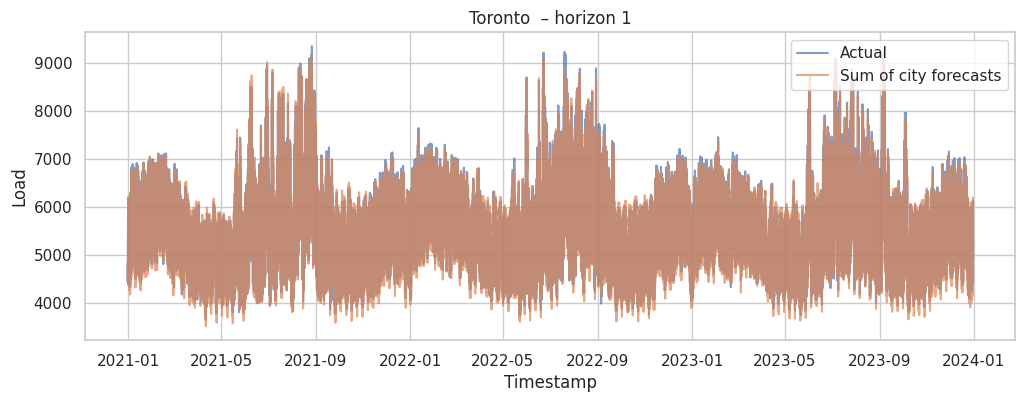

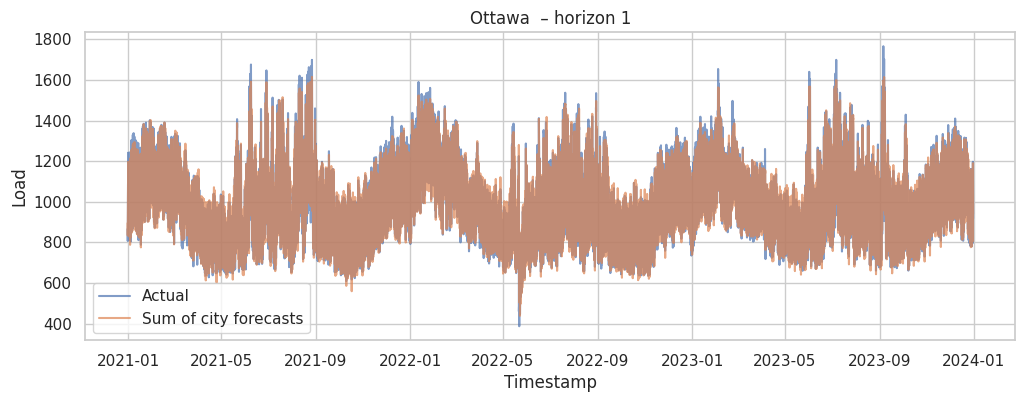

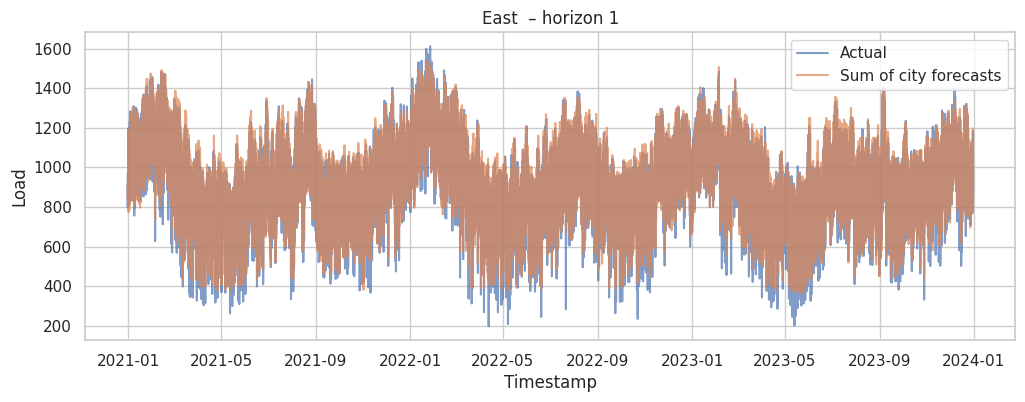

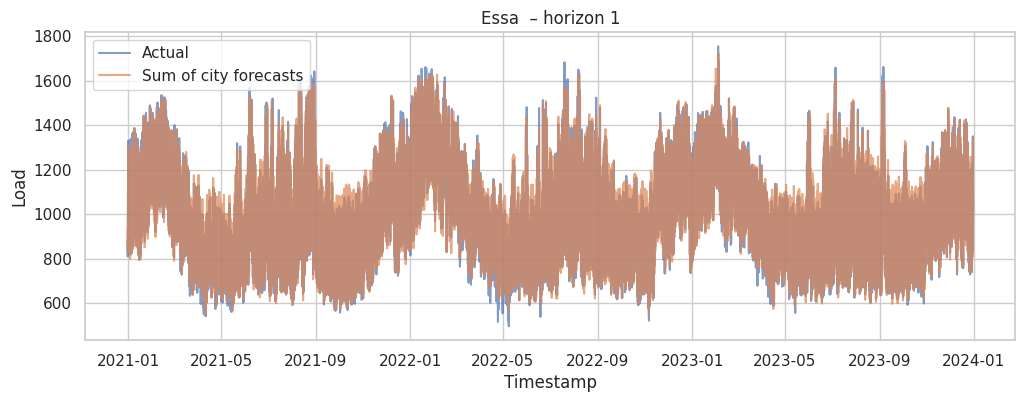

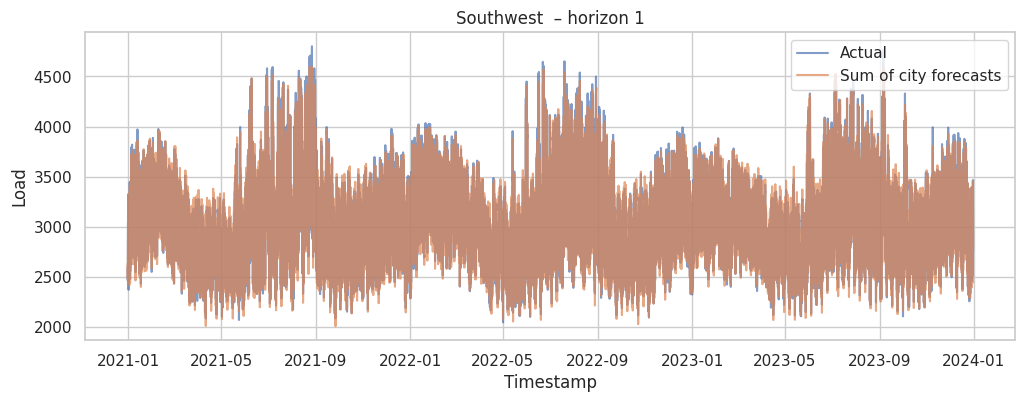

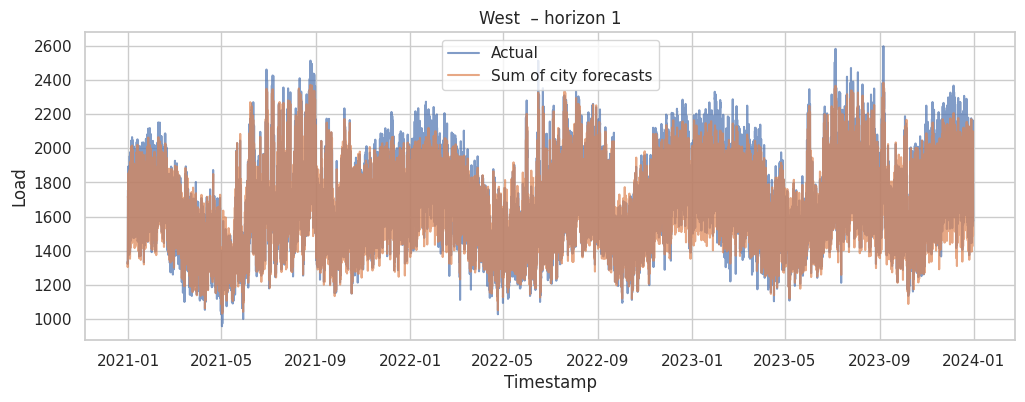

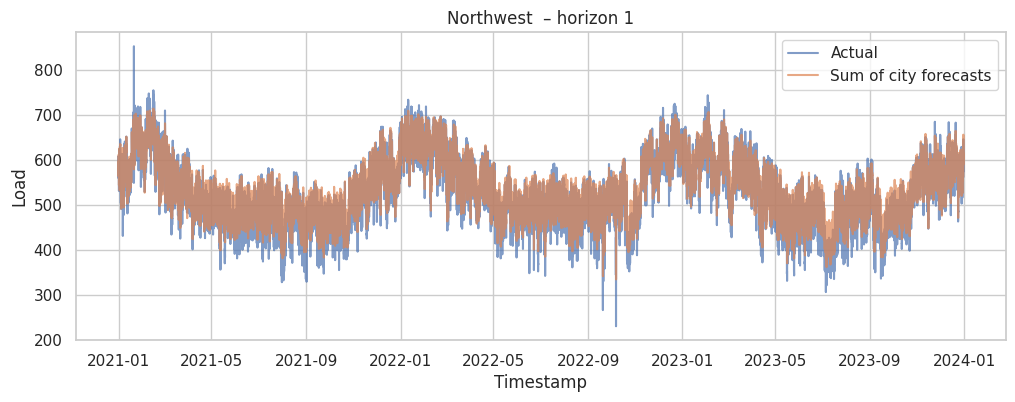

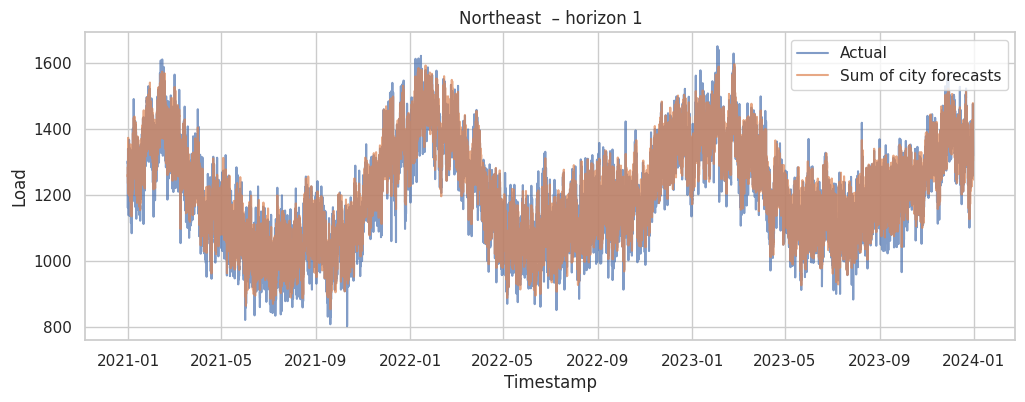

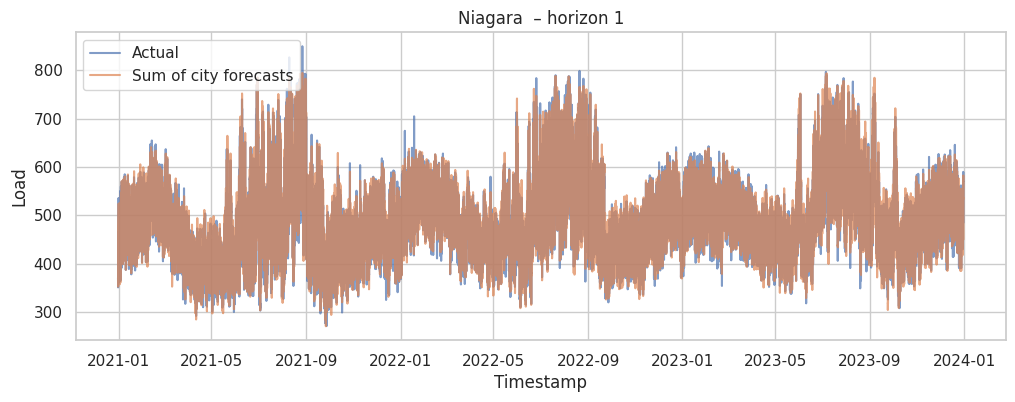

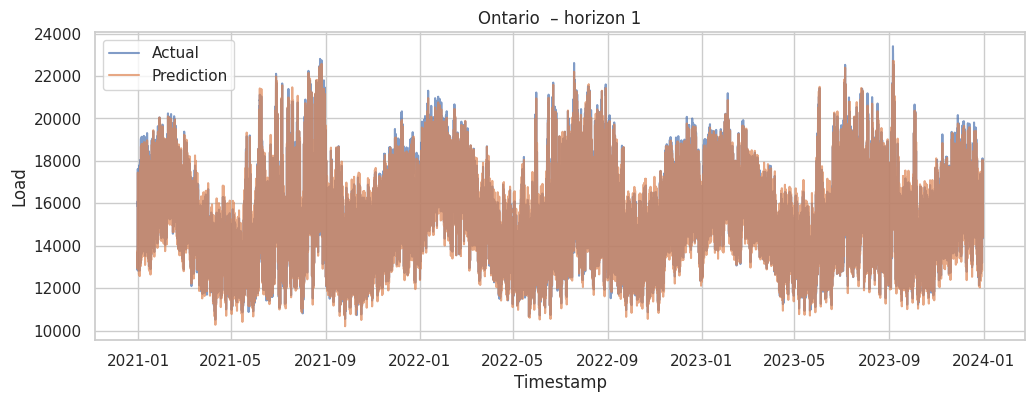

,Actual,Forecast
2020-12-31 00:00:00,13677.0,13738.649555
2020-12-31 01:00:00,13272.0,13314.412738
2020-12-31 02:00:00,13057.0,13050.886777
2020-12-31 03:00:00,12864.0,12940.987042
2020-12-31 04:00:00,12876.0,13178.889882
...,...,...
2023-12-30 19:00:00,16992.0,17379.779611
2023-12-30 20:00:00,16428.0,16784.473430
2023-12-30 21:00:00,15642.0,16181.032102
2023-12-30 22:00:00,14910.0,15338.947616


In [30]:
plot_city_profile(per_city, 'Toronto', horizon=1)
plot_city_profile(per_city, 'Ottawa', horizon=1)
plot_city_profile(per_city, 'East', horizon=1)
plot_city_profile(per_city, 'Essa', horizon=1)
plot_city_profile(per_city, 'Southwest', horizon=1)
plot_city_profile(per_city, 'West', horizon=1)
plot_city_profile(per_city, 'Northwest', horizon=1)
plot_city_profile(per_city, 'Northeast', horizon=1)
plot_city_profile(per_city, 'Niagara', horizon=1)
plot_ontario_aggregate(ontario, horizon=1)

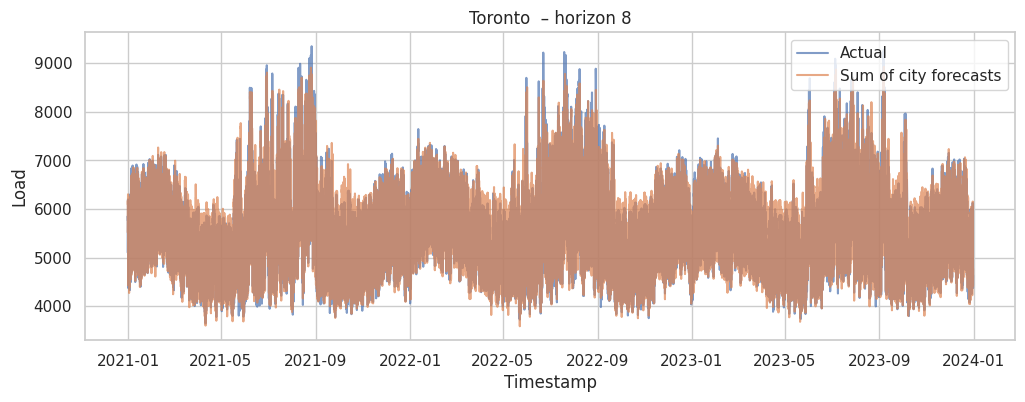

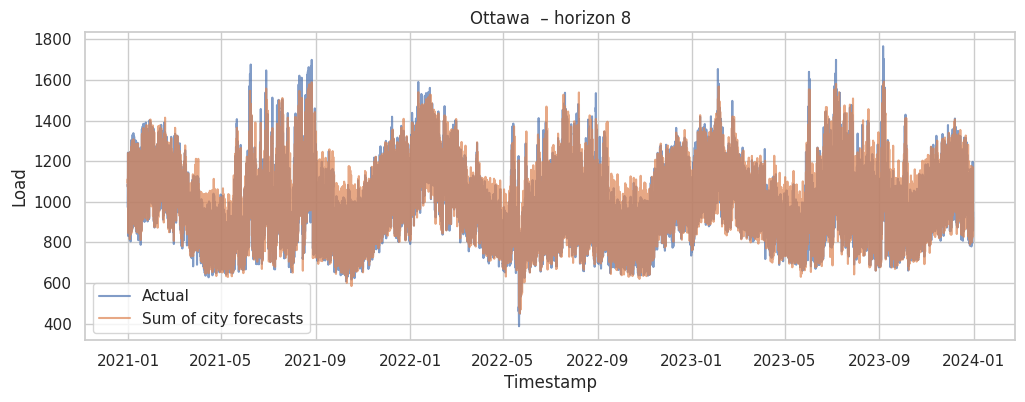

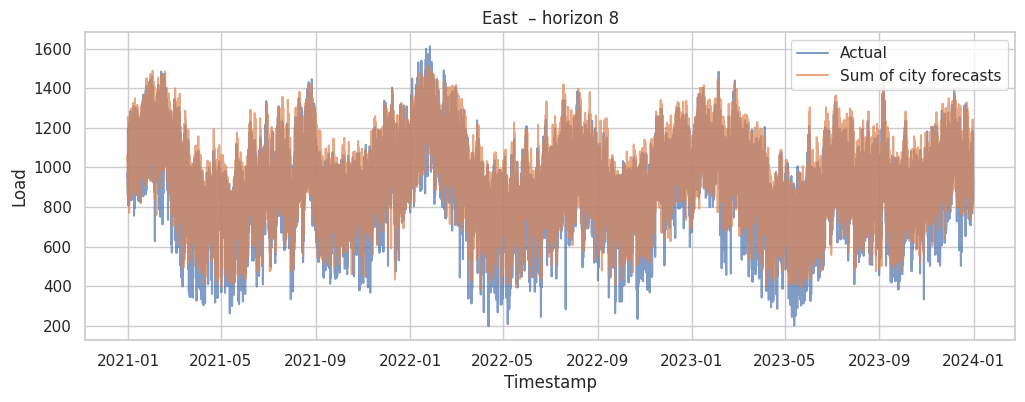

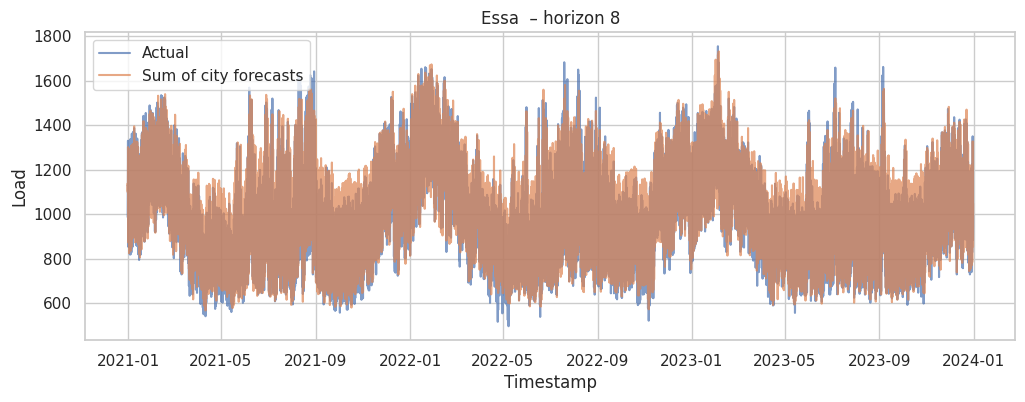

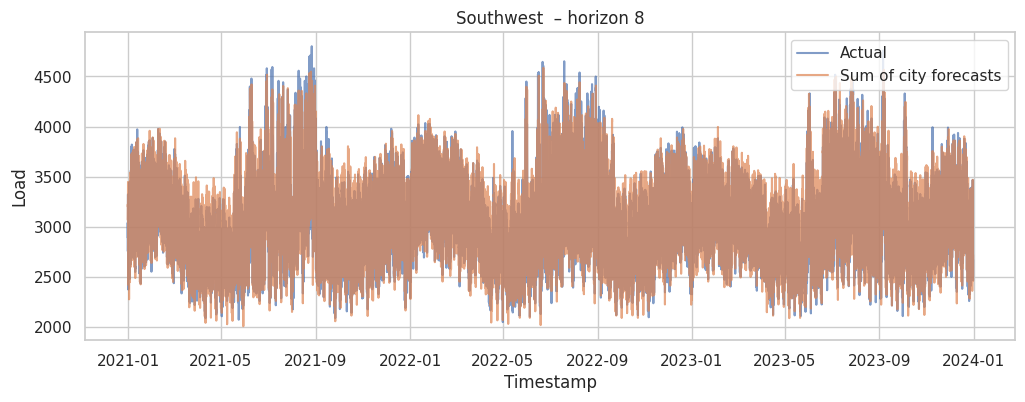

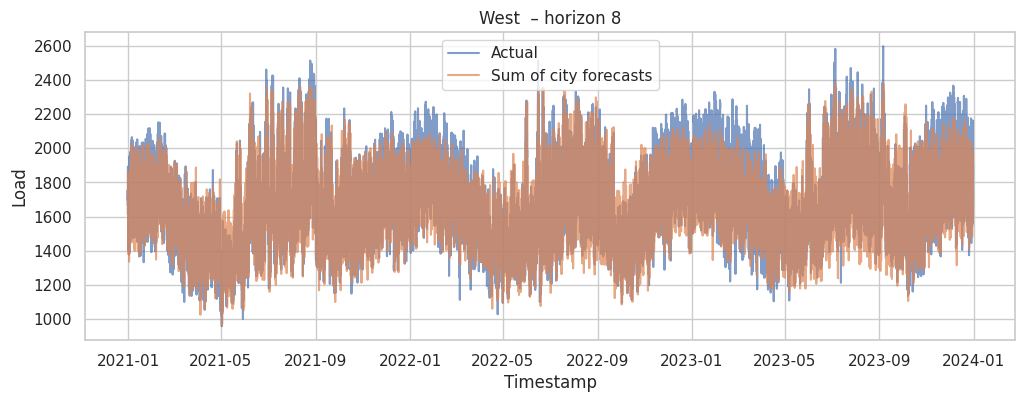

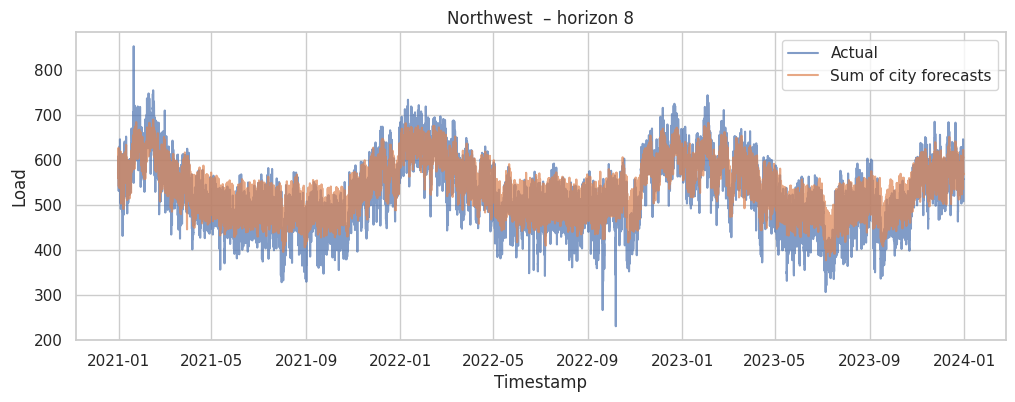

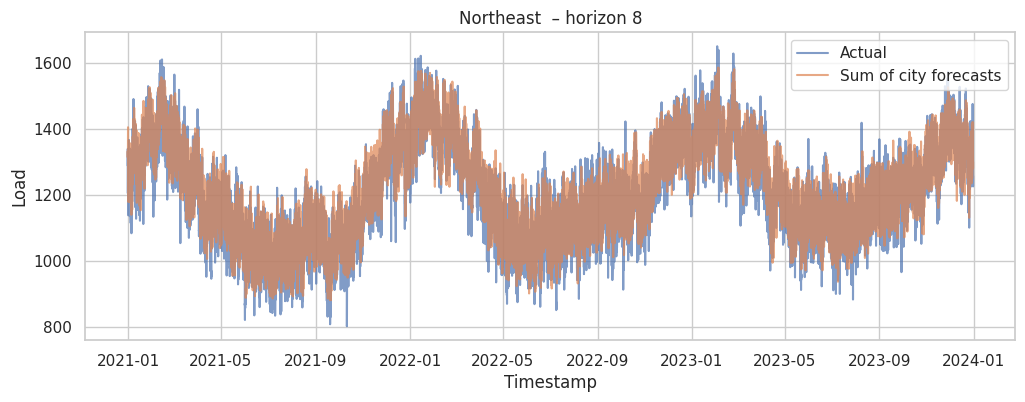

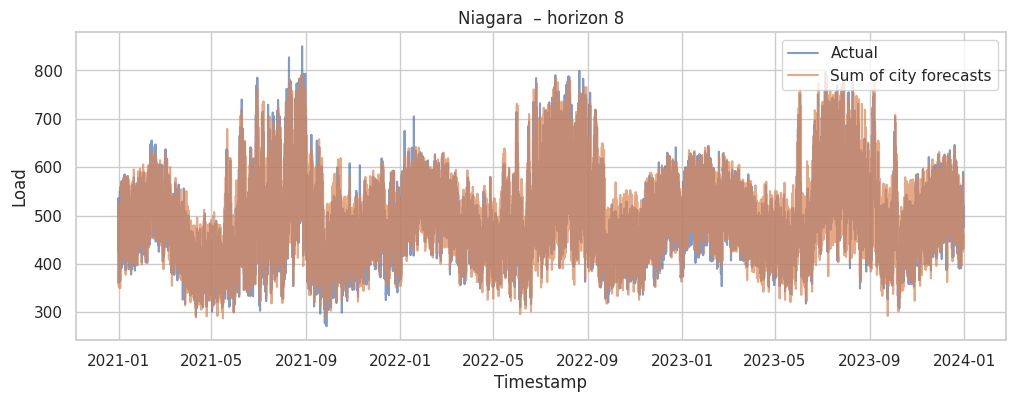

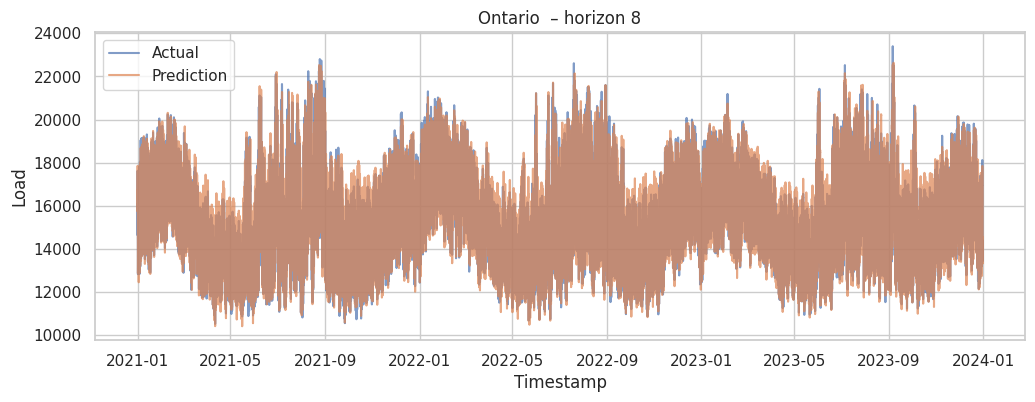

,Actual,Forecast
2020-12-31 07:00:00,14647.0,15752.417887
2020-12-31 08:00:00,15268.0,16294.211352
2020-12-31 09:00:00,15645.0,16569.882328
2020-12-31 10:00:00,15997.0,16688.678931
2020-12-31 11:00:00,16089.0,16728.677684
...,...,...
2023-12-31 02:00:00,13447.0,13415.447097
2023-12-31 03:00:00,13430.0,13316.771993
2023-12-31 04:00:00,13579.0,13521.645892
2023-12-31 05:00:00,13832.0,13973.832506


In [31]:
plot_city_profile(per_city, 'Toronto', horizon=8)
plot_city_profile(per_city, 'Ottawa', horizon=8)
plot_city_profile(per_city, 'East', horizon=8)
plot_city_profile(per_city, 'Essa', horizon=8)
plot_city_profile(per_city, 'Southwest', horizon=8)
plot_city_profile(per_city, 'West', horizon=8)
plot_city_profile(per_city, 'Northwest', horizon=8)
plot_city_profile(per_city, 'Northeast', horizon=8)
plot_city_profile(per_city, 'Niagara', horizon=8)
plot_ontario_aggregate(ontario, horizon=8)

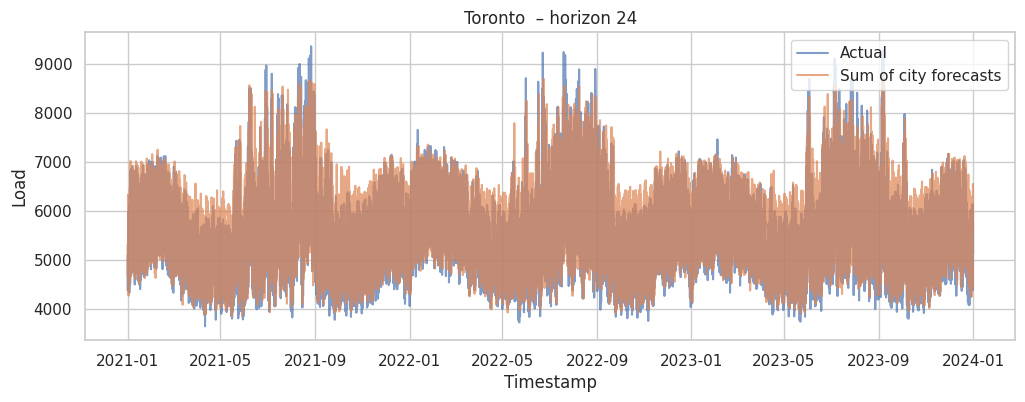

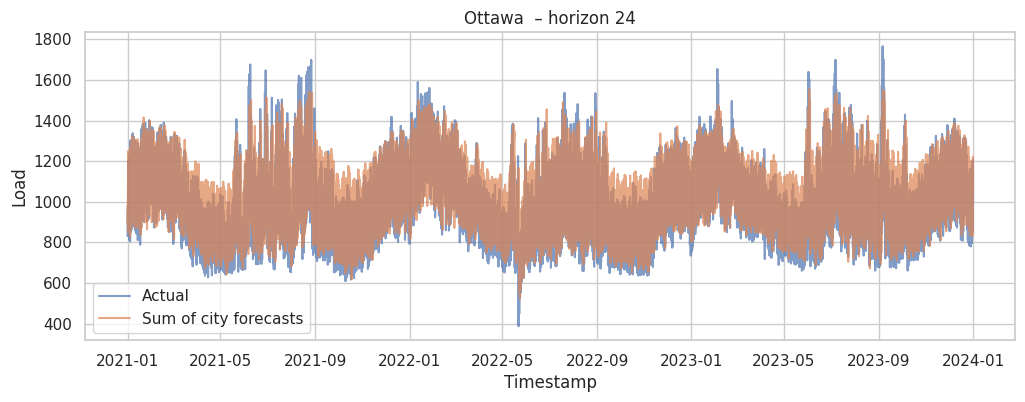

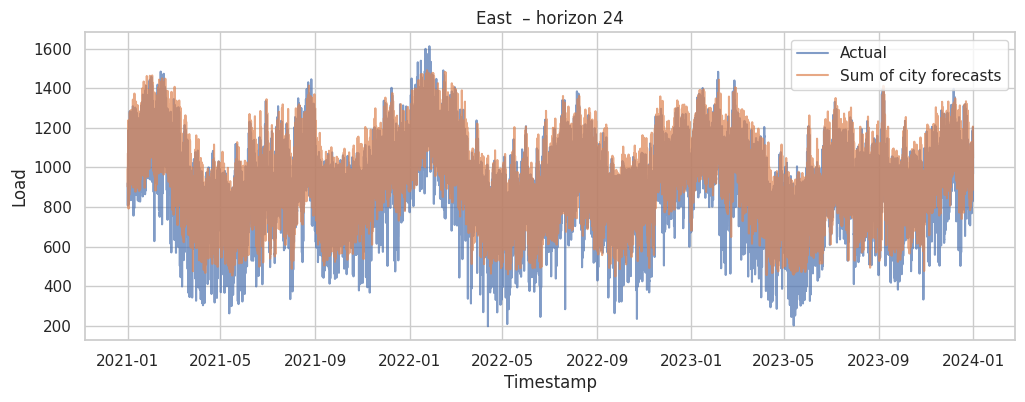

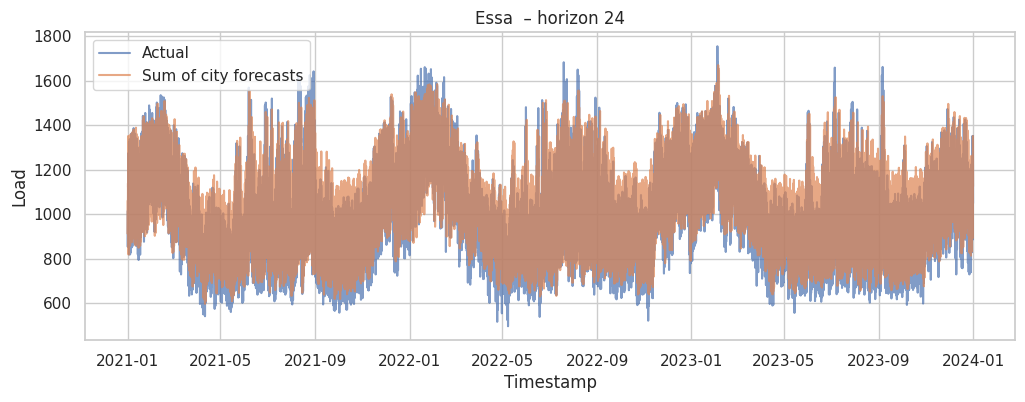

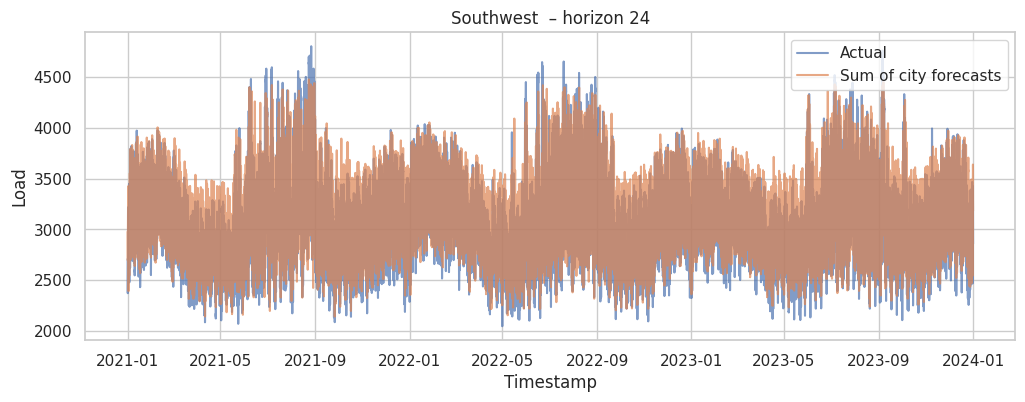

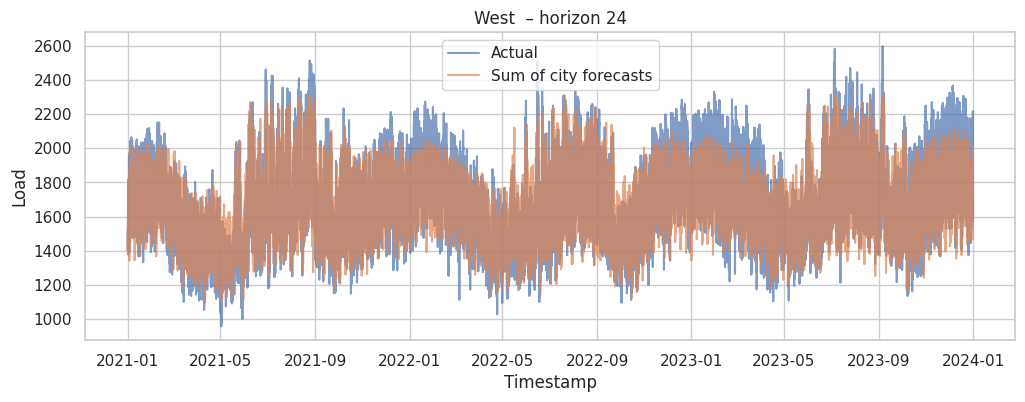

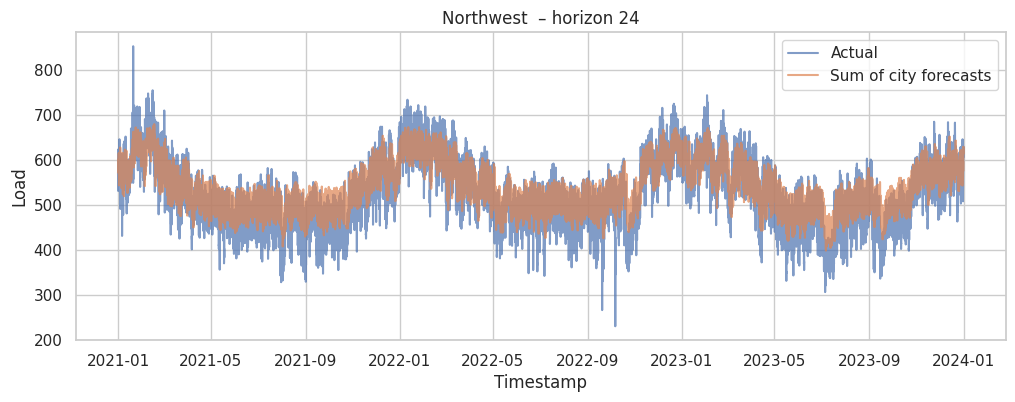

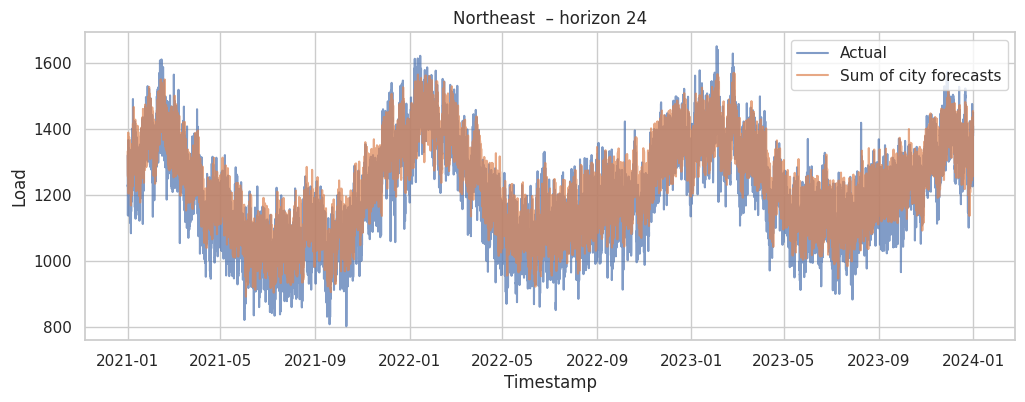

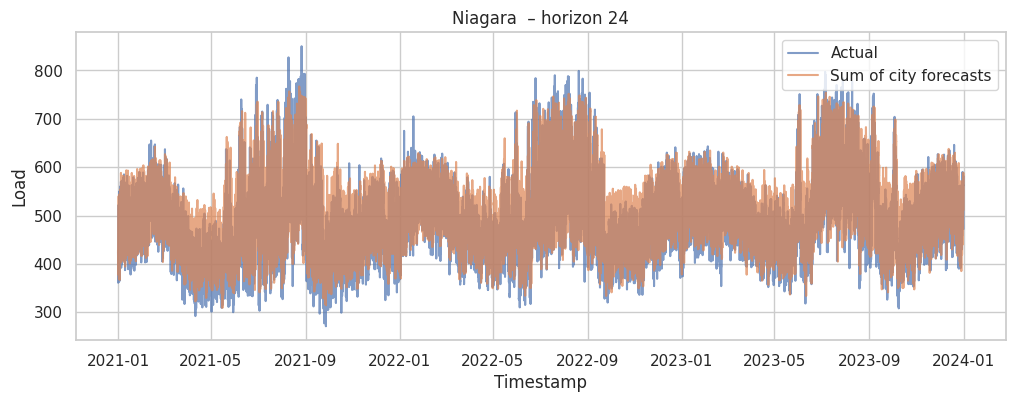

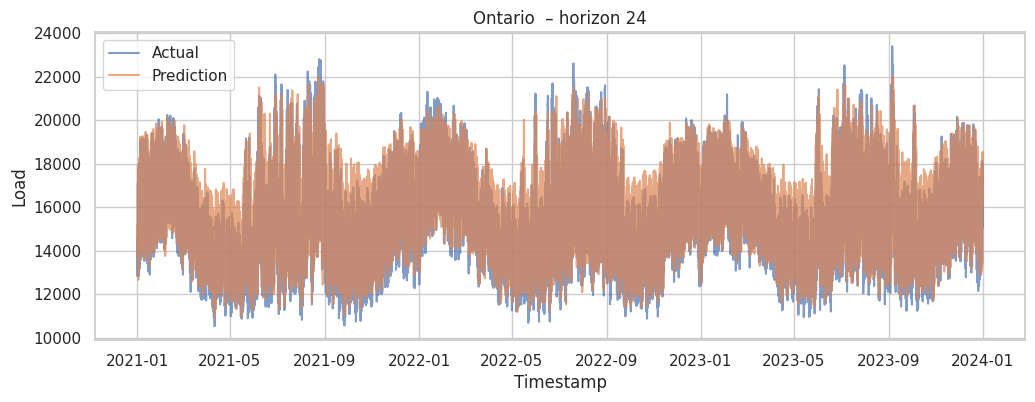

,Actual,Forecast
2020-12-31 23:00:00,14544.0,15187.627502
2021-01-01 00:00:00,13916.0,14395.374228
2021-01-01 01:00:00,13439.0,13959.481295
2021-01-01 02:00:00,13070.0,13784.346268
2021-01-01 03:00:00,12826.0,13759.607701
...,...,...
2023-12-31 18:00:00,17128.0,18386.161081
2023-12-31 19:00:00,16586.0,18039.667807
2023-12-31 20:00:00,16085.0,17641.896297
2023-12-31 21:00:00,15506.0,16975.783974


In [32]:
plot_city_profile(per_city, 'Toronto', horizon=24)
plot_city_profile(per_city, 'Ottawa', horizon=24)
plot_city_profile(per_city, 'East', horizon=24)
plot_city_profile(per_city, 'Essa', horizon=24)
plot_city_profile(per_city, 'Southwest', horizon=24)
plot_city_profile(per_city, 'West', horizon=24)
plot_city_profile(per_city, 'Northwest', horizon=24)
plot_city_profile(per_city, 'Northeast', horizon=24)
plot_city_profile(per_city, 'Niagara', horizon=24)
plot_ontario_aggregate(ontario, horizon=24)

In [33]:
import numpy as np
import pandas as pd

YEARS_OF_INTEREST = range(2020, 2024)
N_EXTREME_DAYS = 15
TEMP_COLUMN = 'temp'  # change if your temperature column has a different name

def _forecast_flat(info):
    """Flatten saved predictions for easier filtering."""
    num_windows, n_steps_out = info['timestamps'].shape[:2]
    timestamps = pd.to_datetime(info['timestamps'].reshape(-1))
    horizons = np.tile(np.arange(1, n_steps_out + 1), num_windows)
    df = pd.DataFrame({
        'timestamp': timestamps,
        'horizon': horizons,
        'actual': info['actuals'].reshape(-1),
        'forecast': info['predictions'].reshape(-1),
    })
    df['date'] = df['timestamp'].dt.normalize()
    return df

def _cold_warm_day_frames(df_city, years, n_days, temp_col):
    """Return dataframes listing coldest/warmest days with mean temperature."""
    df_period = df_city.loc[df_city.index.year.isin(years)]
    daily_temp = df_period[temp_col].resample('D').mean().dropna()
    cold = daily_temp.nsmallest(n_days).to_frame('mean_temp').reset_index(names='date')
    warm = daily_temp.nlargest(n_days).to_frame('mean_temp').reset_index(names='date')
    cold['date'] = cold['date'].dt.normalize()
    warm['date'] = warm['date'].dt.normalize()
    return cold, warm

def _compress_daily(table):
    """Collapse hourly rows to one row per date (mean actual/forecast)."""
    if table.empty:
        return table
    grouped = table.groupby('date').agg({
        'timestamp': 'min',       # representative timestamp (earliest)
        'mean_temp': 'first',
        'actual': 'mean',
        'forecast': 'mean',
        'absolute_error': 'mean'
    }).reset_index().rename(columns={
        'actual': 'actual_mean',
        'forecast': 'forecast_mean',
        'absolute_error': 'absolute_error_mean',
        'timestamp': 'representative_timestamp'
    })
    return grouped[['date', 'representative_timestamp', 'mean_temp',
                    'actual_mean', 'forecast_mean', 'absolute_error_mean']]

def extreme_daily_tables(per_city_results, city_frames,
                         years=YEARS_OF_INTEREST,
                         n_days=N_EXTREME_DAYS,
                         temp_col=TEMP_COLUMN):
    outputs = {}
    for city, info in per_city_results.items():
        df_city = city_frames[city]
        cold_days, warm_days = _cold_warm_day_frames(df_city, years, n_days, temp_col)
        flat = _forecast_flat(info)

        table_cold = (
            flat.merge(cold_days, on='date', how='inner')
                .assign(absolute_error=lambda d: np.abs(d['actual'] - d['forecast']))
                .sort_values(['date', 'timestamp', 'horizon'])
        )
        table_warm = (
            flat.merge(warm_days, on='date', how='inner')
                .assign(absolute_error=lambda d: np.abs(d['actual'] - d['forecast']))
                .sort_values(['date', 'timestamp', 'horizon'])
        )

        outputs[city] = {
            'cold_table': _compress_daily(table_cold),
            'warm_table': _compress_daily(table_warm),
        }
    return outputs

extreme_daily_tables_by_city = extreme_daily_tables(per_city, city_frames)

In [34]:
city = 'Toronto'
print("Coldest days (mean temp + mean actual/forecast):")
display(extreme_daily_tables_by_city[city]['cold_table'])

Coldest days (mean temp + mean actual/forecast):


,date,representative_timestamp,mean_temp,actual_mean,forecast_mean,absolute_error_mean
0,2021-02-12,2021-02-12,-10.383333,6345.041667,6257.494823,167.673816
1,2022-01-11,2022-01-11,-12.741667,6650.208333,6447.647596,262.007824
2,2022-01-15,2022-01-15,-16.404167,6222.291667,6029.643762,231.784190
3,2022-01-20,2022-01-20,-12.583333,6347.916667,6243.630783,142.425750
4,2022-01-21,2022-01-21,-12.962500,6480.833333,6362.950424,130.895270
5,2022-01-26,2022-01-26,-10.829167,6485.875000,6463.708169,90.384304
6,2022-01-28,2022-01-28,-11.645833,6470.333333,6348.157673,137.970310
7,2022-01-29,2022-01-29,-13.716667,6189.125000,6144.385927,95.766491
8,2022-02-04,2022-02-04,-10.141667,6453.250000,6364.269343,109.782423
9,2022-02-05,2022-02-05,-10.204167,6034.333333,6074.588776,93.663447


In [35]:
print("Warmest days (mean temp + mean actual/forecast):")
display(extreme_daily_tables_by_city[city]['warm_table'])

Warmest days (mean temp + mean actual/forecast):


,date,representative_timestamp,mean_temp,actual_mean,forecast_mean,absolute_error_mean
0,2021-07-06,2021-07-06,27.912500,7329.958333,6979.986146,361.887302
1,2021-08-23,2021-08-23,26.904167,7506.500000,7283.037050,252.507422
2,2022-06-22,2022-06-22,26.366667,7541.875000,6932.493820,628.183100
3,2022-07-19,2022-07-19,26.912500,7488.375000,6770.359139,723.122398
4,2022-07-20,2022-07-20,27.037500,7836.125000,7265.583623,574.258229
5,2022-08-07,2022-08-07,26.475000,7378.250000,6900.593080,490.239701
6,2023-07-05,2023-07-05,26.691667,7688.458333,7317.798145,379.556800


common metrics and metric in literature

In [36]:
# ============================================================================
# FORECAST ACCURACY METRICS (R², MAE, MAPE, Displacement Score)
# ============================================================================
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import zscore

def calculate_r2(y_true, y_pred):
    """Calculate R² (Coefficient of Determination)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return r2_score(y_true[mask], y_pred[mask])

def calculate_mae(y_true, y_pred):
    """Calculate MAE (Mean Absolute Error)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(y_true[mask], y_pred[mask])

def calculate_mape(y_true, y_pred):
    """Calculate MAPE (Mean Absolute Percentage Error)."""
    # Remove NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan

    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]

    # Avoid division by zero
    mask_nonzero = y_true_clean != 0
    if mask_nonzero.sum() == 0:
        return np.nan

    percentage_errors = np.abs((y_true_clean[mask_nonzero] - y_pred_clean[mask_nonzero]) / y_true_clean[mask_nonzero]) * 100
    return np.mean(percentage_errors)

def extract_ontario_horizon(ontario_result, horizon=1):
    """
    Extract Ontario data for a specific forecast horizon.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps' keys
    horizon : int
        Forecast horizon (1-24)

    Returns:
    --------
    pd.DataFrame with columns: timestamp, actual, forecast
    """
    h_idx = horizon - 1
    if h_idx >= ontario_result['timestamps'].shape[1]:
        raise ValueError(f"Horizon {horizon} exceeds maximum forecast steps ({ontario_result['timestamps'].shape[1]})")

    timestamps = pd.to_datetime(ontario_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual': ontario_result['actuals'][:, h_idx],
        'forecast': ontario_result['predictions'][:, h_idx],
    })
    df = df[~df.index.duplicated(keep='first')].sort_values('timestamp').reset_index(drop=True)
    df.set_index('timestamp', inplace=True)
    return df

def detect_peaks_zscore(demand_series, threshold=2.0):
    """
    Detect peak hours using Z-score threshold.

    Parameters:
    -----------
    demand_series : pd.Series
        Series of demand values
    threshold : float
        Z-score threshold (default: 2.0)

    Returns:
    --------
    pd.Series with 1 for peaks, 0 for non-peaks
    """
    # Calculate z-scores, handling NaN values
    valid_mask = ~demand_series.isna()
    peak_status = pd.Series(0, index=demand_series.index, dtype=int)

    if valid_mask.sum() > 0:
        z_scores = zscore(demand_series[valid_mask])
        peak_status.loc[valid_mask] = (z_scores >= threshold).astype(int)

    return peak_status

def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=4,z_actual_col='zscore_actual_prevyear', z_forecast_col='zscore_forecast_prevyear'):


    """
    Detect peaks using updated logic:
    - Real data: One peak hour per day (highest demand among hours exceeding threshold)
    - Forecast: One peak window per day (rolling window with highest sum)

    Parameters:
    -----------
    df_ontario : pd.DataFrame
        Ontario DataFrame with 'actual' and 'forecast' columns
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    pd.DataFrame with daily peak information and classification
    """
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    # Calculate Z-scores for actual and forecast (handle NaN values)
    valid_actual = df['actual'].dropna()
    valid_forecast = df['forecast'].dropna()

    zscore_actual_values = zscore(valid_actual)
    zscore_forecast_values = zscore(valid_forecast)

    # Create aligned z-score series
    df['zscore_actual'] = pd.Series(zscore_actual_values, index=valid_actual.index)
    df['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    # Initialize results list
    results = []

    # Process each day
    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        # Find hours exceeding threshold
        above_threshold = day_data[day_data['zscore_actual'] >= zscore_threshold]

        if len(above_threshold) > 0:
            # Select hour with highest demand
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        # Generate rolling windows
        eligible_windows = []

        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            # Check if window is eligible (at least one hour above threshold)
            if (window_data['zscore_forecast'] >= zscore_threshold).any():
                # Sum all values in window
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            # Select window with highest sum
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            # Check if true peak hour falls within predicted window
            if best_window['start'] <= true_peak_idx <= best_window['end']:
                classification = 'TP'  # True Positive
            else:
                classification = 'FN'  # False Negative
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'  # False Negative
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'  # False Positive
        else:
            classification = 'TN'  # True Negative

        # Store results
        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        # Add true peak information
        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour['zscore_actual']
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        # Add predicted peak window information
        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)

    # Add year column
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year

    return results_df

def calculate_displacement_score(peaks_updated_df):
    """
    Calculate Displacement Score (DS): Average absolute difference between
    actual peak hour and predicted peak hour.

    Parameters:
    -----------
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated with true_peak_timestamp and
        predicted_window_start columns

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour|)
    """
    # Filter to days where both actual and predicted peaks exist
    valid_days = peaks_updated_df[
        (peaks_updated_df['has_true_peak'] == True) &
        (peaks_updated_df['has_predicted_peak'] == True)
    ].copy()

    if len(valid_days) == 0:
        return np.nan

    # Extract hour of day for actual peak
    valid_days['actual_peak_hour'] = pd.to_datetime(valid_days['true_peak_timestamp']).dt.hour

    # Extract hour of day for predicted peak window (use start of window)
    valid_days['predicted_peak_hour'] = pd.to_datetime(valid_days['predicted_window_start']).dt.hour

    # Calculate absolute difference in hours
    valid_days['hour_difference'] = np.abs(valid_days['actual_peak_hour'] - valid_days['predicted_peak_hour'])

    # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
    # If difference > 12, it means we should go the other way around the clock
    valid_days['hour_difference'] = valid_days['hour_difference'].apply(
        lambda x: min(x, 24 - x) if x > 12 else x
    )

    # Calculate average
    ds = valid_days['hour_difference'].mean()

    return ds

# ============================================================================
# EVALUATE METRICS AT STEPS 1, 4, 8, 12, 16, 24
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Forecast Accuracy Metrics Evaluation ===")
print(f"=== R², MAE, MAPE, and Displacement Score (DS) ===")
print(f"{'='*70}")

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 4
horizons_to_evaluate = [1, 4, 8, 12, 16, 24]

metrics_results = []

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

    # Calculate forecast accuracy metrics (R², MAE, MAPE)
    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    # Calculate Displacement Score using peak detection
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    ds = calculate_displacement_score(peaks_updated)

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (hours)': ds
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS = {ds:.2f} hours")

# Display results as a table
metrics_df = pd.DataFrame(metrics_results)
print(f"\n{'='*70}")
print(f"Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))

# Also create a formatted summary
print(f"\n{'='*70}")
print(f"Formatted Summary:")
print(f"{'='*70}")
print(f"{'Step':<6} {'R²':<10} {'MAE (MW)':<12} {'MAPE (%)':<12} {'DS (hours)':<12}")
print(f"{'-'*70}")
for result in metrics_results:
    print(f"{result['Step']:<6} {result['R²']:<10.4f} {result['MAE']:<12.2f} {result['MAPE (%)']:<12.2f} {result['DS (hours)']:<12.2f}")

# Year-by-year breakdown (optional - if you want to see metrics per year)
print(f"\n{'='*70}")
print(f"Year-by-Year Breakdown:")
print(f"{'='*70}")

years_to_analyze = [2021, 2022, 2023]
yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    df_horizon['year'] = df_horizon.index.year

    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]

        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_year = calculate_displacement_score(peaks_year)

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (hours)': ds_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(f"\nYear-by-Year Metrics:")
print(yearly_metrics_df.to_string(index=False))

print(f"\n{'='*70}")


=== Forecast Accuracy Metrics Evaluation ===
=== R², MAE, MAPE, and Displacement Score (DS) ===

Processing horizon 1...
  R² = 0.9807
  MAE = 240.31 MW
  MAPE = 1.57%
  DS = 1.13 hours

Processing horizon 4...
  R² = 0.9577
  MAE = 344.51 MW
  MAPE = 2.24%
  DS = 1.16 hours

Processing horizon 8...
  R² = 0.9222
  MAE = 466.31 MW
  MAPE = 3.04%
  DS = 0.98 hours

Processing horizon 12...
  R² = 0.8896
  MAE = 565.38 MW
  MAPE = 3.70%
  DS = 1.23 hours

Processing horizon 16...
  R² = 0.8573
  MAE = 651.43 MW
  MAPE = 4.29%
  DS = 1.24 hours

Processing horizon 24...
  R² = 0.8315
  MAE = 714.33 MW
  MAPE = 4.71%
  DS = 1.12 hours

Summary Table - Forecast Accuracy Metrics by Step:
 Step       R²        MAE  MAPE (%)  DS (hours)
    1 0.980713 240.312621  1.570064    1.126214
    4 0.957682 344.505873  2.238414    1.156250
    8 0.922242 466.309985  3.036462    0.975610
   12 0.889565 565.375910  3.700365    1.228916
   16 0.857265 651.430421  4.288409    1.236842
   24 0.831482 714.3

In [37]:
# ============================================================================
# DISPLACEMENT SCORE FOR TOP 5 IESO PEAKS
# ============================================================================
def calculate_ds_top5_ieso_peaks(ontario_result, ieso_top5_peaks, horizon=1, zscore_threshold=2.0, window_hours=4):
    """
    Calculate Displacement Score (DS) specifically for IESO Top 5 peaks.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps'
    ieso_top5_peaks : dict
        Dictionary with years as keys and list of peak info as values
        Format: {year: [{'date': 'YYYY-MM-DD', 'hour_ending': H, 'rank': R}, ...]}
    horizon : int
        Forecast horizon (1-24)
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour| for top 5 peaks)
    """
    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)

    # Detect peaks using updated logic
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear')

    # Calculate z-scores for forecast to find predicted peaks
    valid_forecast = df_horizon['forecast'].dropna()
    zscore_forecast_values = zscore(valid_forecast)
    df_horizon['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    hour_differences = []

    # Process each year in IESO_TOP5_PEAKS
    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_peak_hour = peak_info['hour_ending']  # IESO uses hour_ending (e.g., 17 means 5 PM)

            # Find the actual peak timestamp (hour_ending means hour ending, so 17 = 16:00-17:00)
            # We'll use the start of that hour as the peak time
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_peak_hour - 1)

            # Check if we have data for this date
            day_data = df_horizon[df_horizon.index.normalize() == peak_date]

            if len(day_data) == 0:
                continue  # Skip if no data for this date

            # Find predicted peak window for this day
            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]

            if len(day_peaks) == 0:
                continue  # Skip if no peak detected for this day

            # Get the predicted peak window
            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']

            if pd.isna(predicted_window_start):
                continue  # Skip if no predicted peak

            # Extract hour from predicted window start
            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            # Calculate absolute difference in hours
            hour_diff = abs(actual_peak_hour - predicted_peak_hour)

            # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan

    # Calculate average displacement
    ds = np.mean([d['hour_difference'] for d in hour_differences])

    return ds, hour_differences

# ============================================================================
# EVALUATE METRICS AT STEPS 1, 4, 8, 12, 16, 24 (UPDATED WITH TOP 5 DS)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Forecast Accuracy Metrics Evaluation ===")
print(f"=== R², MAE, MAPE, DS (All Peaks), and DS (Top 5 IESO Peaks) ===")
print(f"{'='*70}")

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 4
horizons_to_evaluate = [1, 4, 8, 12, 16, 24]

metrics_results = []
top5_ds_details = {}  # Store detailed results for top 5 peaks

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

    # Calculate forecast accuracy metrics (R², MAE, MAPE)
    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    # Calculate Displacement Score using peak detection (all peaks)
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    ds_all = calculate_displacement_score(peaks_updated)

    # Calculate Displacement Score for Top 5 IESO peaks
    ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
        ontario,
        IESO_TOP5_PEAKS,
        horizon=horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    # Store detailed results
    top5_ds_details[horizon] = top5_details

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (All Peaks)': ds_all,
        'DS (Top 5 IESO)': ds_top5
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS (All Peaks) = {ds_all:.2f} hours")
    print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")

# Display results as a table
metrics_df = pd.DataFrame(metrics_results)
print(f"\n{'='*70}")
print(f"Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))

# Also create a formatted summary
print(f"\n{'='*70}")
print(f"Formatted Summary:")
print(f"{'='*70}")
print(f"{'Step':<6} {'R²':<10} {'MAE (MW)':<12} {'MAPE (%)':<12} {'DS (All)':<12} {'DS (Top 5)':<12}")
print(f"{'-'*70}")
for result in metrics_results:
    print(f"{result['Step']:<6} {result['R²']:<10.4f} {result['MAE']:<12.2f} {result['MAPE (%)']:<12.2f} "
          f"{result['DS (All Peaks)']:<12.2f} {result['DS (Top 5 IESO)']:<12.2f}")

# Display detailed breakdown for Top 5 IESO peaks
print(f"\n{'='*70}")
print(f"Detailed Breakdown - Top 5 IESO Peaks Displacement Score:")
print(f"{'='*70}")

for horizon in horizons_to_evaluate:
    if horizon in top5_ds_details and len(top5_ds_details[horizon]) > 0:
        print(f"\nStep {horizon}:")
        print(f"{'Year':<6} {'Date':<12} {'Rank':<6} {'Actual Hour':<12} {'Predicted Hour':<15} {'Difference (h)':<15}")
        print(f"{'-'*70}")

        for detail in top5_ds_details[horizon]:
            print(f"{detail['year']:<6} {str(detail['date'].date()):<12} {detail['rank']:<6} "
                  f"{detail['actual_hour']:<12} {detail['predicted_hour']:<15} {detail['hour_difference']:<15.2f}")

        avg_ds = np.mean([d['hour_difference'] for d in top5_ds_details[horizon]])
        print(f"\nAverage DS for Step {horizon}: {avg_ds:.2f} hours")
        print(f"{'='*70}")

# Year-by-year breakdown (optional - if you want to see metrics per year)
print(f"\n{'='*70}")
print(f"Year-by-Year Breakdown:")
print(f"{'='*70}")

years_to_analyze = [2021, 2022, 2023]
yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    df_horizon['year'] = df_horizon.index.year

    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]

        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_all_year = calculate_displacement_score(peaks_year)

        # Calculate DS for top 5 peaks for this year
        year_top5_peaks = {year: IESO_TOP5_PEAKS.get(year, [])}
        ds_top5_year, _ = calculate_ds_top5_ieso_peaks(
            ontario,
            year_top5_peaks,
            horizon=horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS
        )

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (All Peaks)': ds_all_year,
            'DS (Top 5 IESO)': ds_top5_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(f"\nYear-by-Year Metrics:")
print(yearly_metrics_df.to_string(index=False))

print(f"\n{'='*70}")


=== Forecast Accuracy Metrics Evaluation ===
=== R², MAE, MAPE, DS (All Peaks), and DS (Top 5 IESO Peaks) ===

Processing horizon 1...
  R² = 0.9807
  MAE = 240.31 MW
  MAPE = 1.57%
  DS (All Peaks) = 1.13 hours
  DS (Top 5 IESO) = 1.53 hours

Processing horizon 4...
  R² = 0.9577
  MAE = 344.51 MW
  MAPE = 2.24%
  DS (All Peaks) = 1.16 hours
  DS (Top 5 IESO) = 1.53 hours

Processing horizon 8...
  R² = 0.9222
  MAE = 466.31 MW
  MAPE = 3.04%
  DS (All Peaks) = 0.98 hours
  DS (Top 5 IESO) = 1.13 hours

Processing horizon 12...
  R² = 0.8896
  MAE = 565.38 MW
  MAPE = 3.70%
  DS (All Peaks) = 1.23 hours
  DS (Top 5 IESO) = 1.47 hours

Processing horizon 16...
  R² = 0.8573
  MAE = 651.43 MW
  MAPE = 4.29%
  DS (All Peaks) = 1.24 hours
  DS (Top 5 IESO) = 1.60 hours

Processing horizon 24...
  R² = 0.8315
  MAE = 714.33 MW
  MAPE = 4.71%
  DS (All Peaks) = 1.12 hours
  DS (Top 5 IESO) = 1.43 hours

Summary Table - Forecast Accuracy Metrics by Step:
 Step       R²        MAE  MAPE (%) 

In [38]:
# ============================================================================
# ALL-PEAKS METRICS GRID (Horizons x Window Sizes) + CSV export
# Builds horizon df and walk-forward z-scores in-cell (no years_eval in create_ontario_peak_dataframe).
# ============================================================================

import numpy as np
import pandas as pd

# ---- Config ----
HORIZONS_ALL = [4, 8, 12, 16, 20, 24]
WINDOW_SIZES_ALL = [1, 4, 6, 8, 10, 12]
YEARS_EVAL = [2021, 2022, 2023]
ZSCORE_THRESHOLD = 2.0

OUT_SUMMARY_CSV = "all_peaks_metrics_horizons_windows.csv"
OUT_DAILY_DETAILS_CSV = "all_peaks_daily_details.csv"

# ---- Walk-forward z-score helpers (in-cell so no dependency on create_ontario_peak_dataframe) ----
def _prev_year_baseline_stats(actual_series, years):
    baseline = {}
    for y in years:
        prev = y - 1
        prev_data = actual_series[actual_series.index.year == prev].dropna()
        if len(prev_data) == 0:
            baseline[y] = (np.nan, np.nan)
            continue
        mu = float(prev_data.mean())
        sd = float(prev_data.std(ddof=0))
        baseline[y] = (mu, sd if sd > 0 else np.nan)
    return baseline

def _zscore_with_baseline(series, baseline_by_year):
    out = pd.Series(index=series.index, dtype=float)
    for y, (mu, sd) in baseline_by_year.items():
        mask = series.index.year == y
        if not np.isfinite(mu) or not np.isfinite(sd):
            out.loc[mask] = np.nan
        else:
            out.loc[mask] = (series.loc[mask] - mu) / (sd + 1e-8)
    return out

def _add_walkforward_zscores(df_horizon, years_eval):
    baseline = _prev_year_baseline_stats(df_horizon["actual"], years_eval)
    df = df_horizon.copy()
    df["zscore_actual_prevyear"] = _zscore_with_baseline(df["actual"], baseline)
    df["zscore_forecast_prevyear"] = _zscore_with_baseline(df["forecast"], baseline)
    return df

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _confusion_from_classification(peaks_updated_df):
    if peaks_updated_df is None or len(peaks_updated_df) == 0:
        return dict(TP=0, FP=0, FN=0, TN=0, accuracy=np.nan, precision=np.nan, recall=np.nan, f1=np.nan)
    TP = int((peaks_updated_df["classification"] == "TP").sum())
    FP = int((peaks_updated_df["classification"] == "FP").sum())
    FN = int((peaks_updated_df["classification"] == "FN").sum())
    TN = int((peaks_updated_df["classification"] == "TN").sum())
    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if (precision is not np.nan and recall is not np.nan and (precision + recall) > 0) else np.nan
    return dict(TP=TP, FP=FP, FN=FN, TN=TN, accuracy=accuracy, precision=precision, recall=recall, f1=f1)

def _calc_ds(peaks_updated_df):
    try:
        return _safe_float(calculate_displacement_score(peaks_updated_df))
    except Exception:
        return np.nan

# ---- Run grid ----
summary_rows = []
daily_detail_rows = []

for horizon in HORIZONS_ALL:
    print(f"\n=== Horizon {horizon} ===")

    # Build horizon df from ontario (no create_ontario_peak_dataframe, no years_eval)
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon).sort_index()
    df_horizon["year"] = df_horizon.index.year
    df_horizon_eval = df_horizon[df_horizon["year"].isin(YEARS_EVAL)].copy()

    if len(df_horizon_eval) == 0:
        print("  (No rows in eval years; skipping)")
        continue

    # Add walk-forward z-scores in-cell
    df_horizon_eval = _add_walkforward_zscores(df_horizon_eval, YEARS_EVAL)

    y_true = df_horizon_eval["actual"].values
    y_pred = df_horizon_eval["forecast"].values
    r2 = _safe_float(calculate_r2(y_true, y_pred))
    mae = _safe_float(calculate_mae(y_true, y_pred))
    mape = _safe_float(calculate_mape(y_true, y_pred))

    for w in WINDOW_SIZES_ALL:
        print(f"  Window={w}h ...", end="")
        peaks_updated = detect_peaks_updated(
            df_horizon_eval,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=w,
            z_actual_col="zscore_actual_prevyear",
            z_forecast_col="zscore_forecast_prevyear",
        )
        cm = _confusion_from_classification(peaks_updated)
        ds = _calc_ds(peaks_updated)
        summary_rows.append({
            "Horizon_h": horizon,
            "Window_h": w,
            "Years": "-".join(map(str, YEARS_EVAL)),
            "Z_Threshold": ZSCORE_THRESHOLD,
            "R2": r2,
            "MAE": mae,
            "MAPE_pct": mape,
            "TP": cm["TP"],
            "FP": cm["FP"],
            "FN": cm["FN"],
            "TN": cm["TN"],
            "Accuracy": cm["accuracy"],
            "Precision": cm["precision"],
            "Recall": cm["recall"],
            "F1": cm["f1"],
            "DS_hours": ds,
        })
        if peaks_updated is not None and len(peaks_updated) > 0:
            tmp = peaks_updated.copy()
            tmp["Horizon_h"] = horizon
            tmp["Window_h"] = w
            daily_detail_rows.append(tmp[["Horizon_h", "Window_h", "date", "year", "classification",
                "has_true_peak", "has_predicted_peak", "true_peak_timestamp",
                "predicted_window_start", "predicted_window_end"]])
        print(" done")

summary_df = pd.DataFrame(summary_rows)
if len(summary_df) > 0:
    summary_df = summary_df.sort_values(["Horizon_h", "Window_h"]).reset_index(drop=True)

print("\n================ SUMMARY (ALL PEAKS) ================")
display(summary_df)
summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
print(f"\nSaved: {OUT_SUMMARY_CSV}  (rows={len(summary_df)})")

if len(daily_detail_rows) > 0:
    daily_df = pd.concat(daily_detail_rows, ignore_index=True)
    daily_df.to_csv(OUT_DAILY_DETAILS_CSV, index=False)
    print(f"Saved: {OUT_DAILY_DETAILS_CSV}  (rows={len(daily_df)})")


=== Horizon 4 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

=== Horizon 8 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

=== Horizon 12 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

=== Horizon 16 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

=== Horizon 20 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

=== Horizon 24 ===
  Window=1h ... done
  Window=4h ... done
  Window=6h ... done
  Window=8h ... done
  Window=10h ... done
  Window=12h ... done

================ SUMMARY (ALL PEAKS) ================


,Horizon_h,Window_h,Years,Z_Threshold,R2,MAE,MAPE_pct,TP,FP,FN,TN,Accuracy,Precision,Recall,F1,DS_hours
0,4,1,2021-2022-2023,2.0,0.957717,344.416163,2.237808,37,4,92,962,0.912329,0.902439,0.286822,0.435294,0.875000
1,4,4,2021-2022-2023,2.0,0.957717,344.416163,2.237808,88,4,41,962,0.958904,0.956522,0.682171,0.796380,1.156250
2,4,6,2021-2022-2023,2.0,0.957717,344.416163,2.237808,93,4,36,962,0.963470,0.958763,0.720930,0.823009,2.270833
3,4,8,2021-2022-2023,2.0,0.957717,344.416163,2.237808,95,4,34,962,0.965297,0.959596,0.736434,0.833333,3.593750
4,4,10,2021-2022-2023,2.0,0.957717,344.416163,2.237808,96,4,33,962,0.966210,0.960000,0.744186,0.838428,5.104167
5,4,12,2021-2022-2023,2.0,0.957717,344.416163,2.237808,96,4,33,962,0.966210,0.960000,0.744186,0.838428,6.604167
6,8,1,2021-2022-2023,2.0,0.922316,466.131001,3.035393,21,11,108,955,0.891324,0.656250,0.162791,0.260870,1.182927
7,8,4,2021-2022-2023,2.0,0.922316,466.131001,3.035393,73,11,56,955,0.938813,0.869048,0.565891,0.685446,0.975610
8,8,6,2021-2022-2023,2.0,0.922316,466.131001,3.035393,79,11,50,955,0.944292,0.877778,0.612403,0.721461,2.158537
9,8,8,2021-2022-2023,2.0,0.922316,466.131001,3.035393,80,11,49,955,0.945205,0.879121,0.620155,0.727273,3.560976



Saved: all_peaks_metrics_horizons_windows.csv  (rows=36)
Saved: all_peaks_daily_details.csv  (rows=39420)


In [39]:
# ============================================================================
# UPDATED: ALL-PEAKS METRICS GRID (PER YEAR) + DATE/TIME DETAILS + CSV export
# ============================================================================

import numpy as np
import pandas as pd

HORIZONS_ALL = [4, 8, 12, 16, 20, 24]
WINDOW_SIZES_ALL = [1, 4, 6, 8, 10, 12]
YEARS_EVAL = [2021, 2022, 2023]
ZSCORE_THRESHOLD = 2.0

OUT_SUMMARY_CSV = "all_peaks_metrics_per_year_horizons_windows.csv"
OUT_DAILY_DETAILS_CSV = "all_peaks_daily_details_per_year.csv"

# --- Reuse your helpers from the previous cell if they exist.
# If not, keep these (safe to re-run).

def _prev_year_baseline_stats(actual_series, years):
    baseline = {}
    for y in years:
        prev = y - 1
        prev_data = actual_series[actual_series.index.year == prev].dropna()
        if len(prev_data) == 0:
            baseline[y] = (np.nan, np.nan)
            continue
        mu = float(prev_data.mean())
        sd = float(prev_data.std(ddof=0))
        baseline[y] = (mu, sd if sd > 0 else np.nan)
    return baseline

def _zscore_with_baseline(series, baseline_by_year):
    out = pd.Series(index=series.index, dtype=float)
    for y, (mu, sd) in baseline_by_year.items():
        mask = series.index.year == y
        if not np.isfinite(mu) or not np.isfinite(sd):
            out.loc[mask] = np.nan
        else:
            out.loc[mask] = (series.loc[mask] - mu) / (sd + 1e-8)
    return out

def _add_walkforward_zscores(df_horizon, years_eval):
    baseline = _prev_year_baseline_stats(df_horizon["actual"], years_eval)
    df = df_horizon.copy()
    df["zscore_actual_prevyear"] = _zscore_with_baseline(df["actual"], baseline)
    df["zscore_forecast_prevyear"] = _zscore_with_baseline(df["forecast"], baseline)
    return df

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _confusion_from_classification(peaks_updated_df):
    if peaks_updated_df is None or len(peaks_updated_df) == 0:
        return dict(TP=0, FP=0, FN=0, TN=0, accuracy=np.nan, precision=np.nan, recall=np.nan, f1=np.nan)

    TP = int((peaks_updated_df["classification"] == "TP").sum())
    FP = int((peaks_updated_df["classification"] == "FP").sum())
    FN = int((peaks_updated_df["classification"] == "FN").sum())
    TN = int((peaks_updated_df["classification"] == "TN").sum())
    total = TP + FP + FN + TN

    accuracy = (TP + TN) / total if total > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    f1 = (2 * precision * recall / (precision + recall)) if (np.isfinite(precision) and np.isfinite(recall) and (precision + recall) > 0) else np.nan

    return dict(TP=TP, FP=FP, FN=FN, TN=TN, accuracy=accuracy, precision=precision, recall=recall, f1=f1)

def _calc_ds(peaks_updated_df):
    try:
        return _safe_float(calculate_displacement_score(peaks_updated_df))
    except Exception:
        return np.nan


# ---- Run per-year grid ----
summary_rows = []
daily_detail_rows = []

for horizon in HORIZONS_ALL:
    print(f"\n=== Horizon {horizon} ===")

    # Build full horizon df once
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon).sort_index()
    df_horizon["year"] = df_horizon.index.year

    # Add walk-forward z-scores on the full horizon df (needs prev-year data present)
    df_horizon = _add_walkforward_zscores(df_horizon, YEARS_EVAL)

    for year in YEARS_EVAL:
        df_year = df_horizon[df_horizon["year"] == year].copy()
        if len(df_year) == 0:
            continue

        # Forecast accuracy metrics for THIS YEAR (point forecast)
        y_true = df_year["actual"].values
        y_pred = df_year["forecast"].values
        r2 = _safe_float(calculate_r2(y_true, y_pred))
        mae = _safe_float(calculate_mae(y_true, y_pred))
        mape = _safe_float(calculate_mape(y_true, y_pred))

        for w in WINDOW_SIZES_ALL:
            print(f"  Year={year} Window={w}h ...", end="")

            peaks_updated = detect_peaks_updated(
                df_year,
                zscore_threshold=ZSCORE_THRESHOLD,
                window_hours=w,
                z_actual_col="zscore_actual_prevyear",
                z_forecast_col="zscore_forecast_prevyear",
            )

            cm = _confusion_from_classification(peaks_updated)
            ds = _calc_ds(peaks_updated)

            summary_rows.append({
                "Year": year,
                "Horizon_h": horizon,
                "Window_h": w,
                "Z_Threshold": ZSCORE_THRESHOLD,

                "R2": r2,
                "MAE": mae,
                "MAPE_pct": mape,

                "TP": cm["TP"],
                "FP": cm["FP"],
                "FN": cm["FN"],
                "TN": cm["TN"],
                "Accuracy": cm["accuracy"],
                "Precision": cm["precision"],
                "Recall": cm["recall"],
                "F1": cm["f1"],
                "DS_hours": ds,
            })

            # ---- Daily detail table with DATE + TIME ----
            # 'date' is normalized date. Add explicit date/time for peak timestamps + window bounds.
            if peaks_updated is not None and len(peaks_updated) > 0:
                tmp = peaks_updated.copy()

                tmp["Year"] = year
                tmp["Horizon_h"] = horizon
                tmp["Window_h"] = w

                # Ensure datetime types
                tmp["date"] = pd.to_datetime(tmp["date"])
                tmp["true_peak_timestamp"] = pd.to_datetime(tmp["true_peak_timestamp"], errors="coerce")
                tmp["predicted_window_start"] = pd.to_datetime(tmp["predicted_window_start"], errors="coerce")
                tmp["predicted_window_end"] = pd.to_datetime(tmp["predicted_window_end"], errors="coerce")

                # Extract date + time columns (what you asked for)
                tmp["true_peak_date"] = tmp["true_peak_timestamp"].dt.date
                tmp["true_peak_time"] = tmp["true_peak_timestamp"].dt.time

                tmp["pred_window_start_date"] = tmp["predicted_window_start"].dt.date
                tmp["pred_window_start_time"] = tmp["predicted_window_start"].dt.time

                tmp["pred_window_end_date"] = tmp["predicted_window_end"].dt.date
                tmp["pred_window_end_time"] = tmp["predicted_window_end"].dt.time

                daily_detail_rows.append(tmp[[
                    "Year", "Horizon_h", "Window_h",
                    "date",
                    "classification", "has_true_peak", "has_predicted_peak",
                    "true_peak_timestamp", "true_peak_date", "true_peak_time",
                    "predicted_window_start", "pred_window_start_date", "pred_window_start_time",
                    "predicted_window_end", "pred_window_end_date", "pred_window_end_time",
                ]])

            print(" done")

# ---- Outputs ----
summary_df = pd.DataFrame(summary_rows)
if len(summary_df) > 0:
    summary_df = summary_df.sort_values(["Year", "Horizon_h", "Window_h"]).reset_index(drop=True)

print("\n================ SUMMARY (ALL PEAKS, PER YEAR) ================")
display(summary_df)

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
print(f"\nSaved summary CSV: {OUT_SUMMARY_CSV}  (rows={len(summary_df)})")

if len(daily_detail_rows) > 0:
    daily_df = pd.concat(daily_detail_rows, ignore_index=True)
    daily_df.to_csv(OUT_DAILY_DETAILS_CSV, index=False)
    print(f"Saved daily details CSV: {OUT_DAILY_DETAILS_CSV}  (rows={len(daily_df)})")
else:
    print("No daily details to save (empty).")


=== Horizon 4 ===
  Year=2021 Window=1h ... done
  Year=2021 Window=4h ... done
  Year=2021 Window=6h ... done
  Year=2021 Window=8h ... done
  Year=2021 Window=10h ... done
  Year=2021 Window=12h ... done
  Year=2022 Window=1h ... done
  Year=2022 Window=4h ... done
  Year=2022 Window=6h ... done
  Year=2022 Window=8h ... done
  Year=2022 Window=10h ... done
  Year=2022 Window=12h ... done
  Year=2023 Window=1h ... done
  Year=2023 Window=4h ... done
  Year=2023 Window=6h ... done
  Year=2023 Window=8h ... done
  Year=2023 Window=10h ... done
  Year=2023 Window=12h ... done

=== Horizon 8 ===
  Year=2021 Window=1h ... done
  Year=2021 Window=4h ... done
  Year=2021 Window=6h ... done
  Year=2021 Window=8h ... done
  Year=2021 Window=10h ... done
  Year=2021 Window=12h ... done
  Year=2022 Window=1h ... done
  Year=2022 Window=4h ... done
  Year=2022 Window=6h ... done
  Year=2022 Window=8h ... done
  Year=2022 Window=10h ... done
  Year=2022 Window=12h ... done
  Year=2023 Window=1h 

,Year,Horizon_h,Window_h,Z_Threshold,R2,MAE,MAPE_pct,TP,FP,FN,TN,Accuracy,Precision,Recall,F1,DS_hours
0,2021,4,1,2.0,0.959985,347.542682,2.290426,22,2,25,316,0.926027,0.916667,0.468085,0.619718,0.736842
1,2021,4,4,2.0,0.959985,347.542682,2.290426,33,2,14,316,0.956164,0.942857,0.702128,0.804878,1.210526
2,2021,4,6,2.0,0.959985,347.542682,2.290426,36,2,11,316,0.964384,0.947368,0.765957,0.847059,2.236842
3,2021,4,8,2.0,0.959985,347.542682,2.290426,37,2,10,316,0.967123,0.948718,0.787234,0.860465,3.552632
4,2021,4,10,2.0,0.959985,347.542682,2.290426,38,2,9,316,0.969863,0.950000,0.808511,0.873563,5.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,2023,24,4,2.0,0.831509,682.577676,4.452775,15,8,19,323,0.926027,0.652174,0.441176,0.526316,1.650000
104,2023,24,6,2.0,0.831509,682.577676,4.452775,18,8,16,323,0.934247,0.692308,0.529412,0.600000,2.600000
105,2023,24,8,2.0,0.831509,682.577676,4.452775,19,8,15,323,0.936986,0.703704,0.558824,0.622951,3.700000
106,2023,24,10,2.0,0.831509,682.577676,4.452775,20,8,14,323,0.939726,0.714286,0.588235,0.645161,5.050000



Saved summary CSV: all_peaks_metrics_per_year_horizons_windows.csv  (rows=108)
Saved daily details CSV: all_peaks_daily_details_per_year.csv  (rows=39420)


In [52]:
import pandas as pd

OUT_DAILY_DETAILS_WITH_TIME = "all_peaks_daily_details_per_year_with_time1.csv"

d = daily_df.copy()

true_ts = pd.to_datetime(d["true_peak_timestamp"], errors="coerce")
pred_start = pd.to_datetime(d["predicted_window_start"], errors="coerce")
pred_end = pd.to_datetime(d["predicted_window_end"], errors="coerce")

# Keep the original day-level date column.
d["date"] = pd.to_datetime(d["date"], errors="coerce").dt.date

# Add one time column using the best available timestamp for that row.
# Priority: true peak time -> predicted window start -> predicted window end
event_ts = true_ts.fillna(pred_start).fillna(pred_end)
d["time"] = event_ts.dt.time

d.to_csv(OUT_DAILY_DETAILS_WITH_TIME, index=False)
print("Saved:", OUT_DAILY_DETAILS_WITH_TIME)

Saved: all_peaks_daily_details_per_year_with_time1.csv


In [40]:
# ============================================================================
# DISPLACEMENT SCORE FOR TOP 5 IESO PEAKS
# ============================================================================
def calculate_ds_top5_ieso_peaks(ontario_result, ieso_top5_peaks, horizon=1, zscore_threshold=2.0, window_hours=4):
    """
    Calculate Displacement Score (DS) specifically for IESO Top 5 peaks.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps'
    ieso_top5_peaks : dict
        Dictionary with years as keys and list of peak info as values
        Format: {year: [{'date': 'YYYY-MM-DD', 'hour_ending': H, 'rank': R}, ...]}
    horizon : int
        Forecast horizon (1-24)
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour| for top 5 peaks)
    """
    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)

    # Detect peaks using updated logic
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    # Calculate z-scores for forecast to find predicted peaks
    valid_forecast = df_horizon['forecast'].dropna()
    zscore_forecast_values = zscore(valid_forecast)
    df_horizon['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    hour_differences = []

    # Process each year in IESO_TOP5_PEAKS
    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_peak_hour = peak_info['hour_ending']  # IESO uses hour_ending (e.g., 17 means 5 PM)

            # Find the actual peak timestamp (hour_ending means hour ending, so 17 = 16:00-17:00)
            # We'll use the start of that hour as the peak time
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_peak_hour - 1)

            # Check if we have data for this date
            day_data = df_horizon[df_horizon.index.normalize() == peak_date]

            if len(day_data) == 0:
                continue  # Skip if no data for this date

            # Find predicted peak window for this day
            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]

            if len(day_peaks) == 0:
                continue  # Skip if no peak detected for this day

            # Get the predicted peak window
            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']

            if pd.isna(predicted_window_start):
                continue  # Skip if no predicted peak

            # Extract hour from predicted window start
            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            # Calculate absolute difference in hours
            hour_diff = abs(actual_peak_hour - predicted_peak_hour)

            # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan, []

    # Calculate average displacement
    ds = np.mean([d['hour_difference'] for d in hour_differences])

    return ds, hour_differences


# ============================================================================
# HELPER FUNCTIONS FOR METRICS CALCULATION
# ============================================================================
def calculate_r2(y_true, y_pred):
    """Calculate R² score."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - (ss_res / ss_tot)

def calculate_mae(y_true, y_pred):
    """Calculate Mean Absolute Error."""
    return np.mean(np.abs(y_true - y_pred))

def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error."""
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def calculate_displacement_score(peaks_df):
    """Calculate Displacement Score from peaks dataframe."""
    if len(peaks_df) == 0:
        return np.nan

    # Filter to only days with both true and predicted peaks
    tp_fn_days = peaks_df[peaks_df['has_true_peak'] == True].copy()

    if len(tp_fn_days) == 0:
        return np.nan

    hour_differences = []
    for _, row in tp_fn_days.iterrows():
        if pd.notna(row['true_peak_timestamp']) and pd.notna(row['predicted_window_start']):
            true_hour = pd.to_datetime(row['true_peak_timestamp']).hour
            pred_hour = pd.to_datetime(row['predicted_window_start']).hour

            hour_diff = abs(true_hour - pred_hour)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff
            hour_differences.append(hour_diff)

    if len(hour_differences) == 0:
        return np.nan

    return np.mean(hour_differences)


# ============================================================================
# HELPER FUNCTION TO FILTER DATA FOR TOP 5 IESO PEAKS
# ============================================================================
def filter_data_for_top5_ieso_peaks(df_horizon, ieso_top5_peaks):
    """
    Filter dataframe to only include timestamps corresponding to top 5 IESO peaks.

    Parameters:
    -----------
    df_horizon : pd.DataFrame
        DataFrame with timestamp index, 'actual', 'forecast' columns
    ieso_top5_peaks : dict
        Dictionary with years as keys and list of peak info as values

    Returns:
    --------
    pd.DataFrame
        Filtered dataframe containing only top 5 IESO peak timestamps
    """
    top5_timestamps = []

    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_peak_hour = peak_info['hour_ending']

            # Find the actual peak timestamp
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_peak_hour - 1)
            top5_timestamps.append(actual_peak_timestamp)

    # Filter dataframe to only include these timestamps
    if len(top5_timestamps) > 0:
        filtered_df = df_horizon[df_horizon.index.isin(top5_timestamps)].copy()
        return filtered_df
    else:
        return pd.DataFrame()


# ============================================================================
# EVALUATE METRICS AT STEPS 1, 4, 8, 12, 16, 24 (FILTERED TO TOP 5 IESO PEAKS ONLY)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Forecast Accuracy Metrics Evaluation ===")
print(f"=== R², MAE, MAPE, DS (All Peaks), DS (Top 5 IESO Peaks), and Confusion Metrics ===")
print(f"=== FILTERED TO TOP 5 IESO PEAKS ONLY ===")
print(f"{'='*70}")

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8
horizons_to_evaluate = [1, 4, 8, 12, 16, 24]

metrics_results = []
top5_ds_details = {}  # Store detailed results for top 5 peaks

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

    # Filter data to only top 5 IESO peaks for R², MAE, MAPE calculation
    df_horizon_top5 = filter_data_for_top5_ieso_peaks(df_horizon, IESO_TOP5_PEAKS)

    if len(df_horizon_top5) == 0:
        print(f"  Warning: No data found for top 5 IESO peaks at horizon {horizon}")
        continue

    # Calculate forecast accuracy metrics (R², MAE, MAPE) - ONLY ON TOP 5 PEAKS
    y_true = df_horizon_top5['actual'].values
    y_pred = df_horizon_top5['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    # Calculate Displacement Score using peak detection
    # Note: We still need all data for peak detection, but will filter results
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    # Filter peaks_updated to only include top 5 IESO peak days
    top5_dates = set()
    for year, peak_list in IESO_TOP5_PEAKS.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            top5_dates.add(peak_date)

    peaks_updated_top5 = peaks_updated[peaks_updated['date'].isin(top5_dates)].copy()

    # Calculate DS for filtered peaks
    ds_all = calculate_displacement_score(peaks_updated_top5)

    # Calculate Displacement Score for Top 5 IESO peaks
    ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
        ontario,
        IESO_TOP5_PEAKS,
        horizon=horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    # Store detailed results
    top5_ds_details[horizon] = top5_details

    # Calculate confusion metrics from filtered peaks (top 5 IESO peak days only)
    TP = (peaks_updated_top5['classification'] == 'TP').sum()
    FP = (peaks_updated_top5['classification'] == 'FP').sum()
    FN = (peaks_updated_top5['classification'] == 'FN').sum()
    TN = (peaks_updated_top5['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (All Peaks)': ds_all,
        'DS (Top 5 IESO)': ds_top5,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS (All Peaks) = {ds_all:.2f} hours")
    print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")
    print(f"  Confusion Metrics: TP={TP}, FP={FP}, FN={FN}, TN={TN} | Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1_score:.4f}")

# Display results as a table
metrics_df = pd.DataFrame(metrics_results)
print(f"\n{'='*70}")
print(f"Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))

# Also create a formatted summary
print(f"\n{'='*70}")
print(f"Formatted Summary:")
print(f"{'='*70}")
print(f"{'Step':<6} {'R²':<10} {'MAE (MW)':<12} {'MAPE (%)':<12} {'DS (All)':<12} {'DS (Top 5)':<12} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6} {'Acc':<8} {'Prec':<8} {'Rec':<8} {'F1':<8}")
print(f"{'-'*120}")
for result in metrics_results:
    print(f"{result['Step']:<6} {result['R²']:<10.4f} {result['MAE']:<12.2f} {result['MAPE (%)']:<12.2f} "
          f"{result['DS (All Peaks)']:<12.2f} {result['DS (Top 5 IESO)']:<12.2f} "
          f"{result['TP']:<6} {result['FP']:<6} {result['FN']:<6} {result['TN']:<6} "
          f"{result['Accuracy']:<8.4f} {result['Precision']:<8.4f} {result['Recall']:<8.4f} {result['F1-Score']:<8.4f}")

# Display detailed breakdown for Top 5 IESO peaks
print(f"\n{'='*70}")
print(f"Detailed Breakdown - Top 5 IESO Peaks Displacement Score:")
print(f"{'='*70}")

for horizon in horizons_to_evaluate:
    if horizon in top5_ds_details and len(top5_ds_details[horizon]) > 0:
        print(f"\nStep {horizon}:")
        print(f"{'Year':<6} {'Date':<12} {'Rank':<6} {'Actual Hour':<12} {'Predicted Hour':<15} {'Difference (h)':<15}")
        print(f"{'-'*70}")

        for detail in top5_ds_details[horizon]:
            print(f"{detail['year']:<6} {str(detail['date'].date()):<12} {detail['rank']:<6} "
                  f"{detail['actual_hour']:<12} {detail['predicted_hour']:<15} {detail['hour_difference']:<15.2f}")

        avg_ds = np.mean([d['hour_difference'] for d in top5_ds_details[horizon]])
        print(f"\nAverage DS for Step {horizon}: {avg_ds:.2f} hours")
        print(f"{'='*70}")

# Year-by-year breakdown (FILTERED TO TOP 5 IESO PEAKS ONLY)
print(f"\n{'='*70}")
print(f"Year-by-Year Breakdown (Top 5 IESO Peaks Only):")
print(f"{'='*70}")

years_to_analyze = [2021, 2022, 2023]
yearly_metrics = []

# Get all top 5 IESO peak dates
all_top5_dates = set()
for year, peak_list in IESO_TOP5_PEAKS.items():
    for peak_info in peak_list:
        peak_date = pd.to_datetime(peak_info['date']).normalize()
        all_top5_dates.add(peak_date)

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    df_horizon['year'] = df_horizon.index.year

    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    for year in years_to_analyze:
        # Filter to only top 5 IESO peaks for this year
        year_top5_peaks = {year: IESO_TOP5_PEAKS.get(year, [])}

        # Filter dataframe to only top 5 IESO peak timestamps for this year
        df_year_top5 = filter_data_for_top5_ieso_peaks(df_horizon, year_top5_peaks)

        if len(df_year_top5) == 0:
            continue

        y_true_year = df_year_top5['actual'].values
        y_pred_year = df_year_top5['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        # Filter peaks to only top 5 IESO peak days for this year
        year_top5_dates = set()
        for peak_info in IESO_TOP5_PEAKS.get(year, []):
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            year_top5_dates.add(peak_date)

        peaks_year_top5 = peaks_updated[
            (peaks_updated['year'] == year) &
            (peaks_updated['date'].isin(year_top5_dates))
        ].copy()

        ds_all_year = calculate_displacement_score(peaks_year_top5)

        # Calculate confusion metrics for this year (top 5 peaks only)
        TP_year = (peaks_year_top5['classification'] == 'TP').sum()
        FP_year = (peaks_year_top5['classification'] == 'FP').sum()
        FN_year = (peaks_year_top5['classification'] == 'FN').sum()
        TN_year = (peaks_year_top5['classification'] == 'TN').sum()

        total_year = TP_year + FP_year + FN_year + TN_year
        accuracy_year = (TP_year + TN_year) / total_year if total_year > 0 else 0
        precision_year = TP_year / (TP_year + FP_year) if (TP_year + FP_year) > 0 else 0
        recall_year = TP_year / (TP_year + FN_year) if (TP_year + FN_year) > 0 else 0
        f1_score_year = 2 * (precision_year * recall_year) / (precision_year + recall_year) if (precision_year + recall_year) > 0 else 0

        # Calculate DS for top 5 peaks for this year
        ds_top5_year, _ = calculate_ds_top5_ieso_peaks(
            ontario,
            year_top5_peaks,
            horizon=horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS
        )

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (All Peaks)': ds_all_year,
            'DS (Top 5 IESO)': ds_top5_year,
            'TP': TP_year,
            'FP': FP_year,
            'FN': FN_year,
            'TN': TN_year,
            'Accuracy': accuracy_year,
            'Precision': precision_year,
            'Recall': recall_year,
            'F1-Score': f1_score_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(f"\nYear-by-Year Metrics (Top 5 IESO Peaks Only):")
print(yearly_metrics_df.to_string(index=False))

print(f"\n{'='*70}")


=== Forecast Accuracy Metrics Evaluation ===
=== R², MAE, MAPE, DS (All Peaks), DS (Top 5 IESO Peaks), and Confusion Metrics ===
=== FILTERED TO TOP 5 IESO PEAKS ONLY ===

Processing horizon 1...
  R² = 0.5545
  MAE = 264.97 MW
  MAPE = 1.19%
  DS (All Peaks) = 4.13 hours
  DS (Top 5 IESO) = 4.07 hours
  Confusion Metrics: TP=15, FP=0, FN=0, TN=0 | Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000

Processing horizon 4...
  R² = 0.2641
  MAE = 362.80 MW
  MAPE = 1.64%
  DS (All Peaks) = 3.47 hours
  DS (Top 5 IESO) = 3.40 hours
  Confusion Metrics: TP=15, FP=0, FN=0, TN=0 | Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000

Processing horizon 8...
  R² = -0.9303
  MAE = 583.18 MW
  MAPE = 2.63%
  DS (All Peaks) = 3.53 hours
  DS (Top 5 IESO) = 3.47 hours
  Confusion Metrics: TP=14, FP=0, FN=1, TN=0 | Acc=0.9333, Prec=1.0000, Rec=0.9333, F1=0.9655

Processing horizon 12...
  R² = -2.0052
  MAE = 760.75 MW
  MAPE = 3.43%
  DS (All Peaks) = 3.67 hours
  DS (Top 5 IESO) = 3.60 hours
  Confusion

In [41]:
# ============================================================================
# DISPLACEMENT SCORE FOR TOP 5 IESO PEAKS
# ============================================================================
def calculate_ds_top5_ieso_peaks(ontario_result, ieso_top5_peaks, horizon=1, zscore_threshold=2.0, window_hours=8):
    """
    Calculate Displacement Score (DS) specifically for IESO Top 5 peaks.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps'
    ieso_top5_peaks : dict
        Dictionary with years as keys and list of peak info as values
        Format: {year: [{'date': 'YYYY-MM-DD', 'hour_ending': H, 'rank': R}, ...]}
    horizon : int
        Forecast horizon (1-24)
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour| for top 5 peaks)
    """
    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)

    # Detect peaks using updated logic
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear')

    # Calculate z-scores for forecast to find predicted peaks
    valid_forecast = df_horizon['forecast'].dropna()
    zscore_forecast_values = zscore(valid_forecast)
    df_horizon['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    hour_differences = []

    # Process each year in IESO_TOP5_PEAKS
    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_peak_hour = peak_info['hour_ending']  # IESO uses hour_ending (e.g., 17 means 5 PM)

            # Find the actual peak timestamp (hour_ending means hour ending, so 17 = 16:00-17:00)
            # We'll use the start of that hour as the peak time
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_peak_hour - 1)

            # Check if we have data for this date
            day_data = df_horizon[df_horizon.index.normalize() == peak_date]

            if len(day_data) == 0:
                continue  # Skip if no data for this date

            # Find predicted peak window for this day
            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]

            if len(day_peaks) == 0:
                continue  # Skip if no peak detected for this day

            # Get the predicted peak window
            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']

            if pd.isna(predicted_window_start):
                continue  # Skip if no predicted peak

            # Extract hour from predicted window start
            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            # Calculate absolute difference in hours
            hour_diff = abs(actual_peak_hour - predicted_peak_hour)

            # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan, []

    # Calculate average displacement
    ds = np.mean([d['hour_difference'] for d in hour_differences])

    return ds, hour_differences


# ============================================================================
# EVALUATE METRICS AT STEPS 1, 4, 8, 12, 16, 24 (UPDATED WITH TOP 5 DS AND CONFUSION METRICS)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Forecast Accuracy Metrics Evaluation ===")
print(f"=== R², MAE, MAPE, DS (All Peaks), DS (Top 5 IESO Peaks), and Confusion Metrics ===")
print(f"{'='*70}")

ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8
horizons_to_evaluate = [1, 4, 8, 12, 16, 24]

metrics_results = []
top5_ds_details = {}  # Store detailed results for top 5 peaks

for horizon in horizons_to_evaluate:
    print(f"\nProcessing horizon {horizon}...")

    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

    # Calculate forecast accuracy metrics (R², MAE, MAPE)
    y_true = df_horizon['actual'].values
    y_pred = df_horizon['forecast'].values

    r2 = calculate_r2(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)

    # Calculate Displacement Score using peak detection (all peaks)
    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    ds_all = calculate_displacement_score(peaks_updated)

    # Calculate Displacement Score for Top 5 IESO peaks
    ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
        ontario,
        IESO_TOP5_PEAKS,
        horizon=horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    # Store detailed results
    top5_ds_details[horizon] = top5_details

    # Calculate confusion metrics from peaks_updated
    TP = (peaks_updated['classification'] == 'TP').sum()
    FP = (peaks_updated['classification'] == 'FP').sum()
    FN = (peaks_updated['classification'] == 'FN').sum()
    TN = (peaks_updated['classification'] == 'TN').sum()

    total = TP + FP + FN + TN
    accuracy = (TP + TN) / total if total > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics_results.append({
        'Step': horizon,
        'R²': r2,
        'MAE': mae,
        'MAPE (%)': mape,
        'DS (All Peaks)': ds_all,
        'DS (Top 5 IESO)': ds_top5,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score
    })

    print(f"  R² = {r2:.4f}")
    print(f"  MAE = {mae:.2f} MW")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  DS (All Peaks) = {ds_all:.2f} hours")
    print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")
    print(f"  Confusion Metrics: TP={TP}, FP={FP}, FN={FN}, TN={TN} | Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1_score:.4f}")

# Display results as a table
metrics_df = pd.DataFrame(metrics_results)
print(f"\n{'='*70}")
print(f"Summary Table - Forecast Accuracy Metrics by Step:")
print(f"{'='*70}")
print(metrics_df.to_string(index=False))

# Also create a formatted summary
print(f"\n{'='*70}")
print(f"Formatted Summary:")
print(f"{'='*70}")
print(f"{'Step':<6} {'R²':<10} {'MAE (MW)':<12} {'MAPE (%)':<12} {'DS (All)':<12} {'DS (Top 5)':<12} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6} {'Acc':<8} {'Prec':<8} {'Rec':<8} {'F1':<8}")
print(f"{'-'*120}")
for result in metrics_results:
    print(f"{result['Step']:<6} {result['R²']:<10.4f} {result['MAE']:<12.2f} {result['MAPE (%)']:<12.2f} "
          f"{result['DS (All Peaks)']:<12.2f} {result['DS (Top 5 IESO)']:<12.2f} "
          f"{result['TP']:<6} {result['FP']:<6} {result['FN']:<6} {result['TN']:<6} "
          f"{result['Accuracy']:<8.4f} {result['Precision']:<8.4f} {result['Recall']:<8.4f} {result['F1-Score']:<8.4f}")

# Display detailed breakdown for Top 5 IESO peaks
print(f"\n{'='*70}")
print(f"Detailed Breakdown - Top 5 IESO Peaks Displacement Score:")
print(f"{'='*70}")

for horizon in horizons_to_evaluate:
    if horizon in top5_ds_details and len(top5_ds_details[horizon]) > 0:
        print(f"\nStep {horizon}:")
        print(f"{'Year':<6} {'Date':<12} {'Rank':<6} {'Actual Hour':<12} {'Predicted Hour':<15} {'Difference (h)':<15}")
        print(f"{'-'*70}")

        for detail in top5_ds_details[horizon]:
            print(f"{detail['year']:<6} {str(detail['date'].date()):<12} {detail['rank']:<6} "
                  f"{detail['actual_hour']:<12} {detail['predicted_hour']:<15} {detail['hour_difference']:<15.2f}")

        avg_ds = np.mean([d['hour_difference'] for d in top5_ds_details[horizon]])
        print(f"\nAverage DS for Step {horizon}: {avg_ds:.2f} hours")
        print(f"{'='*70}")

# Year-by-year breakdown (optional - if you want to see metrics per year)
print(f"\n{'='*70}")
print(f"Year-by-Year Breakdown:")
print(f"{'='*70}")

years_to_analyze = [2021, 2022, 2023]
yearly_metrics = []

for horizon in horizons_to_evaluate:
    df_horizon = extract_ontario_horizon(ontario, horizon=horizon)
    df_horizon['year'] = df_horizon.index.year

    peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

    for year in years_to_analyze:
        df_year = df_horizon[df_horizon['year'] == year]

        if len(df_year) == 0:
            continue

        y_true_year = df_year['actual'].values
        y_pred_year = df_year['forecast'].values

        r2_year = calculate_r2(y_true_year, y_pred_year)
        mae_year = calculate_mae(y_true_year, y_pred_year)
        mape_year = calculate_mape(y_true_year, y_pred_year)

        peaks_year = peaks_updated[peaks_updated['year'] == year]
        ds_all_year = calculate_displacement_score(peaks_year)

        # Calculate confusion metrics for this year
        TP_year = (peaks_year['classification'] == 'TP').sum()
        FP_year = (peaks_year['classification'] == 'FP').sum()
        FN_year = (peaks_year['classification'] == 'FN').sum()
        TN_year = (peaks_year['classification'] == 'TN').sum()

        total_year = TP_year + FP_year + FN_year + TN_year
        accuracy_year = (TP_year + TN_year) / total_year if total_year > 0 else 0
        precision_year = TP_year / (TP_year + FP_year) if (TP_year + FP_year) > 0 else 0
        recall_year = TP_year / (TP_year + FN_year) if (TP_year + FN_year) > 0 else 0
        f1_score_year = 2 * (precision_year * recall_year) / (precision_year + recall_year) if (precision_year + recall_year) > 0 else 0

        # Calculate DS for top 5 peaks for this year
        year_top5_peaks = {year: IESO_TOP5_PEAKS.get(year, [])}
        ds_top5_year, _ = calculate_ds_top5_ieso_peaks(
            ontario,
            year_top5_peaks,
            horizon=horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS
        )

        yearly_metrics.append({
            'Step': horizon,
            'Year': year,
            'R²': r2_year,
            'MAE': mae_year,
            'MAPE (%)': mape_year,
            'DS (All Peaks)': ds_all_year,
            'DS (Top 5 IESO)': ds_top5_year,
            'TP': TP_year,
            'FP': FP_year,
            'FN': FN_year,
            'TN': TN_year,
            'Accuracy': accuracy_year,
            'Precision': precision_year,
            'Recall': recall_year,
            'F1-Score': f1_score_year
        })

yearly_metrics_df = pd.DataFrame(yearly_metrics)
print(f"\nYear-by-Year Metrics:")
print(yearly_metrics_df.to_string(index=False))

print(f"\n{'='*70}")


=== Forecast Accuracy Metrics Evaluation ===
=== R², MAE, MAPE, DS (All Peaks), DS (Top 5 IESO Peaks), and Confusion Metrics ===

Processing horizon 1...
  R² = 0.9807
  MAE = 240.31 MW
  MAPE = 1.57%
  DS (All Peaks) = 3.80 hours
  DS (Top 5 IESO) = 4.07 hours
  Confusion Metrics: TP=103, FP=2, FN=26, TN=964 | Acc=0.9744, Prec=0.9810, Rec=0.7984, F1=0.8803

Processing horizon 4...
  R² = 0.9577
  MAE = 344.51 MW
  MAPE = 2.24%
  DS (All Peaks) = 3.59 hours
  DS (Top 5 IESO) = 3.40 hours
  Confusion Metrics: TP=95, FP=4, FN=34, TN=963 | Acc=0.9653, Prec=0.9596, Rec=0.7364, F1=0.8333

Processing horizon 8...
  R² = 0.9222
  MAE = 466.31 MW
  MAPE = 3.04%
  DS (All Peaks) = 3.56 hours
  DS (Top 5 IESO) = 3.47 hours
  Confusion Metrics: TP=80, FP=11, FN=49, TN=956 | Acc=0.9453, Prec=0.8791, Rec=0.6202, F1=0.7273

Processing horizon 12...
  R² = 0.8896
  MAE = 565.38 MW
  MAPE = 3.70%
  DS (All Peaks) = 3.75 hours
  DS (Top 5 IESO) = 3.60 hours
  Confusion Metrics: TP=81, FP=14, FN=48, TN


=== Generating Bar Charts for Forecast Accuracy Metrics ===


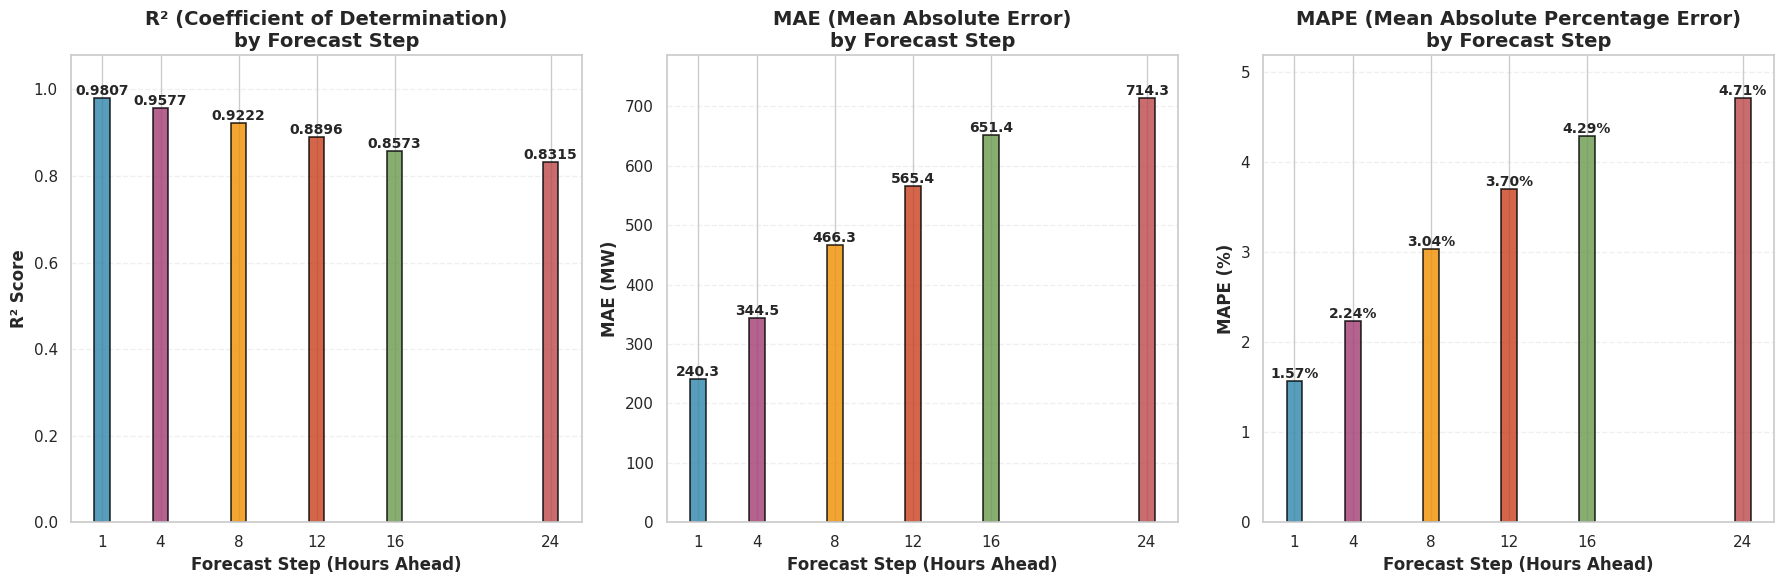


=== Combined Bar Chart (All Metrics) ===


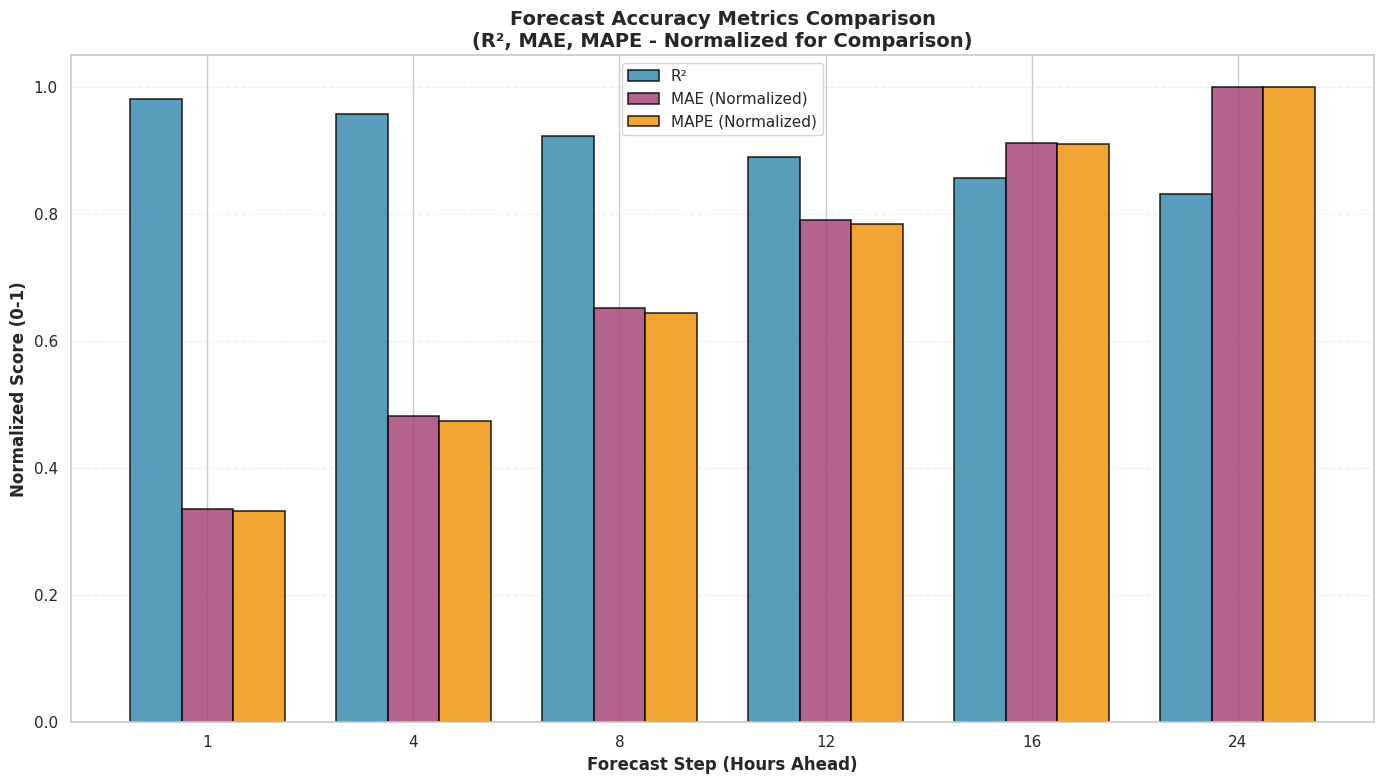


=== Individual Detailed Bar Charts ===


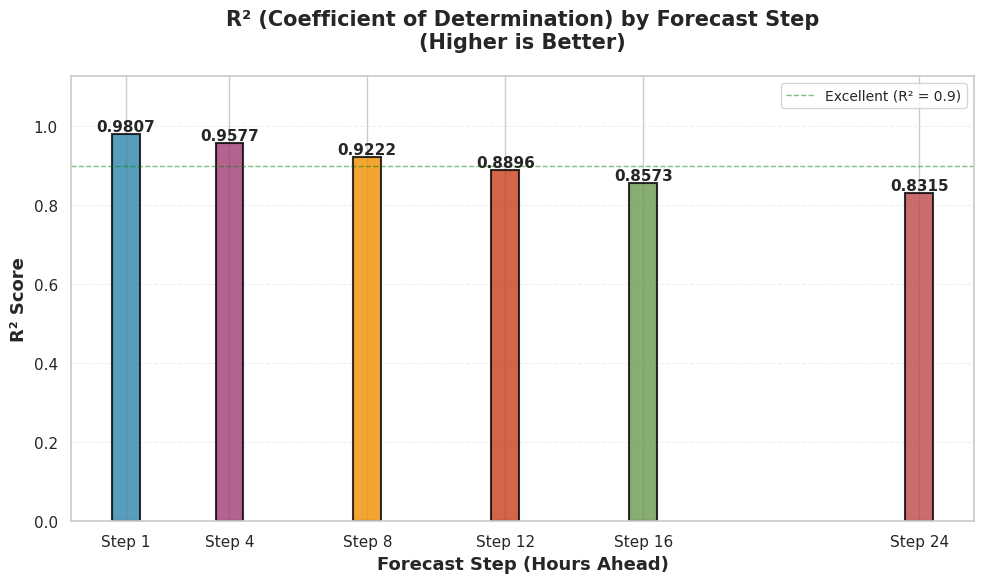

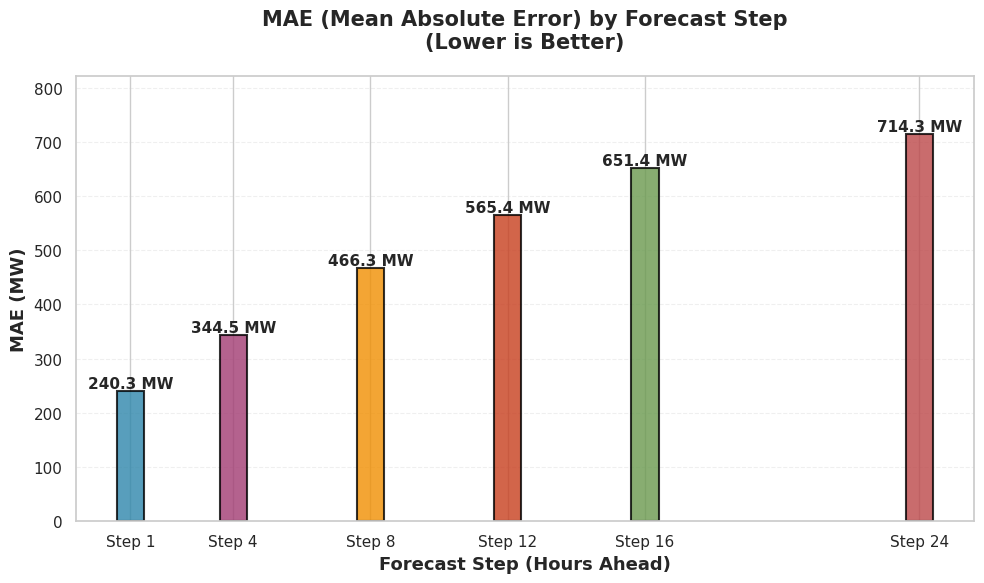

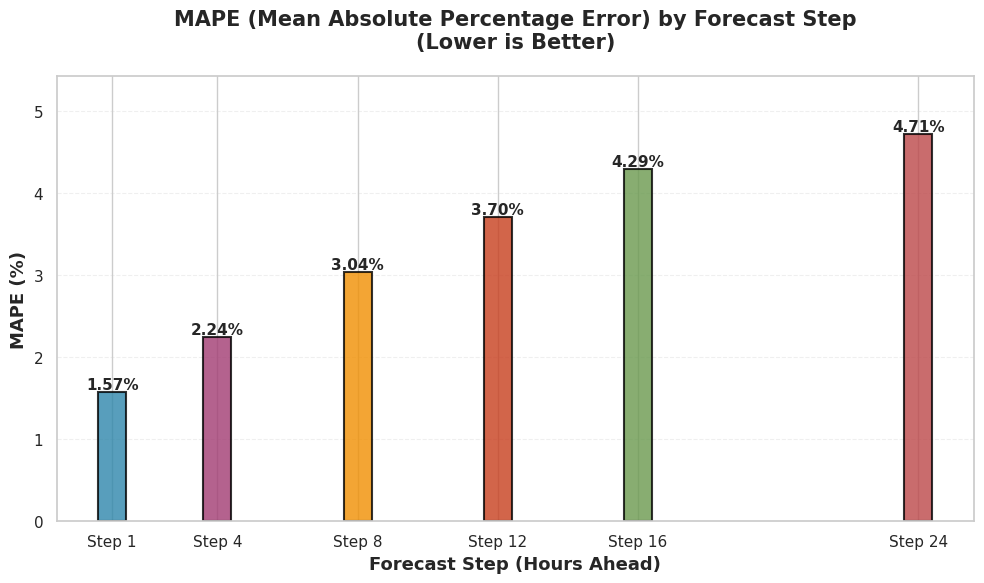


Charts generated successfully!


In [42]:
# ============================================================================
# VISUALIZATION: BAR CHARTS FOR R², MAE, AND MAPE
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Generating Bar Charts for Forecast Accuracy Metrics ===")
print(f"{'='*70}")

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Extract data for plotting
steps = [r['Step'] for r in metrics_results]
r2_values = [r['R²'] for r in metrics_results]
mae_values = [r['MAE'] for r in metrics_results]
mape_values = [r['MAPE (%)'] for r in metrics_results]

# Color scheme
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']

# Plot 1: R² (Coefficient of Determination)
ax1 = axes[0]
bars1 = ax1.bar(steps, r2_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_xlabel('Forecast Step (Hours Ahead)', fontsize=12, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax1.set_title('R² (Coefficient of Determination)\nby Forecast Step', fontsize=14, fontweight='bold')
ax1.set_xticks(steps)
ax1.set_xticklabels(steps)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, max(r2_values) * 1.1 if max(r2_values) > 0 else 1.0])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, r2_values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: MAE (Mean Absolute Error)
ax2 = axes[1]
bars2 = ax2.bar(steps, mae_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_xlabel('Forecast Step (Hours Ahead)', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAE (MW)', fontsize=12, fontweight='bold')
ax2.set_title('MAE (Mean Absolute Error)\nby Forecast Step', fontsize=14, fontweight='bold')
ax2.set_xticks(steps)
ax2.set_xticklabels(steps)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0, max(mae_values) * 1.1])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars2, mae_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: MAPE (Mean Absolute Percentage Error)
ax3 = axes[2]
bars3 = ax3.bar(steps, mape_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
ax3.set_xlabel('Forecast Step (Hours Ahead)', fontsize=12, fontweight='bold')
ax3.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
ax3.set_title('MAPE (Mean Absolute Percentage Error)\nby Forecast Step', fontsize=14, fontweight='bold')
ax3.set_xticks(steps)
ax3.set_xticklabels(steps)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim([0, max(mape_values) * 1.1])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars3, mape_values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Alternative: Single figure with all three metrics (for comparison)
print(f"\n{'='*70}")
print(f"=== Combined Bar Chart (All Metrics) ===")
print(f"{'='*70}")

fig2, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(steps))
width = 0.25  # Width of bars

# Normalize values for comparison (optional - you can skip this and use actual values)
# For R², we'll use as-is (already 0-1 scale)
# For MAE and MAPE, we'll normalize to 0-1 scale for visual comparison
mae_max = max(mae_values)
mape_max = max(mape_values)

bars_r2 = ax.bar(x - width, r2_values, width, label='R²', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.2)
bars_mae = ax.bar(x, [v/mae_max for v in mae_values], width, label='MAE (Normalized)', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.2)
bars_mape = ax.bar(x + width, [v/mape_max for v in mape_values], width, label='MAPE (Normalized)', color='#F18F01', alpha=0.8, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Forecast Step (Hours Ahead)', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Score (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Forecast Accuracy Metrics Comparison\n(R², MAE, MAPE - Normalized for Comparison)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Create individual detailed charts (larger, with more information)
print(f"\n{'='*70}")
print(f"=== Individual Detailed Bar Charts ===")
print(f"{'='*70}")

# R² Chart
fig3, ax_r2 = plt.subplots(figsize=(10, 6))
bars_r2_detailed = ax_r2.bar(steps, r2_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax_r2.set_xlabel('Forecast Step (Hours Ahead)', fontsize=13, fontweight='bold')
ax_r2.set_ylabel('R² Score', fontsize=13, fontweight='bold')
ax_r2.set_title('R² (Coefficient of Determination) by Forecast Step\n(Higher is Better)',
                fontsize=15, fontweight='bold', pad=20)
ax_r2.set_xticks(steps)
ax_r2.set_xticklabels([f'Step {s}' for s in steps], fontsize=11)
ax_r2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax_r2.set_ylim([0, max(r2_values) * 1.15 if max(r2_values) > 0 else 1.0])

# Add value labels
for bar, val in zip(bars_r2_detailed, r2_values):
    height = bar.get_height()
    ax_r2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add horizontal line at 0.9 for reference (good R² threshold)
ax_r2.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Excellent (R² = 0.9)')
ax_r2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# MAE Chart
fig4, ax_mae = plt.subplots(figsize=(10, 6))
bars_mae_detailed = ax_mae.bar(steps, mae_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax_mae.set_xlabel('Forecast Step (Hours Ahead)', fontsize=13, fontweight='bold')
ax_mae.set_ylabel('MAE (MW)', fontsize=13, fontweight='bold')
ax_mae.set_title('MAE (Mean Absolute Error) by Forecast Step\n(Lower is Better)',
                fontsize=15, fontweight='bold', pad=20)
ax_mae.set_xticks(steps)
ax_mae.set_xticklabels([f'Step {s}' for s in steps], fontsize=11)
ax_mae.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax_mae.set_ylim([0, max(mae_values) * 1.15])

# Add value labels
for bar, val in zip(bars_mae_detailed, mae_values):
    height = bar.get_height()
    ax_mae.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f} MW',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# MAPE Chart
fig5, ax_mape = plt.subplots(figsize=(10, 6))
bars_mape_detailed = ax_mape.bar(steps, mape_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax_mape.set_xlabel('Forecast Step (Hours Ahead)', fontsize=13, fontweight='bold')
ax_mape.set_ylabel('MAPE (%)', fontsize=13, fontweight='bold')
ax_mape.set_title('MAPE (Mean Absolute Percentage Error) by Forecast Step\n(Lower is Better)',
                fontsize=15, fontweight='bold', pad=20)
ax_mape.set_xticks(steps)
ax_mape.set_xticklabels([f'Step {s}' for s in steps], fontsize=11)
ax_mape.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax_mape.set_ylim([0, max(mape_values) * 1.15])

# Add value labels
for bar, val in zip(bars_mape_detailed, mape_values):
    height = bar.get_height()
    ax_mape.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Charts generated successfully!")
print(f"{'='*70}")


=== Generating Bar Charts for Forecast Accuracy Metrics ===


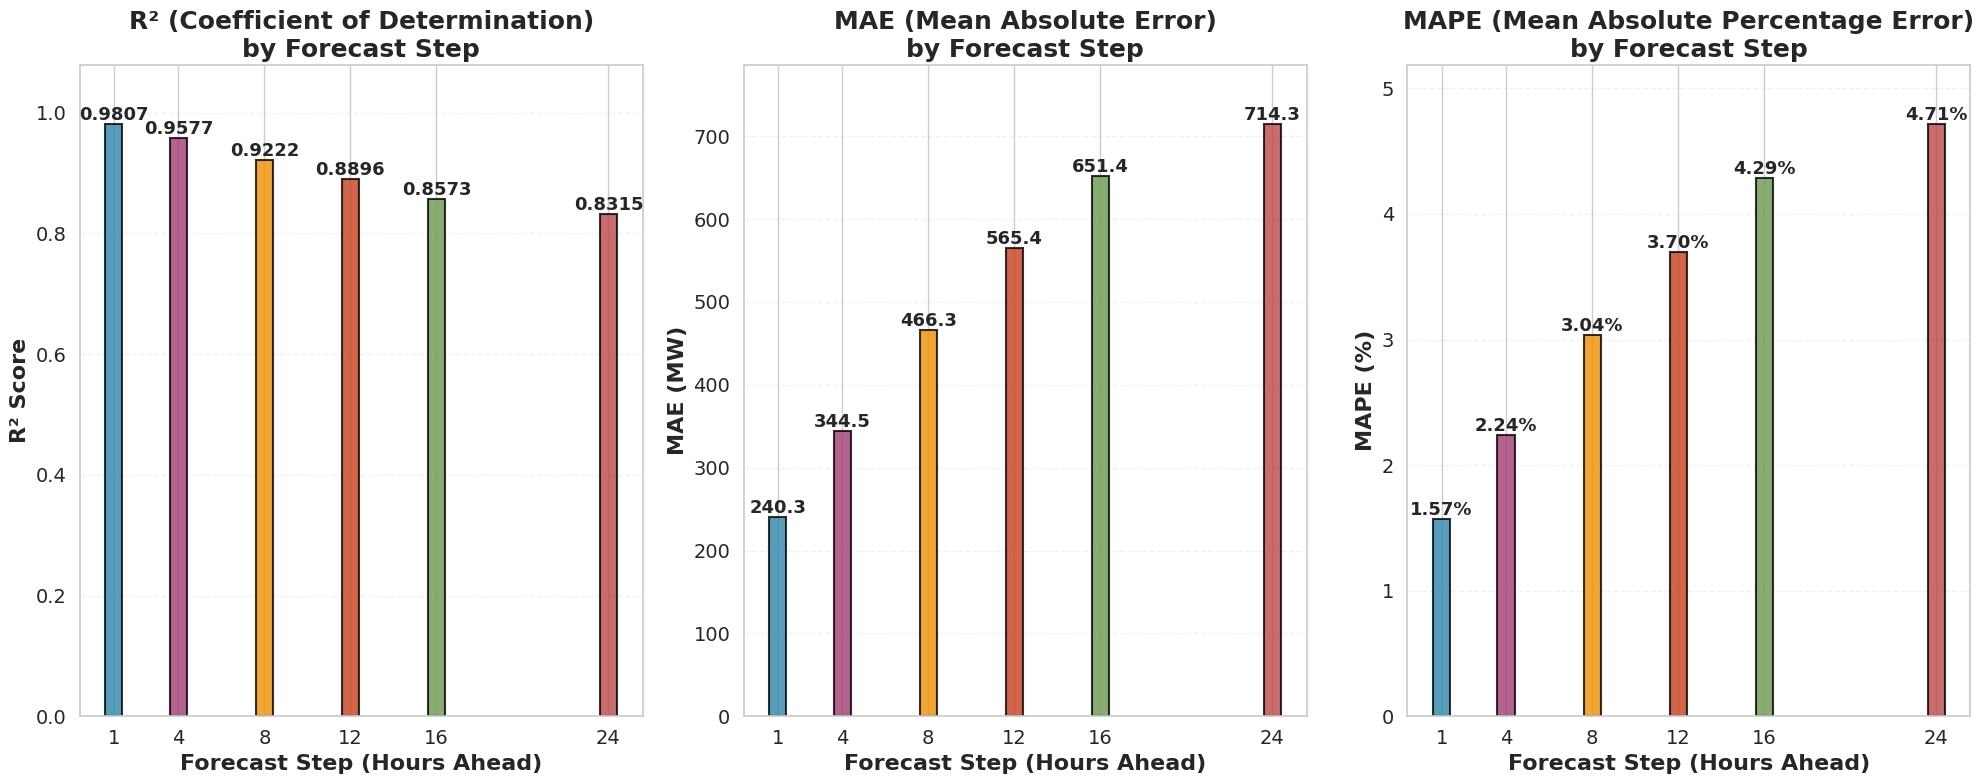


Charts generated successfully!


In [43]:
# ============================================================================
# VISUALIZATION: BAR CHARTS FOR R², MAE, AND MAPE
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Generating Bar Charts for Forecast Accuracy Metrics ===")
print(f"{'='*70}")

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Extract data for plotting
steps = [r['Step'] for r in metrics_results]
r2_values = [r['R²'] for r in metrics_results]
mae_values = [r['MAE'] for r in metrics_results]
mape_values = [r['MAPE (%)'] for r in metrics_results]

# Color scheme
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749']

# Plot 1: R² (Coefficient of Determination)
ax1 = axes[0]
bars1 = ax1.bar(steps, r2_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Forecast Step (Hours Ahead)', fontsize=16, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=16, fontweight='bold')
ax1.set_title('R² (Coefficient of Determination)\nby Forecast Step', fontsize=18, fontweight='bold')
ax1.set_xticks(steps)
ax1.set_xticklabels(steps, fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0, max(r2_values) * 1.1 if max(r2_values) > 0 else 1.0])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, r2_values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

# Plot 2: MAE (Mean Absolute Error)
ax2 = axes[1]
bars2 = ax2.bar(steps, mae_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Forecast Step (Hours Ahead)', fontsize=16, fontweight='bold')
ax2.set_ylabel('MAE (MW)', fontsize=16, fontweight='bold')
ax2.set_title('MAE (Mean Absolute Error)\nby Forecast Step', fontsize=18, fontweight='bold')
ax2.set_xticks(steps)
ax2.set_xticklabels(steps, fontsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0, max(mae_values) * 1.1])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars2, mae_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

# Plot 3: MAPE (Mean Absolute Percentage Error)
ax3 = axes[2]
bars3 = ax3.bar(steps, mape_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Forecast Step (Hours Ahead)', fontsize=16, fontweight='bold')
ax3.set_ylabel('MAPE (%)', fontsize=16, fontweight='bold')
ax3.set_title('MAPE (Mean Absolute Percentage Error)\nby Forecast Step', fontsize=18, fontweight='bold')
ax3.set_xticks(steps)
ax3.set_xticklabels(steps, fontsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim([0, max(mape_values) * 1.1])

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars3, mape_values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.2f}%',
             ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Charts generated successfully!")
print(f"{'='*70}")


=== Generating Bar Chart for Displacement Score (DS) ===


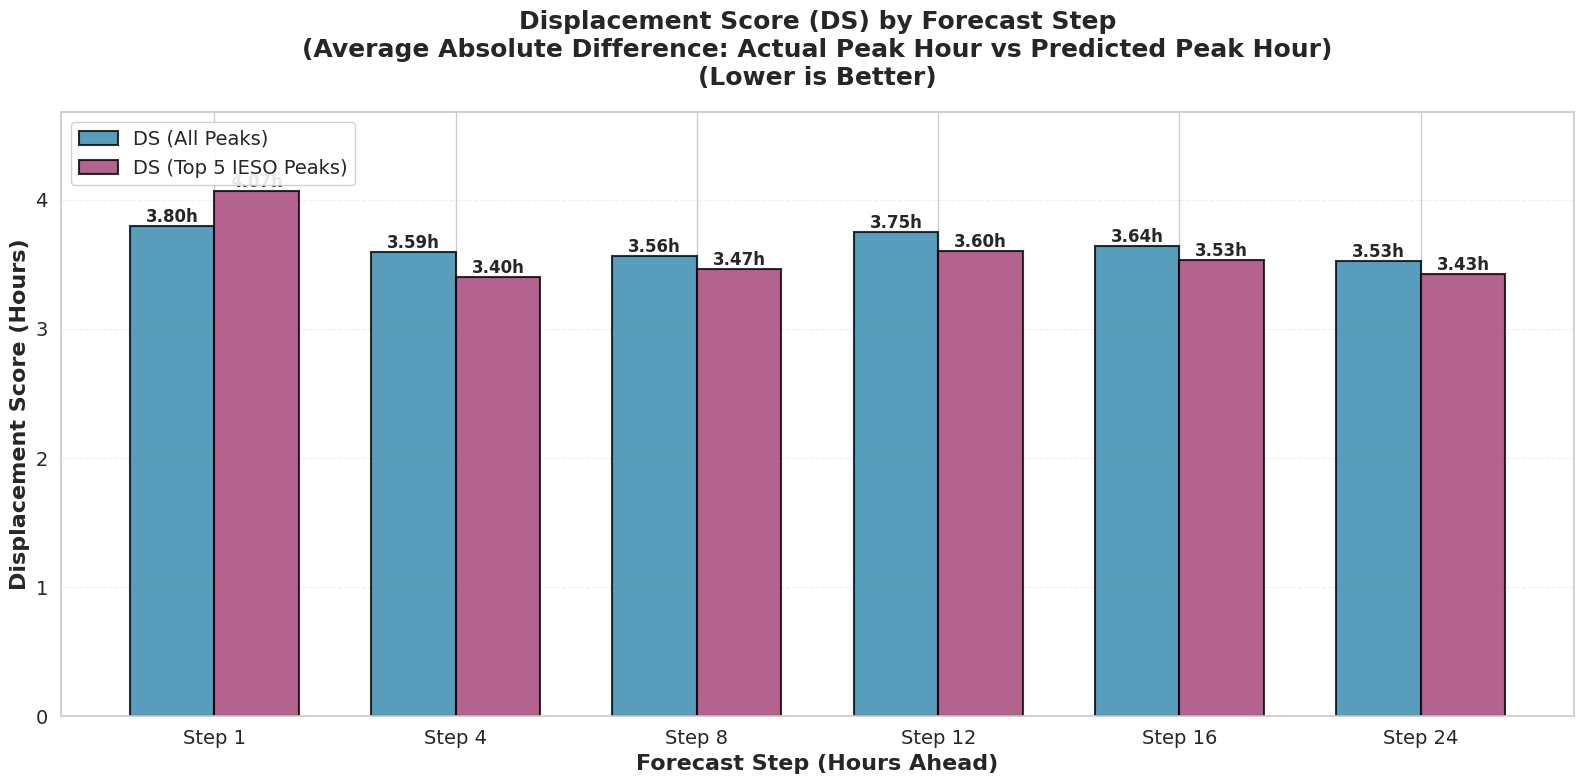


Displacement Score chart generated successfully!


In [44]:
# ============================================================================
# VISUALIZATION: BAR CHART FOR DISPLACEMENT SCORE (DS)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Generating Bar Chart for Displacement Score (DS) ===")
print(f"{'='*70}")

# Extract data for plotting
steps = [r['Step'] for r in metrics_results]
ds_all_peaks = [r['DS (All Peaks)'] for r in metrics_results]
ds_top5_ieso = [r['DS (Top 5 IESO)'] for r in metrics_results]

# Create figure
fig, ax = plt.subplots(figsize=(16, 8))

# Set up bar positions
x = np.arange(len(steps))
width = 0.35  # Width of bars

# Create bars
bars1 = ax.bar(x - width/2, ds_all_peaks, width, label='DS (All Peaks)',
               color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, ds_top5_ieso, width, label='DS (Top 5 IESO Peaks)',
               color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.5)

# Customize axes
ax.set_xlabel('Forecast Step (Hours Ahead)', fontsize=16, fontweight='bold')
ax.set_ylabel('Displacement Score (Hours)', fontsize=16, fontweight='bold')
ax.set_title('Displacement Score (DS) by Forecast Step\n(Average Absolute Difference: Actual Peak Hour vs Predicted Peak Hour)\n(Lower is Better)',
            fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Step {s}' for s in steps], fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}h',
                   ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add legend
ax.legend(fontsize=14, loc='upper left', framealpha=0.9)

# Set y-axis limits
max_ds = max([ds for ds in ds_all_peaks + ds_top5_ieso if not np.isnan(ds)])
ax.set_ylim([0, max_ds * 1.15])

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Displacement Score chart generated successfully!")
print(f"{'='*70}")

## Post Processing

In [45]:
# IESO Top 5 Peak Hours Configuration
IESO_TOP5_PEAKS = {
    2021: [
        {'date': '2021-08-24', 'hour_ending': 17, 'rank': 1},
        {'date': '2021-08-26', 'hour_ending': 14, 'rank': 2},
        {'date': '2021-08-23', 'hour_ending': 17, 'rank': 3},
        {'date': '2021-08-09', 'hour_ending': 17, 'rank': 4},
        {'date': '2021-08-25', 'hour_ending': 20, 'rank': 5},
    ],
    2022: [
        {'date': '2022-07-19', 'hour_ending': 17, 'rank': 1},
        {'date': '2022-07-20', 'hour_ending': 15, 'rank': 2},
        {'date': '2022-06-22', 'hour_ending': 17, 'rank': 3},
        {'date': '2022-08-29', 'hour_ending': 17, 'rank': 4},
        {'date': '2022-08-06', 'hour_ending': 18, 'rank': 5},
    ],
    2023: [
        {'date': '2023-09-05', 'hour_ending': 17, 'rank': 1},
        {'date': '2023-09-06', 'hour_ending': 17, 'rank': 2},
        {'date': '2023-07-05', 'hour_ending': 17, 'rank': 3},
        {'date': '2023-07-04', 'hour_ending': 19, 'rank': 4},
        {'date': '2023-07-06', 'hour_ending': 12, 'rank': 5},
    ]
}

In [45]:
import numpy as np
import pandas as pd


def prev_year_baseline_stats(actual_series, years):
    """
    For each year Y in years, compute baseline (mu, sd) from actuals in ALL years
    strictly before Y (cumulative history).
    - 2021: use all data with year < 2021 (e.g. 2020, 2019, ...)
    - 2022: use all data with year < 2022 (e.g. 2021, 2020, ...)
    - 2023: use all data with year < 2023 (e.g. 2022, 2021, 2020, ...)
    """
    baseline = {}
    for y in years:
        prior_data = actual_series[actual_series.index.year < y].dropna()
        if len(prior_data) == 0:
            baseline[y] = (np.nan, np.nan)
            continue
        mu = float(prior_data.mean())
        sd = float(prior_data.std(ddof=0))
        baseline[y] = (mu, sd if sd > 0 else np.nan)
    return baseline

def zscore_with_baseline(series: pd.Series, baseline_by_year: dict):
    """
    Compute z = (x - mu_prev) / sd_prev for each year, using baseline_by_year[year].
    """
    out = pd.Series(index=series.index, dtype=float)
    for y, (mu, sd) in baseline_by_year.items():
        mask = series.index.year == y
        if not np.isfinite(mu) or not np.isfinite(sd):
            out.loc[mask] = np.nan
        else:
            out.loc[mask] = (series.loc[mask] - mu) / (sd + 1e-8)
    return out

def add_walkforward_zscores(df_horizon: pd.DataFrame, years_eval):
    """
    Adds:
      - zscore_actual_prevyear
      - zscore_forecast_prevyear
    Baseline is previous-year ACTUAL stats.
    """
    baseline = prev_year_baseline_stats(df_horizon['actual'], years_eval)
    df = df_horizon.copy()
    df['zscore_actual_prevyear'] = zscore_with_baseline(df['actual'], baseline)
    df['zscore_forecast_prevyear'] = zscore_with_baseline(df['forecast'], baseline)
    return df


=== Confusion Matrix Comparison for All Horizons with Cost/Savings Analysis ===

Processing horizon 1...

Processing horizon 4...

Processing horizon 8...

Processing horizon 12...

Processing horizon 16...

Processing horizon 20...

Processing horizon 24...

Confusion Matrix Results with Cost/Savings (by Year):
 Horizon  Year   TP   TN  FP  FN  Accuracy  Precision   Recall  F1-Score  Total_Savings_($)  Adjusted_Savings_($)
       1  2021 1039 7538 123  62  0.978886   0.894148 0.943688  0.918250         -127282.32            -127282.32
       1  2022  244 8420  28  70  0.988815   0.897059 0.777070  0.832765          176336.96             176336.96
       1  2023  143 8564  14  17  0.996452   0.910828 0.893750  0.902208          258874.24             258874.24
       4  2021  955 7534 188  85  0.968843   0.835521 0.918269  0.874943         -124334.56            -124334.56
       4  2022  212 8414  34 102  0.984478   0.861789 0.675159  0.757143          188128.00             188128.00
 

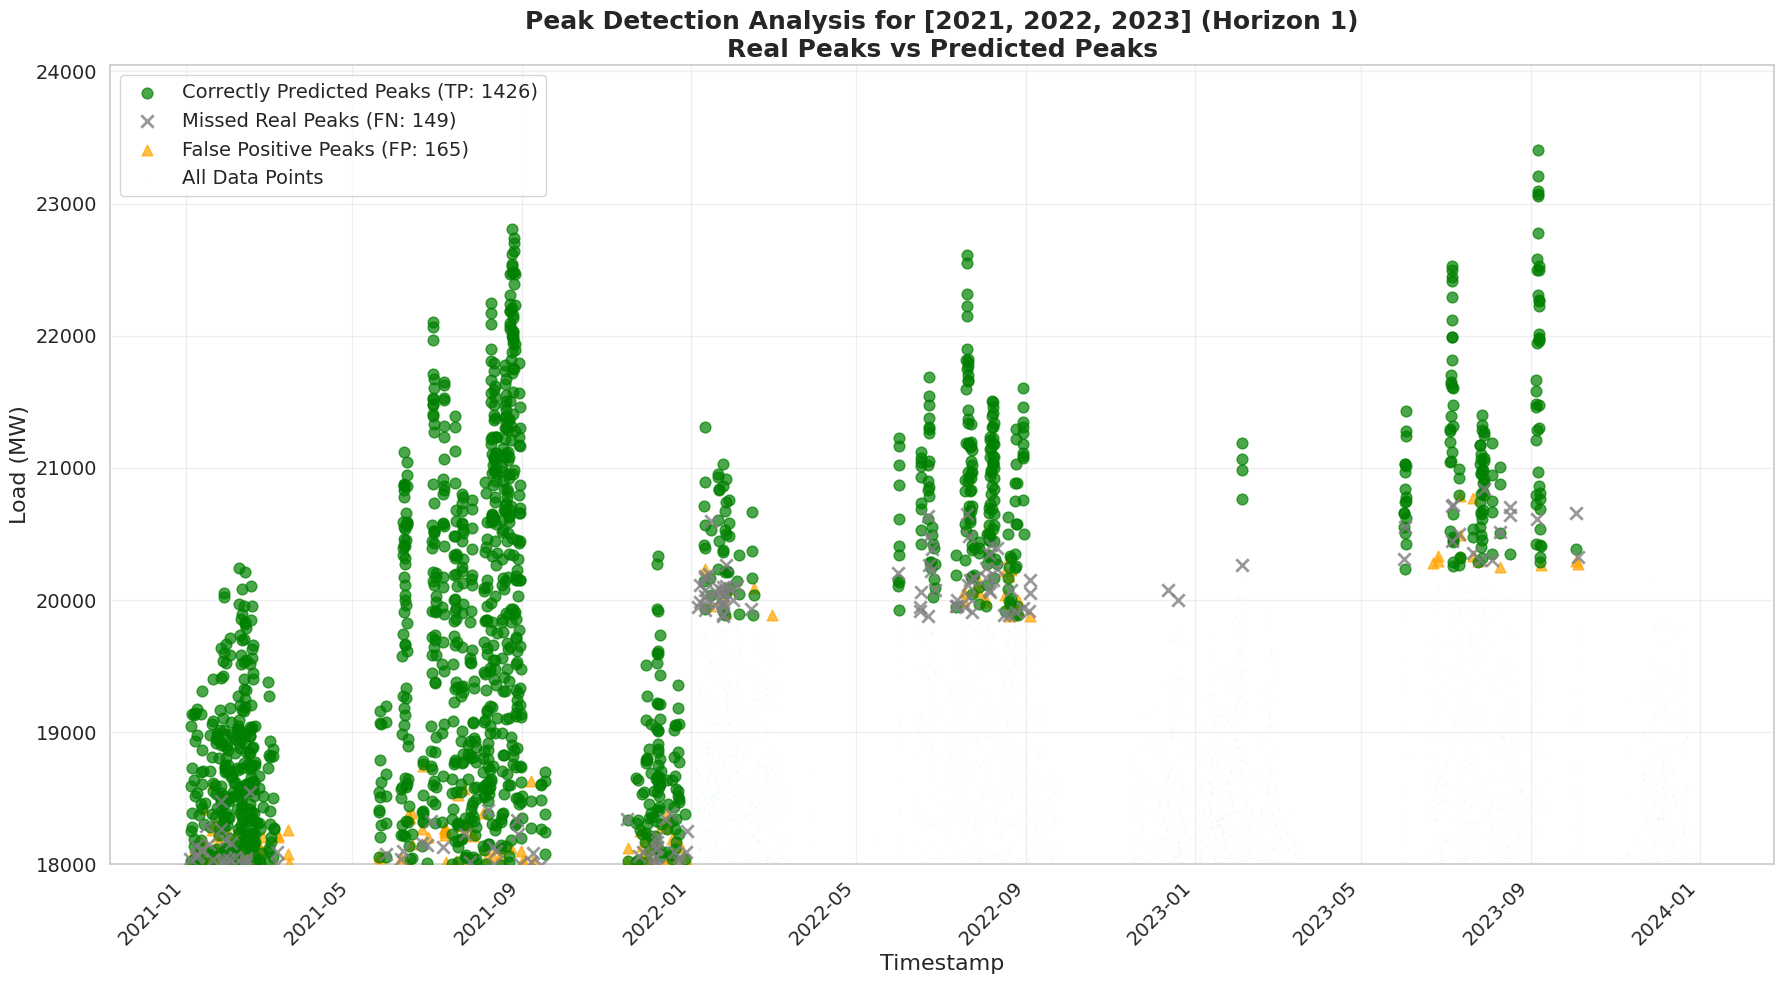


=== Peak Detection Summary for [2021, 2022, 2023] (Horizon 1) ===
Total actual peaks: 1575
Total predicted peaks: 1591
True Positives (correctly predicted): 1426
False Negatives (missed real peaks): 149
False Positives (predicted but not actual): 165
Recall (of actual peaks, how many were caught): 0.9054 (90.54%)


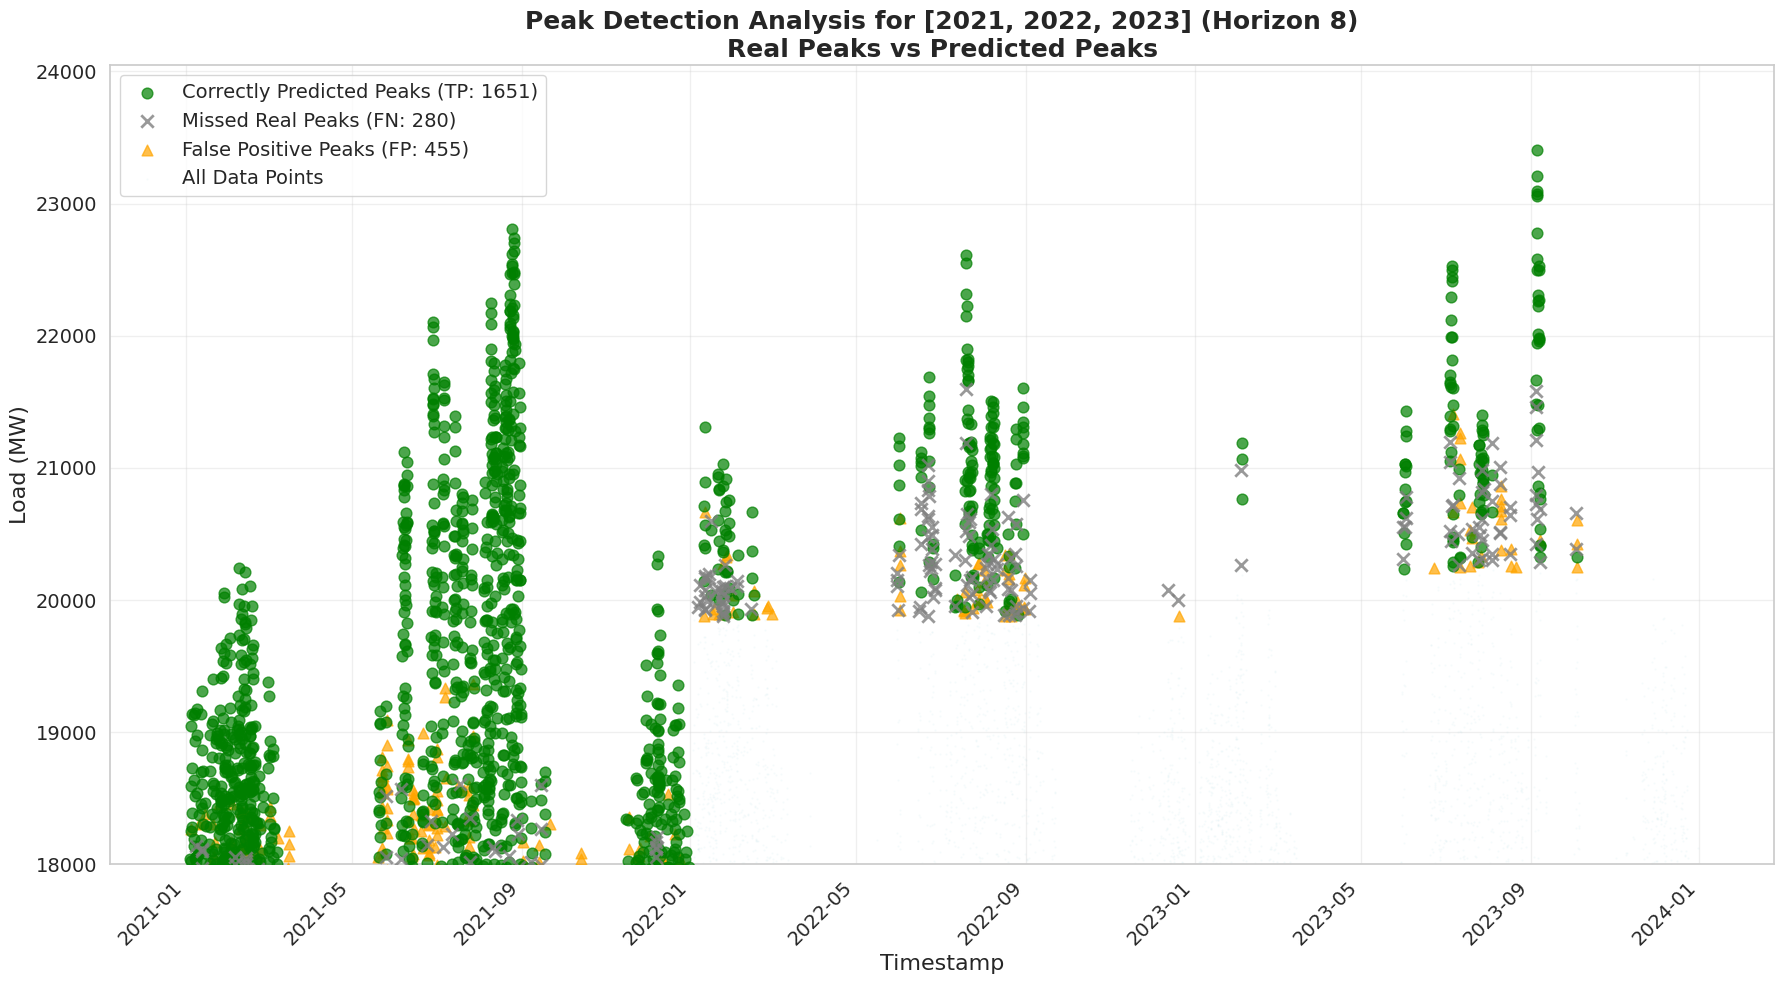


=== Peak Detection Summary for [2021, 2022, 2023] (Horizon 8) ===
Total actual peaks: 1931
Total predicted peaks: 2106
True Positives (correctly predicted): 1651
False Negatives (missed real peaks): 280
False Positives (predicted but not actual): 455
Recall (of actual peaks, how many were caught): 0.8550 (85.50%)

=== Filtering: Rows where peak_forecast OR peak_actual == 1 ===
Total rows with peaks: 1740
Percentage of total: 6.62%

Breakdown:
  Rows with peak_actual == 1: 1575
  Rows with peak_forecast == 1: 1591
  Rows with both peaks: 1426
  Rows with only actual peak: 149
  Rows with only forecast peak: 165

✓ Filtered DataFrame saved as 'Ontario_peaks_only'

=== Days with Multiple Peak Hours (2022-2023) ===
Days with multiple peak hours: 235


,date,num_actual_peaks,num_forecast_peaks
3,2021-01-04,4,4
4,2021-01-05,4,6
5,2021-01-06,4,5
6,2021-01-07,4,5
7,2021-01-08,7,5
...,...,...,...
976,2023-09-04,8,8
977,2023-09-05,13,12
978,2023-09-06,12,12
979,2023-09-07,8,9



=== Updated Peak Detection Logic ===

Running updated peak detection...
Z-score threshold: 2.0
Window size: 8 hours

✓ Peak detection complete
Total days analyzed: 1095

=== Classification Summary (Overall) ===
classification
TN    836
TP    226
FN     22
FP     11
Name: count, dtype: int64

=== Performance Metrics (Overall) ===
True Positives (TP):  226
False Positives (FP): 11
False Negatives (FN): 22
True Negatives (TN):  836

Precision:  0.9536 (95.36%)
Recall:     0.9113 (91.13%)
F1-Score:   0.9320
False Positive Rate: 0.0130 (1.30%)

=== Year-by-Year Breakdown ===

YEAR 2020
Total days: 1

Classification counts:
  True Positives (TP):  0
  False Positives (FP): 0
  False Negatives (FN): 0
  True Negatives (TN):  1

Performance metrics:
  Precision:  0.0000 (0.00%)
  Recall:     0.0000 (0.00%)
  F1-Score:   0.0000
  False Positive Rate: 0.0000 (0.00%)

Classification distribution:
  TN:    1 (100.00%)

YEAR 2021
Total days: 365

Classification counts:
  True Positives (TP):  152


,date,has_true_peak,has_predicted_peak,true_peak_timestamp,predicted_window_start
0,2020-12-31,False,False,NaT,NaT



=== YEAR 2021 - Days with True Peaks ===
Total days with true peaks in 2021: 160


...

,date,has_true_peak,has_predicted_peak,true_peak_timestamp,predicted_window_start
731,2023-01-01,False,False,NaT,NaT
732,2023-01-02,False,False,NaT,NaT
733,2023-01-03,False,False,NaT,NaT
734,2023-01-04,False,False,NaT,NaT
735,2023-01-05,False,False,NaT,NaT
736,2023-01-06,False,False,NaT,NaT
737,2023-01-07,False,False,NaT,NaT
738,2023-01-08,False,False,NaT,NaT
739,2023-01-09,False,False,NaT,NaT
740,2023-01-10,False,False,NaT,NaT



=== Overall - Days with True Peaks ===
Total days with true peaks: 248


,date,year,true_peak_timestamp,true_peak_demand,classification
3,2021-01-03,2021,2021-01-03 17:00:00,18042.0,FN
4,2021-01-04,2021,2021-01-04 17:00:00,19048.0,TP
5,2021-01-05,2021,2021-01-05 17:00:00,19137.0,TP
6,2021-01-06,2021,2021-01-06 17:00:00,19131.0,TP
7,2021-01-07,2021,2021-01-07 17:00:00,19144.0,TP
8,2021-01-08,2021,2021-01-08 17:00:00,19177.0,TP
9,2021-01-09,2021,2021-01-09 17:00:00,18068.0,FN
10,2021-01-10,2021,2021-01-10 17:00:00,18376.0,TP
11,2021-01-11,2021,2021-01-11 17:00:00,19135.0,TP
12,2021-01-12,2021,2021-01-12 17:00:00,19311.0,TP



=== Overall - Days with Predicted Peaks ===
Total days with predicted peaks: 237


,date,year,predicted_window_start,predicted_window_end,predicted_window_sum,classification
4,2021-01-04,2021,2021-01-04 13:00:00,2021-01-04 20:00:00,145053.585790,TP
5,2021-01-05,2021,2021-01-05 13:00:00,2021-01-05 20:00:00,146098.203358,TP
6,2021-01-06,2021,2021-01-06 13:00:00,2021-01-06 20:00:00,145197.775855,TP
7,2021-01-07,2021,2021-01-07 14:00:00,2021-01-07 21:00:00,144946.527657,TP
8,2021-01-08,2021,2021-01-08 14:00:00,2021-01-08 21:00:00,145218.992576,TP
10,2021-01-10,2021,2021-01-10 14:00:00,2021-01-10 21:00:00,139054.920355,TP
11,2021-01-11,2021,2021-01-11 13:00:00,2021-01-11 20:00:00,146315.818006,TP
12,2021-01-12,2021,2021-01-12 13:00:00,2021-01-12 20:00:00,147914.334245,TP
13,2021-01-13,2021,2021-01-13 13:00:00,2021-01-13 20:00:00,143811.355008,TP
14,2021-01-14,2021,2021-01-14 13:00:00,2021-01-14 20:00:00,141284.176734,TP


In [46]:
## Ontario Post-Processing with Configurable Horizon

import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Configuration
ZSCORE_THRESHOLD = 2.0  # Z-score threshold for peak detection (can be adjusted)
PEAK_QUANTILE = 0.98  # Alternative: use quantile-based threshold per year
WINDOW_HOURS =8  # Window size for prediction (for detect_peaks_updated)
SAVINGS_SLOPE = -368.47  # Savings formula slope
SAVINGS_INTERCEPT = 335516  # Savings formula intercept
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT / 5  # 335,516 / 5 = $67,103.20

def extract_ontario_horizon(ontario_result, horizon=1):
    """
    Extract Ontario data for a specific forecast horizon.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps' keys
    horizon : int
        Forecast horizon (1-24)

    Returns:
    --------
    pd.DataFrame with columns: timestamp, actual, forecast
    """
    h_idx = horizon - 1
    if h_idx >= ontario_result['timestamps'].shape[1]:
        raise ValueError(f"Horizon {horizon} exceeds maximum forecast steps ({ontario_result['timestamps'].shape[1]})")

    timestamps = pd.to_datetime(ontario_result['timestamps'][:, h_idx])
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual': ontario_result['actuals'][:, h_idx],
        'forecast': ontario_result['predictions'][:, h_idx],
    })
    df = df[~df.index.duplicated(keep='first')].sort_values('timestamp').reset_index(drop=True)
    df.set_index('timestamp', inplace=True)
    return df

def aggregate_ontario_features(city_frames):
    """
    Aggregate weather features across all cities to create Ontario-level features.
    Uses mean aggregation for most features.

    Parameters:
    -----------
    city_frames : dict
        Dictionary of city dataframes with weather features

    Returns:
    --------
    pd.DataFrame with aggregated Ontario features
    """
    # List of feature columns to aggregate (excluding city-specific load columns)
    feature_cols = ['temp', 'solarradiation', 'humidity', 'precip',
                    'windspeed', 'cloudcover', 'hour', 'dayofw', 'month']

    # Start with first city's index
    first_city = list(city_frames.keys())[0]
    ontario_features = pd.DataFrame(index=city_frames[first_city].index)

    # Aggregate each feature across all cities
    for col in feature_cols:
        if col in city_frames[first_city].columns:
            # Collect the column from all cities that have it
            city_values = []
            for city_name, df_city in city_frames.items():
                if col in df_city.columns:
                    city_values.append(df_city[col])

            if city_values:
                # Align all series to the same index and take mean
                aligned = pd.concat(city_values, axis=1)
                aligned.columns = range(len(city_values))
                ontario_features[col] = aligned.mean(axis=1)

    return ontario_features

def detect_peaks_zscore(demand_series, threshold=2.0):
    """
    Detect peak hours using Z-score threshold.

    Parameters:
    -----------
    demand_series : pd.Series
        Series of demand values
    threshold : float
        Z-score threshold (default: 2.0)

    Returns:
    --------
    pd.Series with 1 for peaks, 0 for non-peaks
    """
    # Calculate z-scores, handling NaN values
    valid_mask = ~demand_series.isna()
    peak_status = pd.Series(0, index=demand_series.index, dtype=int)

    if valid_mask.sum() > 0:
        z_scores = zscore(demand_series[valid_mask])
        peak_status.loc[valid_mask] = (z_scores >= threshold).astype(int)

    return peak_status

def detect_peaks_quantile_per_year(demand_series, timestamps, quantile=0.98):
    """
    Detect peaks using year-specific quantile thresholds.
    Uses previous year's quantile for current year (except first year).

    Parameters:
    -----------
    demand_series : pd.Series
        Series of demand values
    timestamps : pd.DatetimeIndex
        Timestamps corresponding to demand_series
    quantile : float
        Quantile threshold (default: 0.98)

    Returns:
    --------
    pd.Series with 1 for peaks, 0 for non-peaks
    """
    df_temp = pd.DataFrame({
        'demand': demand_series.values,
        'year': pd.to_datetime(timestamps).year
    }, index=timestamps)

    peak_status = pd.Series(0, index=timestamps)
    years = sorted(df_temp['year'].unique())

    for i, year in enumerate(years):
        year_mask = df_temp['year'] == year

        if i == 0:
            # For first year, use its own quantile
            year_data = df_temp.loc[year_mask, 'demand']
            threshold = zscore(year_data).quantile(quantile)
        else:
            # For subsequent years, use previous year's quantile
            prev_year = years[i-1]
            prev_year_data = df_temp[df_temp['year'] == prev_year]['demand']
            threshold = zscore(prev_year_data).quantile(quantile)

        # Apply threshold to current year
        year_z_scores = zscore(df_temp.loc[year_mask, 'demand'])
        peak_status.loc[year_mask] = (year_z_scores >= threshold).astype(int)

    return peak_status

def prev_year_baseline_stats(actual_series, years):
    baseline = {}
    for y in years:
        prev = y - 1
        prev_data = actual_series[actual_series.index.year == prev].dropna()
        if len(prev_data) == 0:
            baseline[y] = (np.nan, np.nan)
            continue
        mu = float(prev_data.mean())
        sd = float(prev_data.std(ddof=0))
        baseline[y] = (mu, sd if sd > 0 else np.nan)
    return baseline

def zscore_with_baseline(series, baseline_by_year):
    out = pd.Series(index=series.index, dtype=float)
    for y, (mu, sd) in baseline_by_year.items():
        mask = series.index.year == y
        if not np.isfinite(mu) or not np.isfinite(sd):
            out.loc[mask] = np.nan
        else:
            out.loc[mask] = (series.loc[mask] - mu) / (sd + 1e-8)
    return out

def add_walkforward_zscores(df_horizon, years_eval):
    baseline = prev_year_baseline_stats(df_horizon["actual"], years_eval)
    df = df_horizon.copy()
    df["zscore_actual_prevyear"] = zscore_with_baseline(df["actual"], baseline)
    df["zscore_forecast_prevyear"] = zscore_with_baseline(df["forecast"], baseline)
    return df



'''
def create_ontario_peak_dataframe(ontario_result, city_frames, horizon=1,
                                  peak_method='zscore', threshold=2.0, quantile=0.98):
    """
    Create Ontario peak analysis DataFrame with all features, predictions, and peak status.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps'
    city_frames : dict
        Dictionary of city dataframes with weather features
    horizon : int
        Forecast horizon (1-24)
    peak_method : str
        'zscore' or 'quantile' for peak detection method
    threshold : float
        Z-score threshold (if method='zscore')
    quantile : float
        Quantile threshold (if method='quantile')

    Returns:
    --------
    pd.DataFrame with all features, actual, forecast, and peak columns
    """
    # Extract horizon-specific data
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)

    # Aggregate features from all cities
    ontario_features = aggregate_ontario_features(city_frames)

    # Align features with horizon timestamps
    df_combined = df_horizon.copy()
    df_combined = df_combined.join(ontario_features, how='left')

    # Detect peaks for actual values
    if peak_method == 'zscore':
        df_combined['peak_actual'] = detect_peaks_zscore(df_combined['actual'], threshold=threshold)
    elif peak_method == 'quantile':
        df_combined['peak_actual'] = detect_peaks_quantile_per_year(
            df_combined['actual'], df_combined.index, quantile=quantile
        )
    else:
        raise ValueError(f"Unknown peak_method: {peak_method}. Use 'zscore' or 'quantile'")

    # Detect peaks for forecast values
    if peak_method == 'zscore':
        df_combined['peak_forecast'] = detect_peaks_zscore(df_combined['forecast'], threshold=threshold)
    elif peak_method == 'quantile':
        df_combined['peak_forecast'] = detect_peaks_quantile_per_year(
            df_combined['forecast'], df_combined.index, quantile=quantile
        )

    # Add year column for analysis
    df_combined['year'] = df_combined.index.year

    # Reorder columns: timestamp index, then actual/forecast, then features, then peak columns
    feature_cols = [col for col in ontario_features.columns if col not in ['actual', 'forecast']]
    column_order = ['actual', 'forecast'] + feature_cols + ['peak_actual', 'peak_forecast', 'year']
    df_combined = df_combined[[col for col in column_order if col in df_combined.columns]]

    return df_combined
'''
### new section added
def create_ontario_peak_dataframe(ontario_result, city_frames, horizon=1,
                                  peak_method='zscore_prevyear',
                                  threshold=2.0, quantile=0.98,
                                  years_eval=(2021, 2022, 2023)):
    # 1) Extract horizon-specific actual/forecast
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon).sort_index()

    # 2) Join Ontario-level features (same as before)
    ontario_features = aggregate_ontario_features(city_frames)
    df = df_horizon.join(ontario_features, how='left')

    # 3) Peak labeling
    if peak_method == 'zscore_prevyear':
        df = add_walkforward_zscores(df, years_eval)

        df['peak_actual'] = (df['zscore_actual_prevyear'] >= threshold).astype(int)
        df['peak_forecast'] = (df['zscore_forecast_prevyear'] >= threshold).astype(int)

    elif peak_method == 'quantile':
        # keep your quantile method if you still want it
        df['peak_actual'] = detect_peaks_quantile_per_year(df['actual'], df.index, quantile=quantile)
        df['peak_forecast'] = detect_peaks_quantile_per_year(df['forecast'], df.index, quantile=quantile)

    else:
        raise ValueError("peak_method must be 'zscore_prevyear' or 'quantile'")

    df['year'] = df.index.year

    # keep your column ordering idea (works even if zscore cols exist)
    feature_cols = [c for c in ontario_features.columns if c not in ['actual', 'forecast']]
    z_cols = [c for c in ['zscore_actual_prevyear', 'zscore_forecast_prevyear'] if c in df.columns]
    column_order = ['actual', 'forecast'] + z_cols + feature_cols + ['peak_actual', 'peak_forecast', 'year']
    df = df[[c for c in column_order if c in df.columns]]

    return df

'''
def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=8):
    """
    Detect peaks using updated logic:
    - Real data: One peak hour per day (highest demand among hours exceeding threshold)
    - Forecast: One peak window per day (rolling window with highest sum)

    Parameters:
    -----------
    df_ontario : pd.DataFrame
        Ontario DataFrame with 'actual' and 'forecast' columns
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    pd.DataFrame with daily peak information and classification
    """
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    # Calculate Z-scores for actual and forecast (handle NaN values)
    valid_actual = df['actual'].dropna()
    valid_forecast = df['forecast'].dropna()

    zscore_actual_values = zscore(valid_actual)
    zscore_forecast_values = zscore(valid_forecast)

    # Create aligned z-score series
    df['zscore_actual'] = pd.Series(zscore_actual_values, index=valid_actual.index)
    df['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    # Initialize results list
    results = []

    # Process each day
    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        # Find hours exceeding threshold
        above_threshold = day_data[day_data['zscore_actual'] >= zscore_threshold]

        if len(above_threshold) > 0:
            # Select hour with highest demand
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        # Generate rolling windows
        eligible_windows = []

        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            # Check if window is eligible (at least one hour above threshold)
            if (window_data['zscore_forecast'] >= zscore_threshold).any():
                # Sum all values in window
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            # Select window with highest sum
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            # Check if true peak hour falls within predicted window
            if best_window['start'] <= true_peak_idx <= best_window['end']:
                classification = 'TP'  # True Positive
            else:
                classification = 'FN'  # False Negative
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'  # False Negative
        elif not has_true_peak and has_predicted_peak:
            classification = 'FP'  # False Positive
        else:
            classification = 'TN'  # True Negative

        # Store results
        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        # Add true peak information
        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour['zscore_actual']
            # Store all features for true peak hour
            for col in day_data.columns:
                if col not in ['date', 'zscore_actual', 'zscore_forecast']:
                    result[f'true_peak_{col}'] = true_peak_hour[col]
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        # Add predicted peak window information
        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
            # Store all features for predicted window (as list/dict or aggregated)
            window_data = best_window['data']
            for col in window_data.columns:
                if col not in ['date', 'zscore_actual', 'zscore_forecast']:
                    # Store as list for window features
                    result[f'predicted_window_{col}'] = window_data[col].tolist()
                    # Also store mean for convenience
                    if col in ['actual', 'forecast', 'temp', 'humidity', 'windspeed', 'solarradiation']:
                        result[f'predicted_window_{col}_mean'] = window_data[col].mean()
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)

    # Add year column
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year

    return results_df
'''
'''
def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=8,
                        z_actual_col='zscore_actual_prevyear',
                        z_forecast_col='zscore_forecast_prevyear'):
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    if z_actual_col not in df.columns or z_forecast_col not in df.columns:
        raise ValueError(
            f"Missing z-score columns. Expected '{z_actual_col}' and '{z_forecast_col}'. "
            "Make sure you created df_ontario via create_ontario_peak_dataframe(..., peak_method='zscore_prevyear')."
        )

    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        above_threshold = day_data[day_data[z_actual_col] >= zscore_threshold]
        if len(above_threshold) > 0:
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            if (window_data[z_forecast_col] >= zscore_threshold).any():
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            classification = 'TP' if (best_window['start'] <= true_peak_idx <= best_window['end']) else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif (not has_true_peak) and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour[z_actual_col]
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year
    return results_df
'''
def detect_peaks_updated(df_ontario, zscore_threshold=2.0, window_hours=8,
                        z_actual_col='zscore_actual_prevyear',
                        z_forecast_col='zscore_forecast_prevyear'):
    df = df_ontario.copy()
    df['date'] = df.index.normalize()

    if z_actual_col not in df.columns or z_forecast_col not in df.columns:
        raise ValueError(
            f"Missing z-score columns. Expected '{z_actual_col}' and '{z_forecast_col}'. "
            "Make sure you created df_ontario via create_ontario_peak_dataframe(..., peak_method='zscore_prevyear')."
        )

    results = []

    for date in df['date'].unique():
        day_data = df[df['date'] == date].sort_index()

        # ===== REAL PEAK DETECTION =====
        above_threshold = day_data[day_data[z_actual_col] >= zscore_threshold]
        if len(above_threshold) > 0:
            true_peak_idx = above_threshold['actual'].idxmax()
            true_peak_hour = day_data.loc[true_peak_idx]
            has_true_peak = True
        else:
            true_peak_idx = None
            true_peak_hour = None
            has_true_peak = False

        # ===== FORECAST PEAK DETECTION =====
        eligible_windows = []
        for i in range(len(day_data) - window_hours + 1):
            window_data = day_data.iloc[i:i+window_hours]
            window_start = window_data.index[0]
            window_end = window_data.index[-1]

            if (window_data[z_forecast_col] >= zscore_threshold).any():
                window_sum = window_data['forecast'].sum()
                eligible_windows.append({
                    'start': window_start,
                    'end': window_end,
                    'sum': window_sum,
                    'data': window_data
                })

        if len(eligible_windows) > 0:
            best_window = max(eligible_windows, key=lambda x: x['sum'])
            has_predicted_peak = True
        else:
            best_window = None
            has_predicted_peak = False

        # ===== CLASSIFICATION =====
        if has_true_peak and has_predicted_peak:
            classification = 'TP' if (best_window['start'] <= true_peak_idx <= best_window['end']) else 'FN'
        elif has_true_peak and not has_predicted_peak:
            classification = 'FN'
        elif (not has_true_peak) and has_predicted_peak:
            classification = 'FP'
        else:
            classification = 'TN'

        result = {
            'date': date,
            'has_true_peak': has_true_peak,
            'has_predicted_peak': has_predicted_peak,
            'classification': classification,
        }

        if has_true_peak:
            result['true_peak_timestamp'] = true_peak_idx
            result['true_peak_demand'] = true_peak_hour['actual']
            result['true_peak_zscore'] = true_peak_hour[z_actual_col]
        else:
            result['true_peak_timestamp'] = None
            result['true_peak_demand'] = None
            result['true_peak_zscore'] = None

        if has_predicted_peak:
            result['predicted_window_start'] = best_window['start']
            result['predicted_window_end'] = best_window['end']
            result['predicted_window_sum'] = best_window['sum']
            result['predicted_window_hours'] = window_hours
        else:
            result['predicted_window_start'] = None
            result['predicted_window_end'] = None
            result['predicted_window_sum'] = None
            result['predicted_window_hours'] = None

        results.append(result)

    results_df = pd.DataFrame(results)
    results_df['year'] = pd.to_datetime(results_df['date']).dt.year
    return results_df



def calculate_savings(num_peak_hours):
    """
    Calculate savings based on the formula: y = -368.47x + 335516

    Parameters:
    -----------
    num_peak_hours : int or float
        Number of hours that the peak shaving system is activated

    Returns:
    --------
    float
        Total savings (can be negative, indicating a cost)
    """
    if num_peak_hours <= 0:
        return 0.0
    savings = SAVINGS_SLOPE * num_peak_hours + SAVINGS_INTERCEPT
    return savings


def analyze_top_peaks_by_year(df_ontario_peak, year, top_n=5, peaks_updated_df=None):
    """
    Analyze top N peaks in real data for a given year using IESO-specified peak hours.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' column and datetime index
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup

    Returns:
    --------
    pd.DataFrame
        DataFrame with top N peaks and their classification
    """
    # Get IESO-specified top peaks for this year
    if year not in IESO_TOP5_PEAKS:
        # Fallback to old method if year not in IESO data
        df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
        top_peaks = df_year.nlargest(top_n, 'actual')[['actual', 'forecast']].copy()
    else:
        # Use IESO-specified peaks
        top_peaks_list = []
        for peak_info in IESO_TOP5_PEAKS[year][:top_n]:
            peak_date = pd.to_datetime(peak_info['date'])
            hour_ending = peak_info['hour_ending']

            # Hour ending means the hour that ends at that time
            # So hour ending 17 means 16:00-17:00, which is hour 16 in 0-indexed
            # But we need to check what hour index corresponds to hour_ending
            # If data is hourly starting at 00:00, hour_ending 17 means index 16 (16:00-17:00)
            # Let's find the timestamp for that hour
            target_hour = hour_ending - 1  # Convert to 0-indexed hour

            # Filter for that date and hour
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            day_data = df_year[df_year.index.normalize() == peak_date]

            # Find the hour that matches (check both hour_ending-1 and hour_ending)
            # Hour ending 17 could be hour 16 (16:00-17:00) or hour 17 (17:00-18:00)
            # Let's try hour_ending - 1 first (more common convention)
            matching_hours = day_data[day_data.index.hour == target_hour]

            if len(matching_hours) == 0:
                # Try hour_ending directly
                matching_hours = day_data[day_data.index.hour == hour_ending]

            if len(matching_hours) > 0:
                peak_row = matching_hours.iloc[0]
                top_peaks_list.append({
                    'timestamp': peak_row.name,
                    'actual': peak_row['actual'],
                    'forecast': peak_row['forecast'],
                    'rank': peak_info['rank']
                })

        if len(top_peaks_list) == 0:
            # Fallback if no matches found
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            top_peaks = df_year.nlargest(top_n, 'actual')[['actual', 'forecast']].copy()
            top_peaks['timestamp'] = top_peaks.index
            top_peaks['date'] = top_peaks.index.normalize()
        else:
            top_peaks = pd.DataFrame(top_peaks_list)
            top_peaks.set_index('timestamp', inplace=True)
            top_peaks['date'] = top_peaks.index.normalize()
            top_peaks = top_peaks.sort_values('rank')

    # Get daily peak classification from peaks_updated_df
    top_peaks_classification = []

    for idx, row in top_peaks.iterrows():
        date = row['date'] if 'date' in row else idx.normalize()

        # Find the classification for this date
        if peaks_updated_df is not None:
            day_classification = peaks_updated_df[
                peaks_updated_df['date'] == date
            ]

            if len(day_classification) > 0:
                classification = day_classification.iloc[0]['classification']
                has_predicted_peak = day_classification.iloc[0]['has_predicted_peak']

                top_peaks_classification.append({
                    'timestamp': idx,
                    'actual_demand': row['actual'],
                    'forecast_demand': row['forecast'],
                    'date': date,
                    'classification': classification,
                    'has_predicted_peak': has_predicted_peak,
                    'rank': row.get('rank', len(top_peaks_classification) + 1)
                })
            else:
                top_peaks_classification.append({
                    'timestamp': idx,
                    'actual_demand': row['actual'],
                    'forecast_demand': row['forecast'],
                    'date': date,
                    'classification': 'Unknown',
                    'has_predicted_peak': False,
                    'rank': row.get('rank', len(top_peaks_classification) + 1)
                })
        else:
            top_peaks_classification.append({
                'timestamp': idx,
                'actual_demand': row['actual'],
                'forecast_demand': row['forecast'],
                'date': date,
                'classification': 'Unknown',
                'has_predicted_peak': False,
                'rank': row.get('rank', len(top_peaks_classification) + 1)
            })

    top_peaks_df = pd.DataFrame(top_peaks_classification)
    return top_peaks_df




# ============================================================================
# STEP 1: CONFUSION MATRIX FOR ALL HORIZONS + COST/SAVINGS ANALYSIS (BY YEAR)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Confusion Matrix Comparison for All Horizons with Cost/Savings Analysis ===")
print(f"{'='*70}")

horizons_to_test = [1, 4, 8 , 12,16,20, 24]
years_to_analyze = [2021, 2022, 2023]
confusion_results = []

for horizon in horizons_to_test:
    print(f"\nProcessing horizon {horizon}...")

    # Create peak dataframe for this horizon
    df_horizon = create_ontario_peak_dataframe(
        ontario,
        city_frames,
        horizon=horizon,
        peak_method='zscore_prevyear',
        threshold=ZSCORE_THRESHOLD, years_eval=(2021, 2022, 2023)
    )

    # Calculate savings using updated peak detection logic (for overall)
    peaks_updated_horizon = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=WINDOW_HOURS
    )

    # Process each year separately
    for year in years_to_analyze:
        # Filter data for this year
        df_year = df_horizon[df_horizon['year'] == year].copy()

        if len(df_year) == 0:
            continue

        # Calculate confusion matrix for this year
        y_true = df_year['peak_actual']
        y_pred = df_year['peak_forecast']
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

        TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
        total = TN + FP + FN + TP

        # Calculate metrics
        accuracy = (TP + TN) / total if total > 0 else 0
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Calculate savings for this year using updated peak detection
        peaks_updated_year = peaks_updated_horizon[peaks_updated_horizon['year'] == year]

        TP_days = (peaks_updated_year['classification'] == 'TP').sum()
        FP_days = (peaks_updated_year['classification'] == 'FP').sum()
        total_days_active = TP_days + FP_days
        total_hours_active = total_days_active * WINDOW_HOURS
        total_savings = calculate_savings(total_hours_active)

        # Calculate top-5 penalty for this year
        try:
            top_peaks_df = analyze_top_peaks_by_year(df_year, year, top_n=5, peaks_updated_df=peaks_updated_year)
            fn_in_top5 = (top_peaks_df['classification'] == 'FN').sum()
            penalty = fn_in_top5 * PENALTY_PER_TOP5_MISSED
        except:
            penalty = 0

        adjusted_savings = total_savings - penalty

        confusion_results.append({
            'Horizon': horizon,
            'Year': year,
            'TP': TP,
            'TN': TN,
            'FP': FP,
            'FN': FN,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1_score,
            'Total_Savings_($)': total_savings,
            'Adjusted_Savings_($)': adjusted_savings
        })

# Display results as a table
results_df = pd.DataFrame(confusion_results)
print(f"\nConfusion Matrix Results with Cost/Savings (by Year):")
print(results_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"Summary (by Year):")
print(f"{'='*70}")
for result in confusion_results:
    print(f"Horizon {result['Horizon']:2d} | Year {result['Year']}: TP={result['TP']:5d}, TN={result['TN']:5d}, "
          f"FP={result['FP']:5d}, FN={result['FN']:5d} | "
          f"Acc={result['Accuracy']:.4f}, Prec={result['Precision']:.4f}, "
          f"Rec={result['Recall']:.4f}, F1={result['F1-Score']:.4f} | "
          f"Savings=${result['Total_Savings_($)']:,.2f}, Adj=${result['Adjusted_Savings_($)']:,.2f}")

# Also show overall summary (aggregated across all years)
print(f"\n{'='*70}")
print(f"Overall Summary (Aggregated Across All Years):")
print(f"{'='*70}")

overall_results = []
for horizon in horizons_to_test:
    horizon_data = results_df[results_df['Horizon'] == horizon]

    if len(horizon_data) == 0:
        continue

    # Aggregate metrics across all years
    TP_total = horizon_data['TP'].sum()
    TN_total = horizon_data['TN'].sum()
    FP_total = horizon_data['FP'].sum()
    FN_total = horizon_data['FN'].sum()
    total_all = TP_total + TN_total + FP_total + FN_total

    accuracy_overall = (TP_total + TN_total) / total_all if total_all > 0 else 0
    precision_overall = TP_total / (TP_total + FP_total) if (TP_total + FP_total) > 0 else 0
    recall_overall = TP_total / (TP_total + FN_total) if (TP_total + FN_total) > 0 else 0
    f1_score_overall = 2 * (precision_overall * recall_overall) / (precision_overall + recall_overall) if (precision_overall + recall_overall) > 0 else 0

    # Aggregate savings
    total_savings_overall = horizon_data['Total_Savings_($)'].sum()
    adjusted_savings_overall = horizon_data['Adjusted_Savings_($)'].sum()

    overall_results.append({
        'Horizon': horizon,
        'TP': TP_total,
        'TN': TN_total,
        'FP': FP_total,
        'FN': FN_total,
        'Accuracy': accuracy_overall,
        'Precision': precision_overall,
        'Recall': recall_overall,
        'F1-Score': f1_score_overall,
        'Total_Savings_($)': total_savings_overall,
        'Adjusted_Savings_($)': adjusted_savings_overall
    })

    print(f"Horizon {horizon:2d}: TP={TP_total:5d}, TN={TN_total:5d}, "
          f"FP={FP_total:5d}, FN={FN_total:5d} | "
          f"Acc={accuracy_overall:.4f}, Prec={precision_overall:.4f}, "
          f"Rec={recall_overall:.4f}, F1={f1_score_overall:.4f} | "
          f"Savings=${total_savings_overall:,.2f}, Adj=${adjusted_savings_overall:,.2f}")

overall_df = pd.DataFrame(overall_results)
print(f"\nOverall Summary Table:")
print(overall_df.to_string(index=False))

# ============================================================================
# STEP 2: DETAILED ANALYSIS FOR HORIZONS 1, 8, 16, 24
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Detailed Analysis for Horizons 1, 8, 16, 24 ===")
print(f"{'='*70}")

horizons_detailed = [1, 8, 16, 24]
detailed_dataframes = {}

for horizon in horizons_detailed:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    # Create the Ontario peak DataFrame for this horizon
    df_horizon = create_ontario_peak_dataframe(
        ontario,
        city_frames,
        horizon=horizon,
        peak_method='zscore_prevyear',
        threshold=ZSCORE_THRESHOLD,years_eval=(2021, 2022, 2023)
    )

    detailed_dataframes[horizon] = df_horizon

    print(f"\nCreated Ontario_peak_{horizon} DataFrame")
    print(f"Shape: {df_horizon.shape}")
    print(f"\nColumn names: {list(df_horizon.columns)}")

    # Summary statistics
    print(f"\n=== Peak Statistics (Horizon {horizon}) ===")
    print(f"\nActual Peaks:")
    print(f"  Total peak hours: {df_horizon['peak_actual'].sum()}")
    print(f"  Percentage: {100 * df_horizon['peak_actual'].mean():.2f}%")

    print(f"\nForecast Peaks:")
    print(f"  Total peak hours: {df_horizon['peak_forecast'].sum()}")
    print(f"  Percentage: {100 * df_horizon['peak_forecast'].mean():.2f}%")

    print(f"\nPeak counts per year (Actual):")
    peak_counts_actual = df_horizon.groupby('year')['peak_actual'].sum().reset_index(name='Count')
    print(peak_counts_actual)

    print(f"\nPeak counts per year (Forecast):")
    peak_counts_forecast = df_horizon.groupby('year')['peak_forecast'].sum().reset_index(name='Count')
    print(peak_counts_forecast)

# Store main dataframes for later use
Ontario_peak_1 = detailed_dataframes[1]
Ontario_peak_8 = detailed_dataframes[8]

# ============================================================================
# STEP 3: PEAK DETECTION SCATTER PLOTS
# ============================================================================
def plot_peak_scatter(df_ontario, years=[20221, 2022, 2023], ylim_min=18000, ylim_max=None, horizon=1):
    """
    Create scatter plot showing real peaks and predicted peaks for specified years.
    Shows missed peaks (false negatives) in grey.

    Parameters:
    -----------
    df_ontario : pd.DataFrame
        Ontario peak DataFrame
    years : list
        List of years to plot (default: [2022, 2023])
    ylim_min : float
        Lower limit for y-axis (default: 18000)
    ylim_max : float, optional
        Upper limit for y-axis (default: None, auto-scales)
    horizon : int
        Forecast horizon for title
    """
    # Filter for specified years
    df_plot = df_ontario[df_ontario['year'].isin(years)].copy()

    # Classify each point
    # True Positive: Actual peak AND predicted peak
    tp = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 1)]
    # False Negative: Actual peak BUT NOT predicted (missed peaks)
    fn = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 0)]
    # False Positive: Predicted peak BUT NOT actual
    fp = df_plot[(df_plot['peak_actual'] == 0) & (df_plot['peak_forecast'] == 1)]

    # Create the plot with larger figure size
    fig, ax = plt.subplots(figsize=(18, 10))

    # Plot True Positives (correctly predicted peaks) - green
    if len(tp) > 0:
        ax.scatter(tp.index, tp['actual'],
                  color='green', marker='o', s=60, alpha=0.7,
                  label=f'Correctly Predicted Peaks (TP: {len(tp)})', zorder=4)

    # Plot False Negatives (missed real peaks) - grey
    if len(fn) > 0:
        ax.scatter(fn.index, fn['actual'],
                  color='grey', marker='x', s=80, alpha=0.8, linewidths=2,
                  label=f'Missed Real Peaks (FN: {len(fn)})', zorder=5)

    # Plot False Positives (predicted but not actual) - orange
    if len(fp) > 0:
        ax.scatter(fp.index, fp['forecast'],
                  color='orange', marker='^', s=60, alpha=0.7,
                  label=f'False Positive Peaks (FP: {len(fp)})', zorder=3)

    # Plot all actual values as background (light blue, very transparent)
    ax.scatter(df_plot.index, df_plot['actual'],
              color='lightblue', marker='.', s=1, alpha=0.1, zorder=1,
              label='All Data Points')

    # Set y-axis limits
    if ylim_max is not None:
        ax.set_ylim(ylim_min, ylim_max)
    else:
        ax.set_ylim(bottom=ylim_min)

    # Increase font sizes
    ax.set_xlabel('Timestamp', fontsize=16)
    ax.set_ylabel('Load (MW)', fontsize=16)
    ax.set_title(f'Peak Detection Analysis for {years} (Horizon {horizon})\n'
                 f'Real Peaks vs Predicted Peaks', fontsize=18, fontweight='bold')
    ax.legend(loc='upper left', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Increase tick label sizes
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    # Format x-axis dates
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n=== Peak Detection Summary for {years} (Horizon {horizon}) ===")
    print(f"Total actual peaks: {(df_plot['peak_actual'] == 1).sum()}")
    print(f"Total predicted peaks: {(df_plot['peak_forecast'] == 1).sum()}")
    print(f"True Positives (correctly predicted): {len(tp)}")
    print(f"False Negatives (missed real peaks): {len(fn)}")
    print(f"False Positives (predicted but not actual): {len(fp)}")
    if len(tp) + len(fn) > 0:
        recall = len(tp) / (len(tp) + len(fn))
        print(f"Recall (of actual peaks, how many were caught): {recall:.4f} ({recall*100:.2f}%)")

# Plot scatter visualization for 2022 and 2023
plot_peak_scatter(Ontario_peak_1, years=[2021, 2022, 2023], ylim_min=18000, horizon=1)
plot_peak_scatter(Ontario_peak_8, years=[2021, 2022, 2023], ylim_min=18000, horizon=8)

# ============================================================================
# STEP 4: PEAK ROWS FILTERING
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Filtering: Rows where peak_forecast OR peak_actual == 1 ===")
print(f"{'='*70}")

peak_rows = Ontario_peak_1[(Ontario_peak_1['peak_forecast'] == 1) | (Ontario_peak_1['peak_actual'] == 1)]
print(f"Total rows with peaks: {len(peak_rows)}")
print(f"Percentage of total: {100 * len(peak_rows) / len(Ontario_peak_1):.2f}%")

print(f"\nBreakdown:")
print(f"  Rows with peak_actual == 1: {(Ontario_peak_1['peak_actual'] == 1).sum()}")
print(f"  Rows with peak_forecast == 1: {(Ontario_peak_1['peak_forecast'] == 1).sum()}")
print(f"  Rows with both peaks: {((Ontario_peak_1['peak_actual'] == 1) & (Ontario_peak_1['peak_forecast'] == 1)).sum()}")
print(f"  Rows with only actual peak: {((Ontario_peak_1['peak_actual'] == 1) & (Ontario_peak_1['peak_forecast'] == 0)).sum()}")
print(f"  Rows with only forecast peak: {((Ontario_peak_1['peak_actual'] == 0) & (Ontario_peak_1['peak_forecast'] == 1)).sum()}")

# Optional: Save filtered data to a variable for further analysis
Ontario_peaks_only = peak_rows.copy()
print(f"\n✓ Filtered DataFrame saved as 'Ontario_peaks_only'")

# ============================================================================
# STEP 5: MULTIPLE PEAK HOURS ANALYSIS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Days with Multiple Peak Hours (2022-2023) ===")
print(f"{'='*70}")

# Using existing Ontario_peak_1 DataFrame
df_filtered = Ontario_peak_1[Ontario_peak_1['year'].isin([2021, 2022, 2023])].copy()
df_filtered['date'] = df_filtered.index.normalize()

# Count peak hours per day
daily_peak_counts = df_filtered.groupby('date').agg({
    'peak_actual': 'sum',
    'peak_forecast': 'sum'
}).reset_index()
daily_peak_counts.columns = ['date', 'num_actual_peaks', 'num_forecast_peaks']

# Filter days with more than 1 peak hour
days_multiple_peaks = daily_peak_counts[
    (daily_peak_counts['num_actual_peaks'] > 1) |
    (daily_peak_counts['num_forecast_peaks'] > 1)
]

print(f"Days with multiple peak hours: {len(days_multiple_peaks)}")
display(days_multiple_peaks)

# Note: code comment indicates need to fix to allow only 1 peak per day

# ============================================================================
# STEP 6: UPDATED PEAK DETECTION (ONE PEAK PER DAY)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Updated Peak Detection Logic ===")
print(f"{'='*70}")

# Run updated peak detection
print(f"\nRunning updated peak detection...")
print(f"Z-score threshold: {ZSCORE_THRESHOLD}")
print(f"Window size: {WINDOW_HOURS} hours")

Ontario_peaks_updated = detect_peaks_updated(
    Ontario_peak_1,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS
)

print(f"\n✓ Peak detection complete")
print(f"Total days analyzed: {len(Ontario_peaks_updated)}")

# Display classification summary (Overall)
print(f"\n=== Classification Summary (Overall) ===")
classification_counts = Ontario_peaks_updated['classification'].value_counts()
print(classification_counts)

# Calculate overall metrics
TP = (Ontario_peaks_updated['classification'] == 'TP').sum()
FP = (Ontario_peaks_updated['classification'] == 'FP').sum()
FN = (Ontario_peaks_updated['classification'] == 'FN').sum()
TN = (Ontario_peaks_updated['classification'] == 'TN').sum()

total = TP + FP + FN + TN
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
fpr = FP / (FP + TN) if (FP + TN) > 0 else 0

print(f"\n=== Performance Metrics (Overall) ===")
print(f"True Positives (TP):  {TP}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Negatives (TN):  {TN}")
print(f"\nPrecision:  {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:     {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:   {f1_score:.4f}")
print(f"False Positive Rate: {fpr:.4f} ({fpr*100:.2f}%)")

# Year-by-year breakdown
print(f"\n{'='*70}")
print(f"=== Year-by-Year Breakdown ===")
print(f"{'='*70}")

years_to_analyze = sorted(Ontario_peaks_updated['year'].unique())

for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]

    if len(year_data) == 0:
        print(f"\nNo data for {year}")
        continue

    TP_y = (year_data['classification'] == 'TP').sum()
    FP_y = (year_data['classification'] == 'FP').sum()
    FN_y = (year_data['classification'] == 'FN').sum()
    TN_y = (year_data['classification'] == 'TN').sum()

    total_y = TP_y + FP_y + FN_y + TN_y
    precision_y = TP_y / (TP_y + FP_y) if (TP_y + FP_y) > 0 else 0
    recall_y = TP_y / (TP_y + FN_y) if (TP_y + FN_y) > 0 else 0
    f1_score_y = 2 * (precision_y * recall_y) / (precision_y + recall_y) if (precision_y + recall_y) > 0 else 0
    fpr_y = FP_y / (FP_y + TN_y) if (FP_y + TN_y) > 0 else 0

    print(f"\n{'='*70}")
    print(f"YEAR {year}")
    print(f"{'='*70}")
    print(f"Total days: {total_y}")
    print(f"\nClassification counts:")
    print(f"  True Positives (TP):  {TP_y}")
    print(f"  False Positives (FP): {FP_y}")
    print(f"  False Negatives (FN): {FN_y}")
    print(f"  True Negatives (TN):  {TN_y}")

    print(f"\nPerformance metrics:")
    print(f"  Precision:  {precision_y:.4f} ({precision_y*100:.2f}%)")
    print(f"  Recall:     {recall_y:.4f} ({recall_y*100:.2f}%)")
    print(f"  F1-Score:   {f1_score_y:.4f}")
    print(f"  False Positive Rate: {fpr_y:.4f} ({fpr_y*100:.2f}%)")

    # Classification distribution
    print(f"\nClassification distribution:")
    year_classification = year_data['classification'].value_counts().sort_index()
    for cls, count in year_classification.items():
        pct = (count / total_y) * 100
        print(f"  {cls}: {count:4d} ({pct:5.2f}%)")

# Summary comparison table
print(f"\n{'='*70}")
print(f"=== Summary Comparison Table ===")
print(f"{'='*70}")

summary_data = []
for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]
    if len(year_data) == 0:
        continue

    TP_y = (year_data['classification'] == 'TP').sum()
    FP_y = (year_data['classification'] == 'FP').sum()
    FN_y = (year_data['classification'] == 'FN').sum()
    TN_y = (year_data['classification'] == 'TN').sum()

    total_y = TP_y + FP_y + FN_y + TN_y
    precision_y = TP_y / (TP_y + FP_y) if (TP_y + FP_y) > 0 else 0
    recall_y = TP_y / (TP_y + FN_y) if (TP_y + FN_y) > 0 else 0
    f1_score_y = 2 * (precision_y * recall_y) / (precision_y + recall_y) if (precision_y + recall_y) > 0 else 0
    fpr_y = FP_y / (FP_y + TN_y) if (FP_y + TN_y) > 0 else 0

    summary_data.append({
        'Year': year,
        'Total Days': total_y,
        'TP': TP_y,
        'FP': FP_y,
        'FN': FN_y,
        'TN': TN_y,
        'Precision': f"{precision_y:.4f}",
        'Recall': f"{recall_y:.4f}",
        'F1-Score': f"{f1_score_y:.4f}",
        'FPR': f"{fpr_y:.4f}"
    })

# Add overall row
summary_data.append({
    'Year': 'Overall',
    'Total Days': total,
    'TP': TP,
    'FP': FP,
    'FN': FN,
    'TN': TN,
    'Precision': f"{precision:.4f}",
    'Recall': f"{recall:.4f}",
    'F1-Score': f"{f1_score:.4f}",
    'FPR': f"{fpr:.4f}"
})

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

# Display days with peaks (by year)
for year in years_to_analyze:
    year_data = Ontario_peaks_updated[Ontario_peaks_updated['year'] == year]

    print(f"\n{'='*70}")
    print(f"=== YEAR {year} - Days with True Peaks ===")
    days_with_true_peaks_y = year_data[year_data['has_true_peak'] == True]
    print(f"Total days with true peaks in {year}: {len(days_with_true_peaks_y)}")
    if len(days_with_true_peaks_y) > 0:
        display(days_with_true_peaks_y[['date', 'true_peak_timestamp', 'true_peak_demand',
                                       'classification']].head(20))

    print(f"\n=== YEAR {year} - Days with Predicted Peaks ===")
    days_with_predicted_peaks_y = year_data[year_data['has_predicted_peak'] == True]
    print(f"Total days with predicted peaks in {year}: {len(days_with_predicted_peaks_y)}")
    if len(days_with_predicted_peaks_y) > 0:
        display(days_with_predicted_peaks_y[['date', 'predicted_window_start', 'predicted_window_end',
                                            'predicted_window_sum', 'classification']].head(20))

    # Show classification breakdown by type
    print(f"\n=== YEAR {year} - Classification Breakdown ===")
    for cls in ['TP', 'FP', 'FN', 'TN']:
        cls_data = year_data[year_data['classification'] == cls]
        if len(cls_data) > 0:
            print(f"\n{cls} ({len(cls_data)} days):")
            display(cls_data[['date', 'has_true_peak', 'has_predicted_peak',
                            'true_peak_timestamp', 'predicted_window_start']].head(10))

# Overall summary (all years)
print(f"\n{'='*70}")
print(f"=== Overall - Days with True Peaks ===")
days_with_true_peaks = Ontario_peaks_updated[Ontario_peaks_updated['has_true_peak'] == True]
print(f"Total days with true peaks: {len(days_with_true_peaks)}")
display(days_with_true_peaks[['date', 'year', 'true_peak_timestamp', 'true_peak_demand',
                               'classification']].head(30))

print(f"\n=== Overall - Days with Predicted Peaks ===")
days_with_predicted_peaks = Ontario_peaks_updated[Ontario_peaks_updated['has_predicted_peak'] == True]
print(f"Total days with predicted peaks: {len(days_with_predicted_peaks)}")
display(days_with_predicted_peaks[['date', 'year', 'predicted_window_start', 'predicted_window_end',
                                    'predicted_window_sum', 'classification']].head(30))

print(f"\n{'='*70}")



In [47]:
# ============================================================================
# CREATE CSV FILE WITH TEST DATA (2021, 2022, 2023)
# ============================================================================
# This cell extracts all predictions and actual data for test years
# and saves them to a CSV file with timestamps, dates, z-scores, and peaks

import pandas as pd
from scipy.stats import zscore

print(f"\n{'='*70}")
print(f"=== Creating CSV File with Test Data (2021, 2022, 2023) ===")
print(f"{'='*70}")

# Configuration
TEST_YEARS = [2021, 2022, 2023]
ZSCORE_THRESHOLD = 2.0  # Same threshold used in original code
OUTPUT_FILENAME = 'ontario_test_data_2021_2022_2023.csv'


# Filter for test years
df_test = Ontario_peak_8[Ontario_peak_8['year'].isin(TEST_YEARS)].copy()

# Reset index to have timestamp as a column
df_test = df_test.reset_index()

# Add date and time columns for easier analysis
df_test['timestamp'] = pd.to_datetime(df_test['timestamp'])
df_test['date'] = df_test['timestamp'].dt.date
df_test['time'] = df_test['timestamp'].dt.time
df_test['month'] = df_test['timestamp'].dt.month
df_test['day'] = df_test['timestamp'].dt.day
df_test['hour'] = df_test['timestamp'].dt.hour
df_test['day_of_week'] = df_test['timestamp'].dt.dayofweek
df_test['day_name'] = df_test['timestamp'].dt.day_name()

# Calculate z-scores for actual and forecast (same method as original code)
print("\nCalculating z-scores for actual and forecast values...")

# Calculate z-scores for actual values (handle NaN)
valid_actual_mask = ~df_test['actual'].isna()
if valid_actual_mask.sum() > 0:
    zscore_actual_values = zscore(df_test.loc[valid_actual_mask, 'actual'])
    df_test.loc[valid_actual_mask, 'zscore_actual'] = zscore_actual_values
else:
    df_test['zscore_actual'] = None

# Calculate z-scores for forecast values (handle NaN)
valid_forecast_mask = ~df_test['forecast'].isna()
if valid_forecast_mask.sum() > 0:
    zscore_forecast_values = zscore(df_test.loc[valid_forecast_mask, 'forecast'])
    df_test.loc[valid_forecast_mask, 'zscore_forecast'] = zscore_forecast_values
else:
    df_test['zscore_forecast'] = None

print(f"  Z-scores calculated for {valid_actual_mask.sum()} actual values")
print(f"  Z-scores calculated for {valid_forecast_mask.sum()} forecast values")

# Reorder columns: timestamp info first, then actual/forecast with z-scores, then features, then peaks
timestamp_cols = ['timestamp', 'date', 'time', 'year', 'month', 'day', 'hour', 'day_of_week', 'day_name']
data_cols = ['actual', 'zscore_actual', 'forecast', 'zscore_forecast']
feature_cols = [col for col in df_test.columns if col not in timestamp_cols + data_cols + ['peak_actual', 'peak_forecast']]
peak_cols = ['peak_actual', 'peak_forecast']

# Final column order
final_cols = timestamp_cols + data_cols + feature_cols + peak_cols
final_cols = [col for col in final_cols if col in df_test.columns]
df_test = df_test[final_cols]

# Remove duplicate rows based on timestamp
df_test = df_test.drop_duplicates(subset=['timestamp'], keep='first')

print(f"\nFinal dataset shape: {df_test.shape}")
print(f"Date range: {df_test['date'].min()} to {df_test['date'].max()}")
print(f"Years included: {sorted(df_test['year'].unique())}")

# Display summary statistics
print(f"\n=== Summary Statistics ===")
print(f"Total rows: {len(df_test)}")
print(f"\nRows per year:")
print(df_test['year'].value_counts().sort_index())

# Confirm z-scores and peaks are included
print(f"\n=== Data Included ===")
print(f"✓ Timestamp, date, time, and date components")
print(f"✓ Actual demand values")
print(f"✓ Forecast/prediction values")
print(f"✓ Z-scores for actual (zscore_actual)")
print(f"✓ Z-scores for forecast (zscore_forecast)")
print(f"✓ Peak indicators (peak_actual, peak_forecast) - already calculated!")
print(f"✓ All weather features from original dataframe")
print(f"\nNote: Peak indicators are based on z-score threshold = {ZSCORE_THRESHOLD}")

# Save to CSV
print(f"\n{'='*70}")
print(f"Saving to CSV file: {OUTPUT_FILENAME}")
print(f"{'='*70}")

df_test.to_csv(OUTPUT_FILENAME, index=False)

print(f"\n✓ CSV file saved successfully!")
print(f"  File: {OUTPUT_FILENAME}")
print(f"  Rows: {len(df_test)}")
print(f"  Columns: {len(df_test.columns)}")

# Display first few rows
print(f"\n=== First 5 Rows ===")
display(df_test.head())

print(f"\n{'='*70}")
print(f"CSV file creation complete!")
print(f"{'='*70}")


=== Creating CSV File with Test Data (2021, 2022, 2023) ===

Calculating z-scores for actual and forecast values...
  Z-scores calculated for 26269 actual values
  Z-scores calculated for 26269 forecast values

Final dataset shape: (26260, 24)
Date range: 2021-01-01 to 2023-12-31
Years included: [np.int32(2021), np.int32(2022), np.int32(2023)]

=== Summary Statistics ===
Total rows: 26260

Rows per year:
year
2021    8759
2022    8759
2023    8742
Name: count, dtype: int64

=== Data Included ===
✓ Timestamp, date, time, and date components
✓ Actual demand values
✓ Forecast/prediction values
✓ Z-scores for actual (zscore_actual)
✓ Z-scores for forecast (zscore_forecast)
✓ Peak indicators (peak_actual, peak_forecast) - already calculated!
✓ All weather features from original dataframe

Note: Peak indicators are based on z-score threshold = 2.0

Saving to CSV file: ontario_test_data_2021_2022_2023.csv

✓ CSV file saved successfully!
  File: ontario_test_data_2021_2022_2023.csv
  Rows: 26

,timestamp,date,time,year,month,day,hour,day_of_week,day_name,actual,...,zscore_forecast_prevyear,temp,solarradiation,humidity,precip,windspeed,cloudcover,dayofw,peak_actual,peak_forecast
0,2021-01-01 00:00:00,2021-01-01,00:00:00,2021,1,1,0,4,Friday,13916.0,...,-2.590260,-4.033333,0.0,79.958889,0.0,6.844444,36.944444,4.0,0,0
1,2021-01-01 01:00:00,2021-01-01,01:00:00,2021,1,1,1,4,Friday,13439.0,...,-3.271907,-4.688889,0.0,82.965556,0.0,4.466667,29.777778,4.0,0,0
2,2021-01-01 02:00:00,2021-01-01,02:00:00,2021,1,1,2,4,Friday,13070.0,...,-3.565795,-5.011111,0.0,83.862222,0.0,5.822222,22.555556,4.0,0,0
3,2021-01-01 03:00:00,2021-01-01,03:00:00,2021,1,1,3,4,Friday,12826.0,...,-3.812956,-4.833333,0.0,84.702222,0.0,5.733333,35.666667,4.0,0,0
4,2021-01-01 04:00:00,2021-01-01,04:00:00,2021,1,1,4,4,Friday,12844.0,...,-3.744422,-4.788889,0.0,84.038889,0.0,5.800000,66.533333,4.0,0,0



CSV file creation complete!


In [ ]:
# ============================================================================
# STEP 5: MULTIPLE PEAK HOURS ANALYSIS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Days with Multiple Peak Hours (2021-2023) ===")
print(f"{'='*70}")

# Using existing Ontario_peak_1 DataFrame
df_filtered = Ontario_peak_1[Ontario_peak_1['year'].isin([2021, 2022, 2023])].copy()
df_filtered['date'] = df_filtered.index.normalize()

# Count peak hours per day
daily_peak_counts = df_filtered.groupby('date').agg({
    'peak_actual': 'sum',
    'peak_forecast': 'sum'
}).reset_index()
daily_peak_counts.columns = ['date', 'num_actual_peaks', 'num_forecast_peaks']

# Add year column for grouping
daily_peak_counts['year'] = pd.to_datetime(daily_peak_counts['date']).dt.year

# Filter days with more than 1 peak hour
days_multiple_peaks = daily_peak_counts[
    (daily_peak_counts['num_actual_peaks'] > 1) |
    (daily_peak_counts['num_forecast_peaks'] > 1)
]

print(f"Total days with multiple peak hours: {len(days_multiple_peaks)}")
print(f"\n{'='*70}")
print(f"Breakdown by Year:")
print(f"{'='*70}")

# Count days with multiple peaks by year
for year in sorted(days_multiple_peaks['year'].unique()):
    year_data = days_multiple_peaks[days_multiple_peaks['year'] == year]

    # Count days with multiple actual peaks
    days_multiple_actual = (year_data['num_actual_peaks'] > 1).sum()

    # Count days with multiple forecast peaks
    days_multiple_forecast = (year_data['num_forecast_peaks'] > 1).sum()

    # Count days with multiple peaks in either actual or forecast
    days_multiple_either = len(year_data)

    print(f"\nYear {year}:")
    print(f"  Days with multiple actual peaks: {days_multiple_actual}")
    print(f"  Days with multiple forecast peaks: {days_multiple_forecast}")
    print(f"  Days with multiple peaks (either actual or forecast): {days_multiple_either}")

    # Show breakdown by actual peaks count
    if days_multiple_actual > 0:
        actual_breakdown = year_data[year_data['num_actual_peaks'] > 1]['num_actual_peaks'].value_counts().sort_index()
        print(f"  Breakdown by number of actual peaks:")
        for num_peaks, count in actual_breakdown.items():
            print(f"    {int(num_peaks)} peaks: {count} days")

    # Show breakdown by forecast peaks count
    if days_multiple_forecast > 0:
        forecast_breakdown = year_data[year_data['num_forecast_peaks'] > 1]['num_forecast_peaks'].value_counts().sort_index()
        print(f"  Breakdown by number of forecast peaks:")
        for num_peaks, count in forecast_breakdown.items():
            print(f"    {int(num_peaks)} peaks: {count} days")

# Create summary table
print(f"\n{'='*70}")
print(f"Summary Table - Days with Multiple Peaks by Year:")
print(f"{'='*70}")

summary_data = []
for year in sorted(days_multiple_peaks['year'].unique()):
    year_data = days_multiple_peaks[days_multiple_peaks['year'] == year]
    days_multiple_actual = (year_data['num_actual_peaks'] > 1).sum()
    days_multiple_forecast = (year_data['num_forecast_peaks'] > 1).sum()
    days_multiple_either = len(year_data)

    summary_data.append({
        'Year': year,
        'Days with Multiple Actual Peaks': days_multiple_actual,
        'Days with Multiple Forecast Peaks': days_multiple_forecast,
        'Days with Multiple Peaks (Either)': days_multiple_either
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Display full details
print(f"\n{'='*70}")
print(f"Full Details - Days with Multiple Peak Hours:")
print(f"{'='*70}")
display(days_multiple_peaks)

In [ ]:
def plot_top5_peaks_analysis(df_ontario_peak, peaks_updated_df, year, top_n=5):
    """
    Plot top N peaks for a given year showing actual peaks and prediction windows.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' and 'forecast' columns
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    """
    # Get top N peaks for this year
    df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
    top_peaks = df_year.nlargest(top_n, 'actual')

    # Get daily peak information
    top_peaks_classification = []
    for idx, row in top_peaks.iterrows():
        date = row.name.normalize()
        day_info = peaks_updated_df[peaks_updated_df['date'] == date]

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted_peak = day_info.iloc[0]['has_predicted_peak']
            true_peak_ts = day_info.iloc[0]['true_peak_timestamp']
            predicted_window_start = day_info.iloc[0]['predicted_window_start']
            predicted_window_end = day_info.iloc[0]['predicted_window_end']

            top_peaks_classification.append({
                'timestamp': idx,
                'actual_demand': row['actual'],
                'forecast_demand': row['forecast'],
                'date': date,
                'classification': classification,
                'has_predicted_peak': has_predicted_peak,
                'true_peak_ts': true_peak_ts,
                'predicted_window_start': predicted_window_start,
                'predicted_window_end': predicted_window_end
            })

    # Create figure
    fig, ax = plt.subplots(figsize=(20, 10))

    # Plot full year time series as background
    ax.plot(df_year.index, df_year['actual'],
            color='lightblue', alpha=0.3, linewidth=0.5, label='All Data')

    # Process each top peak
    for i, peak_info in enumerate(top_peaks_classification):
        peak_time = peak_info['timestamp']
        peak_demand = peak_info['actual_demand']
        classification = peak_info['classification']
        has_predicted = peak_info['has_predicted_peak']

        # Color based on classification
        if classification == 'TP':
            color = 'green'
            marker = 'o'
            alpha = 0.8
        else:  # FN
            color = 'red'
            marker = 'X'
            alpha = 0.8

        # Plot the actual peak point
        ax.scatter(peak_time, peak_demand,
                  color=color, marker=marker, s=300, alpha=alpha,
                  zorder=5, edgecolors='black', linewidths=2,
                  label=f'Top {i+1} Peak ({classification})' if i < 2 else '')

        # If there's a predicted window, show it
        if has_predicted and pd.notna(peak_info['predicted_window_start']):
            window_start = pd.to_datetime(peak_info['predicted_window_start'])
            window_end = pd.to_datetime(peak_info['predicted_window_end'])

            # Get demand values for the window
            window_data = df_year[(df_year.index >= window_start) &
                                 (df_year.index <= window_end)]

            if len(window_data) > 0:
                # Draw rectangle for prediction window
                window_color = 'green' if classification == 'TP' else 'orange'
                window_alpha = 0.3 if classification == 'TP' else 0.2

                ax.axvspan(window_start, window_end,
                          alpha=window_alpha, color=window_color,
                          label=f'Prediction Window ({classification})' if i == 0 else '')

                # Draw vertical line at actual peak
                ax.axvline(peak_time, color=color, linestyle='--',
                         linewidth=2, alpha=0.7, zorder=4)

        # Add annotation
        annotation_text = f"Top {i+1}\n{peak_time.strftime('%Y-%m-%d %H:%M')}\n{peak_demand:.0f} MW\n{classification}"
        ax.annotate(annotation_text,
                   xy=(peak_time, peak_demand),
                   xytext=(10, 20), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8),
                   fontsize=11, ha='left',
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # Formatting
    ax.set_xlabel('Timestamp', fontsize=16)
    ax.set_ylabel('Load (MW)', fontsize=16)
    ax.set_title(f'Top {top_n} Peaks Analysis for Year {year}\n'
                 f'Actual Peaks vs Prediction Windows',
                 fontsize=18, fontweight='bold')
    ax.legend(loc='upper left', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print summary table
    print(f"\n=== Top {top_n} Peaks Summary for Year {year} ===")
    summary_df = pd.DataFrame(top_peaks_classification)
    display(summary_df[['timestamp', 'actual_demand', 'forecast_demand',
                       'classification', 'has_predicted_peak']])

In [ ]:
# Add after Step 6 year-by-year breakdown, around line 905

# ============================================================================
# TOP 5 PEAKS VISUALIZATION BY YEAR
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Top 5 Peaks Visualization by Year ===")
print(f"{'='*70}")

for year in years_to_analyze:
    if year in Ontario_peak_1.index.year.unique():
        print(f"\nPlotting top 5 peaks for year {year}...")
        plot_top5_peaks_analysis(
            Ontario_peak_1,
            Ontario_peaks_updated,
            year,
            top_n=5
        )

In [ ]:
def plot_top5_peaks_days(df_ontario_peak, peaks_updated_df, year, top_n=5):
    """
    Plot the days where IESO-specified top N peaks occur, showing actual vs forecast and prediction windows.
    Only shows the specific days, not the entire year.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' and 'forecast' columns
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    """
    # Get IESO-specified top peaks for this year
    if year not in IESO_TOP5_PEAKS:
        # Fallback to old method
        df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
        top_peaks = df_year.nlargest(top_n, 'actual')
        top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])
    else:
        # Use IESO-specified peaks
        top_peaks_list = []
        for peak_info in IESO_TOP5_PEAKS[year][:top_n]:
            peak_date = pd.to_datetime(peak_info['date'])
            hour_ending = peak_info['hour_ending']
            target_hour = hour_ending - 1  # Convert to 0-indexed

            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            day_data = df_year[df_year.index.normalize() == peak_date]

            matching_hours = day_data[day_data.index.hour == target_hour]
            if len(matching_hours) == 0:
                matching_hours = day_data[day_data.index.hour == hour_ending]

            if len(matching_hours) > 0:
                peak_row = matching_hours.iloc[0]
                top_peaks_list.append({
                    'timestamp': peak_row.name,
                    'actual': peak_row['actual'],
                    'forecast': peak_row['forecast'],
                    'rank': peak_info['rank']
                })

        if len(top_peaks_list) > 0:
            top_peaks = pd.DataFrame(top_peaks_list)
            top_peaks.set_index('timestamp', inplace=True)
            top_peaks = top_peaks.sort_values('rank')
            top_dates = sorted([pd.to_datetime(peak_info['date']) for peak_info in IESO_TOP5_PEAKS[year][:top_n]])
        else:
            # Fallback
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            top_peaks = df_year.nlargest(top_n, 'actual')
            top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])

    # Rest of the function remains the same...
    # (keep all the plotting code as is, just use the updated top_peaks and top_dates)

    # Create subplot for each day
    n_days = len(top_dates)
    fig, axes = plt.subplots(n_days, 1, figsize=(20, 5*n_days), sharex=False)
    if n_days == 1:
        axes = [axes]

    # Process each day
    for day_idx, peak_date in enumerate(top_dates):
        ax = axes[day_idx]

        # Get all hours for this day
        day_data = df_year[df_year.index.normalize() == peak_date].sort_index()

        if len(day_data) == 0:
            continue

        # Get peak information for this day
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted_peak = day_info.iloc[0]['has_predicted_peak']
            true_peak_ts = pd.to_datetime(day_info.iloc[0]['true_peak_timestamp']) if pd.notna(day_info.iloc[0]['true_peak_timestamp']) else None

            if has_predicted_peak:
                window_start = pd.to_datetime(day_info.iloc[0]['predicted_window_start'])
                window_end = pd.to_datetime(day_info.iloc[0]['predicted_window_end'])
            else:
                window_start = None
                window_end = None
        else:
            classification = 'Unknown'
            has_predicted_peak = False
            true_peak_ts = None
            window_start = None
            window_end = None

        # Find which top peak(s) are on this day
        peaks_on_day = top_peaks[top_peaks.index.normalize() == peak_date]

        # Plot actual demand for the day
        ax.plot(day_data.index, day_data['actual'],
               'b-', linewidth=2.5, label='Actual Demand', zorder=3, marker='o', markersize=4)
        ax.plot(day_data.index, day_data['forecast'],
               'orange', linewidth=2, alpha=0.7, label='Forecast', zorder=2,
               linestyle='--', marker='s', markersize=3)

        # Mark the actual peak hour(s) for this day
        for peak_idx, peak_row in peaks_on_day.iterrows():
            rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)
            ax.scatter(peak_idx, peak_row['actual'],
                      color='red', marker='*', s=500, zorder=6,
                      edgecolors='black', linewidths=2,
                      label=f'Top {rank} Peak ({peak_row["actual"]:.0f} MW)')





        # Show prediction window if it exists
        if has_predicted_peak and window_start is not None and window_end is not None:
            # Color based on whether peak was captured (TP) or missed (FN)
            if classification == 'TP':
                window_color = 'green'  # Greenish for captured peaks
                window_alpha = 0.3
            elif classification == 'FN':
                window_color = 'orange'  # Orange for missed peaks
                window_alpha = 0.3
            else:
                window_color = 'orange'  # Orange for other cases (FP)
                window_alpha = 0.25






            # Shade the prediction window
            ax.axvspan(window_start, window_end, alpha=window_alpha, color=window_color,
                      label=f'Prediction Window ({classification})', zorder=1)

            # Draw vertical lines at window boundaries
            ax.axvline(window_start, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)
            ax.axvline(window_end, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)

            # Mark the actual peak hour with vertical line if it's within window
            if true_peak_ts is not None:
                if window_start <= true_peak_ts <= window_end:
                    ax.axvline(true_peak_ts, color='green', linestyle='-',
                             linewidth=3, alpha=0.8, zorder=5, label='Peak Captured ✓')
                else:
                    ax.axvline(true_peak_ts, color='red', linestyle='-',
                             linewidth=3, alpha=0.8, zorder=5, label='Peak Missed ✗')

        # Formatting
        ax.set_ylabel('Load (MW)', fontsize=16)

        # Title with key information
        title_parts = [
            f'Day {day_idx+1}: {peak_date.strftime("%Y-%m-%d (%A)")}',
            f'Classification: {classification}'
        ]
        if has_predicted_peak and window_start is not None:
            title_parts.append(f'Window: {window_start.strftime("%H:%M")}-{window_end.strftime("%H:%M")}')

        ax.set_title(' | '.join(title_parts), fontsize=16, fontweight='bold')
        ax.legend(loc='upper left', fontsize=12, ncol=2)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=14)

        # Format x-axis to show hours
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=2))

    # Overall title
    fig.suptitle(f'IESO Top {top_n} Peak Days Analysis for Year {year}\n'
                f'Actual Peaks vs Prediction Windows',
                fontsize=20, fontweight='bold', y=0.995)

    axes[-1].set_xlabel('Time of Day (Hours)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

    # Print summary table
    print(f"\n=== IESO Top {top_n} Peak Days Summary for Year {year} ===")
    summary_data = []
    for peak_idx, peak_row in top_peaks.iterrows():
        peak_date = peak_idx.normalize()
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted = day_info.iloc[0]['has_predicted_peak']
            if has_predicted:
                window_start = day_info.iloc[0]['predicted_window_start']
                window_end = day_info.iloc[0]['predicted_window_end']
                window_str = f"{pd.to_datetime(window_start).strftime('%H:%M')}-{pd.to_datetime(window_end).strftime('%H:%M')}"
            else:
                window_str = "No prediction"
        else:
            classification = 'Unknown'
            window_str = "No data"

        summary_data.append({
            'Rank': rank,
            'Date': peak_date.strftime('%Y-%m-%d'),
            'Peak Hour': peak_idx.strftime('%H:%M'),
            'Actual Demand (MW)': f"{peak_row['actual']:.0f}",
            'Forecast Demand (MW)': f"{peak_row['forecast']:.0f}",
            'Classification': classification,
            'Prediction Window': window_str
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

In [ ]:
# Add after Step 6, around line 1001 (before the final print statement)

# ============================================================================
# TOP 5 PEAKS DAYS VISUALIZATION BY YEAR
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Top 5 Peak Days Visualization by Year ===")
print(f"{'='*70}")

for year in years_to_analyze:
    if year in Ontario_peak_1.index.year.unique():
        print(f"\n{'='*70}")
        print(f"Plotting top 5 peak days for year {year}...")
        print(f"{'='*70}")
        plot_top5_peaks_days(
            Ontario_peak_1,
            Ontario_peaks_updated,
            year,
            top_n=5
        )

## window hour analysis

In [ ]:
# ============================================================================
# WINDOW SIZE OPTIMIZATION ANALYSIS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Window Size Optimization Analysis ===")
print(f"{'='*70}")

# Test different window sizes
window_sizes_to_test = [1,8]
horizons_to_optimize = [1, 4, 8,12, 16, 20,24]  # Focus on key horizons
years_to_analyze = [2021, 2022, 2023]

window_optimization_results = []

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    # Get the dataframe for this horizon
    df_horizon = create_ontario_peak_dataframe(
        ontario,
        city_frames,
        horizon=horizon,
        peak_method='zscore_prevyear',
        threshold=ZSCORE_THRESHOLD,years_eval=(2021, 2022, 2023)
    )

    for window_size in window_sizes_to_test:
        print(f"\nTesting window size: {window_size} hours...")

        # Run peak detection with this window size
        peaks_updated = detect_peaks_updated(
    df_horizon,
    zscore_threshold=ZSCORE_THRESHOLD,
    window_hours=WINDOW_HOURS,
    z_actual_col='zscore_actual_prevyear',
    z_forecast_col='zscore_forecast_prevyear'
)

        # Analyze year by year
        for year in years_to_analyze:
            year_data = peaks_updated[peaks_updated['year'] == year]

            if len(year_data) == 0:
                continue

            # Calculate metrics
            TP_y = (year_data['classification'] == 'TP').sum()
            FP_y = (year_data['classification'] == 'FP').sum()
            FN_y = (year_data['classification'] == 'FN').sum()

            # Calculate savings
            total_days_active = TP_y + FP_y
            total_hours_active = total_days_active * window_size
            total_savings = calculate_savings(total_hours_active)

            # Calculate top-5 penalty
            try:
                top_peaks_df = analyze_top_peaks_by_year(
                    df_horizon[df_horizon['year'] == year],
                    year,
                    top_n=5,
                    peaks_updated_df=year_data
                )
                fn_in_top5 = (top_peaks_df['classification'] == 'FN').sum()
                penalty = fn_in_top5 * PENALTY_PER_TOP5_MISSED
            except:
                penalty = 0

            adjusted_savings = total_savings - penalty

            # Store results
            window_optimization_results.append({
                'Horizon': horizon,
                'Window_Size': window_size,
                'Year': year,
                'TP': TP_y,
                'FP': FP_y,
                'FN': FN_y,
                'Hours_Active': total_hours_active,
                'Total_Savings': total_savings,
                'Penalty': penalty,
                'Adjusted_Savings': adjusted_savings
            })

# Convert to DataFrame
window_results_df = pd.DataFrame(window_optimization_results)

# Display summary by window size
print(f"\n{'='*70}")
print(f"=== Window Size Optimization Summary ===")
print(f"{'='*70}")

for horizon in horizons_to_optimize:
    print(f"\n{'='*70}")
    print(f"Horizon {horizon}")
    print(f"{'='*70}")

    horizon_data = window_results_df[window_results_df['Horizon'] == horizon]

    # Summary by window size and year
    summary_list = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data['Window_Size'] == window_size]

        for year in years_to_analyze:
            year_window = window_data[window_data['Year'] == year]
            if len(year_window) > 0:
                row = year_window.iloc[0]
                summary_list.append({
                    'Window': window_size,
                    'Year': year,
                    'TP': row['TP'],
                    'FP': row['FP'],
                    'FN': row['FN'],
                    'Hours': row['Hours_Active'],
                    'Savings': row['Total_Savings'],
                    'Adj_Savings': row['Adjusted_Savings']
                })

    summary_df = pd.DataFrame(summary_list)
    if len(summary_df) > 0:
        print(f"\nBy Year:")
        print(summary_df.to_string(index=False))

        # Find best window for each year
        print(f"\n{'='*70}")
        print(f"Best Window Size by Year (Adjusted Savings):")
        print(f"{'='*70}")
        for year in years_to_analyze:
            year_summary = summary_df[summary_df['Year'] == year]
            if len(year_summary) > 0:
                best = year_summary.loc[year_summary['Adj_Savings'].idxmax()]
                print(f"Year {year}: Window = {best['Window']}h "
                      f"(Adj Savings: ${best['Adj_Savings']:,.2f}, "
                      f"Hours: {best['Hours']}, TP: {best['TP']}, FP: {best['FP']}, FN: {best['FN']})")

    # Overall summary (aggregated across years)
    overall_summary = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            overall_summary.append({
                'Window': window_size,
                'TP': window_data['TP'].sum(),
                'FP': window_data['FP'].sum(),
                'FN': window_data['FN'].sum(),
                'Hours': window_data['Hours_Active'].sum(),
                'Savings': window_data['Total_Savings'].sum(),
                'Adj_Savings': window_data['Adjusted_Savings'].sum()
            })

    overall_df = pd.DataFrame(overall_summary)
    if len(overall_df) > 0:
        print(f"\n{'='*70}")
        print(f"Overall Summary (All Years Combined):")
        print(f"{'='*70}")
        print(overall_df.to_string(index=False))

        # Find best overall window
        best_overall = overall_df.loc[overall_df['Adj_Savings'].idxmax()]
        print(f"\n{'='*70}")
        print(f"Best Overall Window Size: {best_overall['Window']} hours")
        print(f"  Adjusted Savings: ${best_overall['Adj_Savings']:,.2f}")
        print(f"  Total Hours: {best_overall['Hours']}")
        print(f"  TP: {best_overall['TP']}, FP: {best_overall['FP']}, FN: {best_overall['FN']}")
        print(f"{'='*70}")

# ============================================================================
# UPDATE WINDOW_HOURS BASED ON ANALYSIS
# ============================================================================
# After reviewing the results above, manually update WINDOW_HOURS:
# WINDOW_HOURS = 4  # Change this to your chosen optimal window size
print(f"\n{'='*70}")
print(f"Current WINDOW_HOURS setting: {WINDOW_HOURS}")
print(f"Review the analysis above and update WINDOW_HOURS if needed.")
print(f"{'='*70}")

In [ ]:
# Create a combined comparison chart across all horizons
print(f"\n{'='*70}")
print(f"=== Combined Comparison Across All Horizons ===")
print(f"{'='*70}")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Window Size Optimization - Comparison Across All Horizons',
             fontsize=20, fontweight='bold', y=0.995)

# Create dynamic positions and colors based on actual horizons
n_horizons = len(horizons_to_optimize)
width = 0.8 / n_horizons  # Adjust width based on number of horizons
horizon_positions = {}
horizon_colors = {}
color_palette = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7', '#06A77D']

for i, horizon in enumerate(horizons_to_optimize):
    # Center the bars around x position
    horizon_positions[horizon] = (i - (n_horizons - 1) / 2) * width
    horizon_colors[horizon] = color_palette[i % len(color_palette)]

# Plot 1: Adjusted Savings by Horizon and Window Size
ax1 = axes[0, 0]
x = np.arange(len(window_sizes_to_test))

for horizon in horizons_to_optimize:
    horizon_data = window_results_df[window_results_df['Horizon'] == horizon]
    horizon_savings = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            horizon_savings.append(window_data['Adjusted_Savings'].sum())
        else:
            horizon_savings.append(0)

    ax1.bar(x + horizon_positions[horizon], horizon_savings, width,
           label=f'Horizon {horizon}', color=horizon_colors[horizon],
           alpha=0.8, edgecolor='black', linewidth=1.2)

ax1.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Adjusted Savings ($)', fontsize=16, fontweight='bold')
ax1.set_title('Adjusted Savings by Window Size and Horizon',
              fontsize=17, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
ax1.tick_params(axis='y', labelsize=13)
ax1.legend(fontsize=13, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Total Hours by Horizon and Window Size
ax2 = axes[0, 1]
for horizon in horizons_to_optimize:
    horizon_data = window_results_df[window_results_df['Horizon'] == horizon]
    horizon_hours = []
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            horizon_hours.append(window_data['Hours_Active'].sum())
        else:
            horizon_hours.append(0)

    ax2.bar(x + horizon_positions[horizon], horizon_hours, width,
           label=f'Horizon {horizon}', color=horizon_colors[horizon],
           alpha=0.8, edgecolor='black', linewidth=1.2)

ax2.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Total Hours Active', fontsize=16, fontweight='bold')
ax2.set_title('Total Hours Active by Window Size and Horizon',
              fontsize=17, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
ax2.tick_params(axis='y', labelsize=13)
ax2.legend(fontsize=13, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Best Window Size for Each Horizon
ax3 = axes[1, 0]
best_windows = []
best_savings = []
horizon_labels = []
for horizon in horizons_to_optimize:
    horizon_data = window_results_df[window_results_df['Horizon'] == horizon]
    if len(horizon_data) > 0:
        horizon_summary = []
        for window_size in window_sizes_to_test:
            window_data = horizon_data[horizon_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                horizon_summary.append({
                    'Window': window_size,
                    'Adj_Savings': window_data['Adjusted_Savings'].sum()
                })

        if len(horizon_summary) > 0:
            summary_df = pd.DataFrame(horizon_summary)
            best_idx = summary_df['Adj_Savings'].idxmax()
            best_windows.append(summary_df.loc[best_idx, 'Window'])
            best_savings.append(summary_df.loc[best_idx, 'Adj_Savings'])
            horizon_labels.append(f'H{horizon}')

if len(best_windows) > 0:
    bars3 = ax3.bar(horizon_labels, best_savings,
                    color=[horizon_colors[h] for h in horizons_to_optimize[:len(best_windows)]],
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Horizon', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Best Adjusted Savings ($)', fontsize=16, fontweight='bold')
    ax3.set_title('Best Window Size for Each Horizon\n(Optimal Adjusted Savings)',
                  fontsize=17, fontweight='bold')
    ax3.tick_params(axis='both', labelsize=13)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels and window size
    for i, (bar, savings, window) in enumerate(zip(bars3, best_savings, best_windows)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'${savings:,.0f}\n({window}h)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 4: Window Size Performance Heatmap (Adjusted Savings)
ax4 = axes[1, 1]
# Create a matrix for heatmap
heatmap_data = []
for horizon in horizons_to_optimize:
    row = []
    horizon_data = window_results_df[window_results_df['Horizon'] == horizon]
    for window_size in window_sizes_to_test:
        window_data = horizon_data[horizon_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            row.append(window_data['Adjusted_Savings'].sum())
        else:
            row.append(0)
    heatmap_data.append(row)

heatmap_array = np.array(heatmap_data)
im = ax4.imshow(heatmap_array, cmap='RdYlGn', aspect='auto', interpolation='nearest')

# Set ticks and labels
ax4.set_xticks(np.arange(len(window_sizes_to_test)))
ax4.set_yticks(np.arange(len(horizons_to_optimize)))
ax4.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=12)
ax4.set_yticklabels([f'Horizon {h}' for h in horizons_to_optimize], fontsize=12)

# Add text annotations
for i in range(len(horizons_to_optimize)):
    for j in range(len(window_sizes_to_test)):
        text = ax4.text(j, i, f'${heatmap_array[i, j]:,.0f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax4.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax4.set_ylabel('Horizon', fontsize=16, fontweight='bold')
ax4.set_title('Adjusted Savings Heatmap\n(Higher is Better)',
              fontsize=17, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Adjusted Savings ($)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print(f"\n{'='*70}")
print(f"Visualizations generated successfully!")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# YEAR-BY-YEAR WINDOW SIZE OPTIMIZATION VISUALIZATION
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Year-by-Year Window Size Optimization Visualization ===")
print(f"{'='*70}")

# Choose which horizon to display (change this to 1, 8, 16, or 24)
HORIZON_TO_DISPLAY = 8

# Create visualizations for each year
for year in years_to_analyze:
    # Filter to specific horizon AND year (not summing across horizons)
    year_data = window_results_df[(window_results_df['Year'] == year) &
                                   (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]

    if len(year_data) == 0:
        continue

    # Aggregate by window size (for this specific horizon only)
    window_summary = []
    for window_size in window_sizes_to_test:
        window_data = year_data[year_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            window_summary.append({
                'Window': window_size,
                'TP': window_data['TP'].iloc[0],  # Use iloc[0] since there's only one row per window_size
                'FP': window_data['FP'].iloc[0],
                'FN': window_data['FN'].iloc[0],
                'Hours': window_data['Hours_Active'].iloc[0],
                'Savings': window_data['Total_Savings'].iloc[0],
                'Adj_Savings': window_data['Adjusted_Savings'].iloc[0]
            })

    if len(window_summary) == 0:
        continue

    summary_plot_df = pd.DataFrame(window_summary)

    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f'Window Size Optimization Analysis - Year {year} (Horizon {HORIZON_TO_DISPLAY})',
                 fontsize=18, fontweight='bold', y=0.995)

    windows = summary_plot_df['Window'].values
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7']

    # Plot 1: Adjusted Savings by Window Size
    ax1 = axes[0, 0]
    bars1 = ax1.bar(windows, summary_plot_df['Adj_Savings'],
                    color=colors[:len(windows)], alpha=0.8,
                    edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Adjusted Savings ($)', fontsize=14, fontweight='bold')
    ax1.set_title(f'Adjusted Savings by Window Size - Year {year}\n(Higher is Better)',
                  fontsize=15, fontweight='bold')
    ax1.set_xticks(windows)
    ax1.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
    ax1.tick_params(axis='y', labelsize=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar, val in zip(bars1, summary_plot_df['Adj_Savings']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'${val:,.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Highlight best window
    best_window_idx = summary_plot_df['Adj_Savings'].idxmax()
    best_window = summary_plot_df.loc[best_window_idx, 'Window']
    bars1[list(windows).index(best_window)].set_edgecolor('green')
    bars1[list(windows).index(best_window)].set_linewidth(3)

    # Plot 2: Total Hours Active by Window Size
    ax2 = axes[0, 1]
    bars2 = ax2.bar(windows, summary_plot_df['Hours'],
                    color=colors[:len(windows)], alpha=0.8,
                    edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Total Hours Active', fontsize=14, fontweight='bold')
    ax2.set_title(f'Total Hours System Active by Window Size - Year {year}',
                  fontsize=15, fontweight='bold')
    ax2.set_xticks(windows)
    ax2.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
    ax2.tick_params(axis='y', labelsize=12)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar, val in zip(bars2, summary_plot_df['Hours']):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Plot 3: TP, FP, FN by Window Size
    ax3 = axes[1, 0]
    x = np.arange(len(windows))
    width = 0.25

    bars_tp = ax3.bar(x - width, summary_plot_df['TP'], width,
                     label='TP', color='green', alpha=0.8, edgecolor='black', linewidth=1.2)
    bars_fp = ax3.bar(x, summary_plot_df['FP'], width,
                     label='FP', color='orange', alpha=0.8, edgecolor='black', linewidth=1.2)
    bars_fn = ax3.bar(x + width, summary_plot_df['FN'], width,
                     label='FN', color='red', alpha=0.8, edgecolor='black', linewidth=1.2)

    ax3.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Count', fontsize=14, fontweight='bold')
    ax3.set_title(f'Classification Counts by Window Size - Year {year}\n(TP, FP, FN)',
                  fontsize=15, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
    ax3.tick_params(axis='y', labelsize=12)
    ax3.legend(fontsize=12, loc='upper left')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels on TP bars
    for bar, val in zip(bars_tp, summary_plot_df['TP']):
        if val > 0:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(val)}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Plot 4: This plot is removed since we're only showing one horizon
    # Instead, show a summary table or remove this subplot
    ax4 = axes[1, 1]
    ax4.axis('off')  # Hide this subplot
    ax4.text(0.5, 0.5, f'Year {year} - Horizon {HORIZON_TO_DISPLAY}\n\n' +
             f'Best Window: {best_window}h\n' +
             f'Best Adjusted Savings: ${summary_plot_df.loc[best_window_idx, "Adj_Savings"]:,.2f}',
             ha='center', va='center', fontsize=16, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

# Create a combined year comparison chart (for the selected horizon only)
print(f"\n{'='*70}")
print(f"=== Combined Year Comparison (Horizon {HORIZON_TO_DISPLAY}) ===")
print(f"{'='*70}")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle(f'Window Size Optimization - Comparison Across All Years (Horizon {HORIZON_TO_DISPLAY})',
             fontsize=20, fontweight='bold', y=0.995)

# Create dynamic positions and colors for years
n_years = len(years_to_analyze)
width_y = 0.8 / n_years
year_positions = {}
year_colors = {}
color_palette_years = {'2021': '#2E86AB', '2022': '#A23B72', '2023': '#F18F01'}

for i, year in enumerate(years_to_analyze):
    year_positions[year] = (i - (n_years - 1) / 2) * width_y
    if str(year) in color_palette_years:
        year_colors[year] = color_palette_years[str(year)]
    else:
        year_colors[year] = color_palette_y[i % len(color_palette_y)]

# Plot 1: Adjusted Savings by Window Size and Year (for selected horizon only)
ax1 = axes[0, 0]
x = np.arange(len(window_sizes_to_test))

for year in years_to_analyze:
    # Filter to specific horizon AND year
    year_data = window_results_df[(window_results_df['Year'] == year) &
                                   (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
    year_savings = []
    for window_size in window_sizes_to_test:
        window_data = year_data[year_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            year_savings.append(window_data.iloc[0]['Adjusted_Savings'])
        else:
            year_savings.append(0)

    ax1.bar(x + year_positions[year], year_savings, width_y,
           label=f'Year {year}', color=year_colors[year],
           alpha=0.8, edgecolor='black', linewidth=1.2)

ax1.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Adjusted Savings ($)', fontsize=16, fontweight='bold')
ax1.set_title(f'Adjusted Savings by Window Size and Year\n(Horizon {HORIZON_TO_DISPLAY})',
              fontsize=17, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
ax1.tick_params(axis='y', labelsize=13)
ax1.legend(fontsize=13, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Total Hours by Window Size and Year
ax2 = axes[0, 1]
for year in years_to_analyze:
    year_data = window_results_df[(window_results_df['Year'] == year) &
                                   (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
    year_hours = []
    for window_size in window_sizes_to_test:
        window_data = year_data[year_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            year_hours.append(window_data.iloc[0]['Hours_Active'])
        else:
            year_hours.append(0)

    ax2.bar(x + year_positions[year], year_hours, width_y,
           label=f'Year {year}', color=year_colors[year],
           alpha=0.8, edgecolor='black', linewidth=1.2)

ax2.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Total Hours Active', fontsize=16, fontweight='bold')
ax2.set_title(f'Total Hours Active by Window Size and Year\n(Horizon {HORIZON_TO_DISPLAY})',
              fontsize=17, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
ax2.tick_params(axis='y', labelsize=13)
ax2.legend(fontsize=13, loc='upper left')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Best Window Size for Each Year
ax3 = axes[1, 0]
best_windows_y = []
best_savings_y = []
year_labels = []
for year in years_to_analyze:
    year_data = window_results_df[(window_results_df['Year'] == year) &
                                   (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
    if len(year_data) > 0:
        year_summary = []
        for window_size in window_sizes_to_test:
            window_data = year_data[year_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                year_summary.append({
                    'Window': window_size,
                    'Adj_Savings': window_data.iloc[0]['Adjusted_Savings']
                })

        if len(year_summary) > 0:
            summary_df = pd.DataFrame(year_summary)
            best_idx = summary_df['Adj_Savings'].idxmax()
            best_windows_y.append(summary_df.loc[best_idx, 'Window'])
            best_savings_y.append(summary_df.loc[best_idx, 'Adj_Savings'])
            year_labels.append(f'{year}')

if len(best_windows_y) > 0:
    bars3 = ax3.bar(year_labels, best_savings_y,
                    color=[year_colors[y] for y in years_to_analyze[:len(best_windows_y)]],
                    alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Year', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Best Adjusted Savings ($)', fontsize=16, fontweight='bold')
    ax3.set_title(f'Best Window Size for Each Year\n(Horizon {HORIZON_TO_DISPLAY})',
                  fontsize=17, fontweight='bold')
    ax3.tick_params(axis='both', labelsize=13)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels and window size
    for i, (bar, savings, window) in enumerate(zip(bars3, best_savings_y, best_windows_y)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'${savings:,.0f}\n({window}h)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 4: Year Performance Heatmap (Adjusted Savings)
ax4 = axes[1, 1]
# Create a matrix for heatmap
heatmap_data_y = []
for year in years_to_analyze:
    row = []
    year_data = window_results_df[(window_results_df['Year'] == year) &
                                   (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
    for window_size in window_sizes_to_test:
        window_data = year_data[year_data['Window_Size'] == window_size]
        if len(window_data) > 0:
            row.append(window_data.iloc[0]['Adjusted_Savings'])
        else:
            row.append(0)
    heatmap_data_y.append(row)

heatmap_array_y = np.array(heatmap_data_y)
im = ax4.imshow(heatmap_array_y, cmap='RdYlGn', aspect='auto', interpolation='nearest')

# Set ticks and labels
ax4.set_xticks(np.arange(len(window_sizes_to_test)))
ax4.set_yticks(np.arange(len(years_to_analyze)))
ax4.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=12)
ax4.set_yticklabels([f'Year {y}' for y in years_to_analyze], fontsize=12)

# Add text annotations
for i in range(len(years_to_analyze)):
    for j in range(len(window_sizes_to_test)):
        text = ax4.text(j, i, f'${heatmap_array_y[i, j]:,.0f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax4.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
ax4.set_ylabel('Year', fontsize=16, fontweight='bold')
ax4.set_title(f'Adjusted Savings Heatmap by Year\n(Horizon {HORIZON_TO_DISPLAY})',
              fontsize=17, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax4)
cbar.set_label('Adjusted Savings ($)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

print(f"\n{'='*70}")
print(f"Year-by-year visualizations generated successfully!")
print(f"{'='*70}")

### optimizing the window size

In [ ]:
# ============================================================================
# YEAR-BY-YEAR WINDOW SIZE OPTIMIZATION VISUALIZATION
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Year-by-Year Window Size Optimization Visualization ===")
print(f"{'='*70}")

# Horizons to display
HORIZONS_TO_DISPLAY = [4, 8, 12, 16, 20, 24]

# Create visualizations for each horizon
for HORIZON_TO_DISPLAY in HORIZONS_TO_DISPLAY:
    print(f"\n{'='*70}")
    print(f"=== Processing Horizon {HORIZON_TO_DISPLAY} ===")
    print(f"{'='*70}")

    # Create visualizations for each year
    for year in years_to_analyze:
        # Filter to specific horizon AND year (not summing across horizons)
        year_data = window_results_df[(window_results_df['Year'] == year) &
                                       (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]

        if len(year_data) == 0:
            continue

        # Aggregate by window size (for this specific horizon only)
        window_summary = []
        for window_size in window_sizes_to_test:
            window_data = year_data[year_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                window_summary.append({
                    'Window': window_size,
                    'TP': window_data['TP'].iloc[0],  # Use iloc[0] since there's only one row per window_size
                    'FP': window_data['FP'].iloc[0],
                    'FN': window_data['FN'].iloc[0],
                    'Hours': window_data['Hours_Active'].iloc[0],
                    'Savings': window_data['Total_Savings'].iloc[0],
                    'Adj_Savings': window_data['Adjusted_Savings'].iloc[0]
                })

        if len(window_summary) == 0:
            continue

        summary_plot_df = pd.DataFrame(window_summary)

        # Create figure with subplots
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f'Window Size Optimization Analysis - Year {year} (Horizon {HORIZON_TO_DISPLAY})',
                     fontsize=18, fontweight='bold', y=0.995)

        windows = summary_plot_df['Window'].values
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#7209B7']

        # Plot 1: Adjusted Savings by Window Size
        ax1 = axes[0, 0]
        bars1 = ax1.bar(windows, summary_plot_df['Adj_Savings'],
                        color=colors[:len(windows)], alpha=0.8,
                        edgecolor='black', linewidth=1.5)
        ax1.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Adjusted Savings ($)', fontsize=14, fontweight='bold')
        ax1.set_title(f'Adjusted Savings by Window Size - Year {year}\n(Higher is Better)',
                      fontsize=15, fontweight='bold')
        ax1.set_xticks(windows)
        ax1.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
        ax1.tick_params(axis='y', labelsize=12)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels
        for bar, val in zip(bars1, summary_plot_df['Adj_Savings']):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'${val:,.0f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Highlight best window
        best_window_idx = summary_plot_df['Adj_Savings'].idxmax()
        best_window = summary_plot_df.loc[best_window_idx, 'Window']
        bars1[list(windows).index(best_window)].set_edgecolor('green')
        bars1[list(windows).index(best_window)].set_linewidth(3)

        # Plot 2: Total Hours Active by Window Size
        ax2 = axes[0, 1]
        bars2 = ax2.bar(windows, summary_plot_df['Hours'],
                        color=colors[:len(windows)], alpha=0.8,
                        edgecolor='black', linewidth=1.5)
        ax2.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Total Hours Active', fontsize=14, fontweight='bold')
        ax2.set_title(f'Total Hours System Active by Window Size - Year {year}',
                      fontsize=15, fontweight='bold')
        ax2.set_xticks(windows)
        ax2.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
        ax2.tick_params(axis='y', labelsize=12)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels
        for bar, val in zip(bars2, summary_plot_df['Hours']):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(val)}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Plot 3: TP, FP, FN by Window Size
        ax3 = axes[1, 0]
        x = np.arange(len(windows))
        width = 0.25

        bars_tp = ax3.bar(x - width, summary_plot_df['TP'], width,
                         label='TP', color='green', alpha=0.8, edgecolor='black', linewidth=1.2)
        bars_fp = ax3.bar(x, summary_plot_df['FP'], width,
                         label='FP', color='orange', alpha=0.8, edgecolor='black', linewidth=1.2)
        bars_fn = ax3.bar(x + width, summary_plot_df['FN'], width,
                         label='FN', color='red', alpha=0.8, edgecolor='black', linewidth=1.2)

        ax3.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Count', fontsize=14, fontweight='bold')
        ax3.set_title(f'Classification Counts by Window Size - Year {year}\n(TP, FP, FN)',
                      fontsize=15, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels([f'{w}h' for w in windows], fontsize=12)
        ax3.tick_params(axis='y', labelsize=12)
        ax3.legend(fontsize=12, loc='upper left')
        ax3.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels on TP bars
        for bar, val in zip(bars_tp, summary_plot_df['TP']):
            if val > 0:
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(val)}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

        # Plot 4: Summary text
        ax4 = axes[1, 1]
        ax4.axis('off')  # Hide this subplot
        ax4.text(0.5, 0.5, f'Year {year} - Horizon {HORIZON_TO_DISPLAY}\n\n' +
                 f'Best Window: {best_window}h\n' +
                 f'Best Adjusted Savings: ${summary_plot_df.loc[best_window_idx, "Adj_Savings"]:,.2f}',
                 ha='center', va='center', fontsize=16, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout(rect=[0, 0, 1, 0.98])
        plt.show()

    # Create a combined year comparison chart (for the current horizon)
    print(f"\n{'='*70}")
    print(f"=== Combined Year Comparison (Horizon {HORIZON_TO_DISPLAY}) ===")
    print(f"{'='*70}")

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle(f'Window Size Optimization - Comparison Across All Years (Horizon {HORIZON_TO_DISPLAY})',
                 fontsize=20, fontweight='bold', y=0.995)

    # Create dynamic positions and colors for years
    n_years = len(years_to_analyze)
    width_y = 0.8 / n_years
    year_positions = {}
    year_colors = {}
    color_palette_years = {'2021': '#2E86AB', '2022': '#A23B72', '2023': '#F18F01'}

    for i, year in enumerate(years_to_analyze):
        year_positions[year] = (i - (n_years - 1) / 2) * width_y
        if str(year) in color_palette_years:
            year_colors[year] = color_palette_years[str(year)]
        else:
            year_colors[year] = color_palette_y[i % len(color_palette_y)]

    # Plot 1: Adjusted Savings by Window Size and Year (for current horizon)
    ax1 = axes[0, 0]
    x = np.arange(len(window_sizes_to_test))

    for year in years_to_analyze:
        # Filter to specific horizon AND year
        year_data = window_results_df[(window_results_df['Year'] == year) &
                                       (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
        year_savings = []
        for window_size in window_sizes_to_test:
            window_data = year_data[year_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                year_savings.append(window_data.iloc[0]['Adjusted_Savings'])
            else:
                year_savings.append(0)

        ax1.bar(x + year_positions[year], year_savings, width_y,
               label=f'Year {year}', color=year_colors[year],
               alpha=0.8, edgecolor='black', linewidth=1.2)

    ax1.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Adjusted Savings ($)', fontsize=16, fontweight='bold')
    ax1.set_title(f'Adjusted Savings by Window Size and Year\n(Horizon {HORIZON_TO_DISPLAY})',
                  fontsize=17, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.legend(fontsize=13, loc='upper left')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # Plot 2: Total Hours by Window Size and Year
    ax2 = axes[0, 1]
    for year in years_to_analyze:
        year_data = window_results_df[(window_results_df['Year'] == year) &
                                       (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
        year_hours = []
        for window_size in window_sizes_to_test:
            window_data = year_data[year_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                year_hours.append(window_data.iloc[0]['Hours_Active'])
            else:
                year_hours.append(0)

        ax2.bar(x + year_positions[year], year_hours, width_y,
               label=f'Year {year}', color=year_colors[year],
               alpha=0.8, edgecolor='black', linewidth=1.2)

    ax2.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Total Hours Active', fontsize=16, fontweight='bold')
    ax2.set_title(f'Total Hours Active by Window Size and Year\n(Horizon {HORIZON_TO_DISPLAY})',
                  fontsize=17, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=13)
    ax2.tick_params(axis='y', labelsize=13)
    ax2.legend(fontsize=13, loc='upper left')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    # Plot 3: Best Window Size for Each Year
    ax3 = axes[1, 0]
    best_windows_y = []
    best_savings_y = []
    year_labels = []
    for year in years_to_analyze:
        year_data = window_results_df[(window_results_df['Year'] == year) &
                                       (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
        if len(year_data) > 0:
            year_summary = []
            for window_size in window_sizes_to_test:
                window_data = year_data[year_data['Window_Size'] == window_size]
                if len(window_data) > 0:
                    year_summary.append({
                        'Window': window_size,
                        'Adj_Savings': window_data.iloc[0]['Adjusted_Savings']
                    })

            if len(year_summary) > 0:
                summary_df = pd.DataFrame(year_summary)
                best_idx = summary_df['Adj_Savings'].idxmax()
                best_windows_y.append(summary_df.loc[best_idx, 'Window'])
                best_savings_y.append(summary_df.loc[best_idx, 'Adj_Savings'])
                year_labels.append(f'{year}')

    if len(best_windows_y) > 0:
        bars3 = ax3.bar(year_labels, best_savings_y,
                        color=[year_colors[y] for y in years_to_analyze[:len(best_windows_y)]],
                        alpha=0.8, edgecolor='black', linewidth=1.5)
        ax3.set_xlabel('Year', fontsize=16, fontweight='bold')
        ax3.set_ylabel('Best Adjusted Savings ($)', fontsize=16, fontweight='bold')
        ax3.set_title(f'Best Window Size for Each Year\n(Horizon {HORIZON_TO_DISPLAY})',
                      fontsize=17, fontweight='bold')
        ax3.tick_params(axis='both', labelsize=13)
        ax3.grid(axis='y', alpha=0.3, linestyle='--')

        # Add value labels and window size
        for i, (bar, savings, window) in enumerate(zip(bars3, best_savings_y, best_windows_y)):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'${savings:,.0f}\n({window}h)',
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Plot 4: Year Performance Heatmap (Adjusted Savings)
    ax4 = axes[1, 1]
    # Create a matrix for heatmap
    heatmap_data_y = []
    for year in years_to_analyze:
        row = []
        year_data = window_results_df[(window_results_df['Year'] == year) &
                                       (window_results_df['Horizon'] == HORIZON_TO_DISPLAY)]
        for window_size in window_sizes_to_test:
            window_data = year_data[year_data['Window_Size'] == window_size]
            if len(window_data) > 0:
                row.append(window_data.iloc[0]['Adjusted_Savings'])
            else:
                row.append(0)
        heatmap_data_y.append(row)

    heatmap_array_y = np.array(heatmap_data_y)
    im = ax4.imshow(heatmap_array_y, cmap='RdYlGn', aspect='auto', interpolation='nearest')

    # Set ticks and labels
    ax4.set_xticks(np.arange(len(window_sizes_to_test)))
    ax4.set_yticks(np.arange(len(years_to_analyze)))
    ax4.set_xticklabels([f'{w}h' for w in window_sizes_to_test], fontsize=12)
    ax4.set_yticklabels([f'Year {y}' for y in years_to_analyze], fontsize=12)

    # Add text annotations
    for i in range(len(years_to_analyze)):
        for j in range(len(window_sizes_to_test)):
            text = ax4.text(j, i, f'${heatmap_array_y[i, j]:,.0f}',
                           ha="center", va="center", color="black", fontsize=10, fontweight='bold')

    ax4.set_xlabel('Window Size (Hours)', fontsize=16, fontweight='bold')
    ax4.set_ylabel('Year', fontsize=16, fontweight='bold')
    ax4.set_title(f'Adjusted Savings Heatmap by Year\n(Horizon {HORIZON_TO_DISPLAY})',
                  fontsize=17, fontweight='bold')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax4)
    cbar.set_label('Adjusted Savings ($)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

print(f"\n{'='*70}")
print(f"Year-by-year visualizations generated successfully for all horizons!")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# PARAMETRIC ANALYSIS: BEST HORIZON AND WINDOW SIZE COMBINATION
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Parametric Analysis: Horizon vs Window Size Optimization ===")
print(f"{'='*70}")

# Parameter ranges
HORIZONS_TO_TEST = list(range(1, 25))  # Horizons 1-24
WINDOW_SIZES_TO_TEST = list(range(2, 15))  # Window sizes 2-14

# Savings formula parameters (already defined above)
# SAVINGS_SLOPE = -368.47
# SAVINGS_INTERCEPT = 335516

print(f"\nTesting {len(HORIZONS_TO_TEST)} horizons: {HORIZONS_TO_TEST}")
print(f"Testing {len(WINDOW_SIZES_TO_TEST)} window sizes: {WINDOW_SIZES_TO_TEST}")
print(f"Total combinations to test: {len(HORIZONS_TO_TEST) * len(WINDOW_SIZES_TO_TEST)}")

# Store results
parametric_results = []

print(f"\n{'='*70}")
print(f"Running parametric analysis...")
print(f"{'='*70}")

# Loop through all combinations
for horizon in HORIZONS_TO_TEST:
    print(f"\nProcessing Horizon {horizon}...")

    try:
        # Create peak dataframe for this horizon
        df_horizon = create_ontario_peak_dataframe(
            ontario,
            city_frames,
            horizon=horizon,
            peak_method='zscore_prevyear',
            threshold=ZSCORE_THRESHOLD,years_eval=(2021, 2022, 2023)
        )

        # Test each window size for this horizon
        for window_size in WINDOW_SIZES_TO_TEST:
            try:
                # Run peak detection with this window size
                peaks_updated = detect_peaks_updated(
                df_horizon,
                zscore_threshold=ZSCORE_THRESHOLD,
                window_hours=WINDOW_HOURS,
                z_actual_col='zscore_actual_prevyear',
                z_forecast_col='zscore_forecast_prevyear'
            )

                # Calculate classification metrics
                TP = (peaks_updated['classification'] == 'TP').sum()
                FP = (peaks_updated['classification'] == 'FP').sum()
                FN = (peaks_updated['classification'] == 'FN').sum()
                TN = (peaks_updated['classification'] == 'TN').sum()

                # Calculate total hours system is active
                total_days_active = TP + FP
                total_hours_active = total_days_active * window_size

                # Calculate total savings
                total_savings = calculate_savings(total_hours_active)

                # Store results
                parametric_results.append({
                    'Horizon': horizon,
                    'Window_Size': window_size,
                    'TP': TP,
                    'FP': FP,
                    'FN': FN,
                    'TN': TN,
                    'Total_Days_Active': total_days_active,
                    'Total_Hours_Active': total_hours_active,
                    'Total_Savings': total_savings
                })

            except Exception as e:
                print(f"  Warning: Error with window size {window_size} for horizon {horizon}: {e}")
                continue

    except Exception as e:
        print(f"  Warning: Error processing horizon {horizon}: {e}")
        continue

# Convert to DataFrame
parametric_df = pd.DataFrame(parametric_results)

if len(parametric_df) == 0:
    print("\n⚠️  ERROR: No results generated. Please check your data and parameters.")
else:
    print(f"\n{'='*70}")
    print(f"✓ Parametric analysis complete!")
    print(f"  Total combinations tested: {len(parametric_df)}")
    print(f"{'='*70}")

    # ============================================================================
    # FIND BEST COMBINATION
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Best Combination Based on Total Savings ===")
    print(f"{'='*70}")

    best_idx = parametric_df['Total_Savings'].idxmax()
    best_result = parametric_df.loc[best_idx]

    print(f"\n🏆 BEST COMBINATION:")
    print(f"  Horizon: {int(best_result['Horizon'])}")
    print(f"  Window Size: {int(best_result['Window_Size'])} hours")
    print(f"  Total Savings: ${best_result['Total_Savings']:,.2f}")
    print(f"\n  Classification Metrics:")
    print(f"    TP: {int(best_result['TP'])}")
    print(f"    FP: {int(best_result['FP'])}")
    print(f"    FN: {int(best_result['FN'])}")
    print(f"    TN: {int(best_result['TN'])}")
    print(f"\n  System Activation:")
    print(f"    Total Days Active: {int(best_result['Total_Days_Active'])}")
    print(f"    Total Hours Active: {int(best_result['Total_Hours_Active'])}")

    # ============================================================================
    # SUMMARY STATISTICS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Summary Statistics ===")
    print(f"{'='*70}")

    print(f"\nSavings Statistics:")
    print(f"  Maximum Savings: ${parametric_df['Total_Savings'].max():,.2f}")
    print(f"  Minimum Savings: ${parametric_df['Total_Savings'].min():,.2f}")
    print(f"  Mean Savings: ${parametric_df['Total_Savings'].mean():,.2f}")
    print(f"  Median Savings: ${parametric_df['Total_Savings'].median():,.2f}")
    print(f"  Std Dev: ${parametric_df['Total_Savings'].std():,.2f}")

    # Count positive vs negative savings
    positive_savings = (parametric_df['Total_Savings'] > 0).sum()
    negative_savings = (parametric_df['Total_Savings'] <= 0).sum()
    print(f"\n  Combinations with positive savings: {positive_savings} ({100*positive_savings/len(parametric_df):.1f}%)")
    print(f"  Combinations with negative savings: {negative_savings} ({100*negative_savings/len(parametric_df):.1f}%)")

    # ============================================================================
    # TOP 10 BEST COMBINATIONS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Top 10 Best Combinations ===")
    print(f"{'='*70}")

    top_10 = parametric_df.nlargest(10, 'Total_Savings')[
        ['Horizon', 'Window_Size', 'Total_Savings', 'Total_Hours_Active', 'TP', 'FP', 'FN']
    ]
    print("\nTop 10 Combinations by Total Savings:")
    print(top_10.to_string(index=False))

    # ============================================================================
    # VISUALIZATION 1: HEATMAP OF TOTAL SAVINGS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Visualization: Heatmap of Total Savings ===")
    print(f"{'='*70}")

    # Create pivot table for heatmap
    heatmap_data = parametric_df.pivot(index='Horizon', columns='Window_Size', values='Total_Savings')

    # Create figure
    fig, ax = plt.subplots(figsize=(16, 10))

    # Create heatmap
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', interpolation='nearest')

    # Set ticks and labels
    ax.set_xticks(np.arange(len(WINDOW_SIZES_TO_TEST)))
    ax.set_yticks(np.arange(len(HORIZONS_TO_TEST)))
    ax.set_xticklabels([f'{w}' for w in WINDOW_SIZES_TO_TEST], fontsize=10)
    ax.set_yticklabels([f'{h}' for h in HORIZONS_TO_TEST], fontsize=10)

    # Add text annotations (only for values that are meaningful)
    threshold = heatmap_data.values.max() * 0.1  # Only show values above 10% of max
    for i in range(len(HORIZONS_TO_TEST)):
        for j in range(len(WINDOW_SIZES_TO_TEST)):
            value = heatmap_data.values[i, j]
            if not np.isnan(value):
                # Use white text for dark backgrounds, black for light
                text_color = 'white' if value < threshold else 'black'
                text = ax.text(j, i, f'${value/1000:.0f}k',
                             ha="center", va="center", color=text_color, fontsize=8, fontweight='bold')

    # Labels and title
    ax.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Horizon', fontsize=14, fontweight='bold')
    ax.set_title('Total Savings Heatmap: Horizon vs Window Size\n(Darker Green = Higher Savings)',
                 fontsize=16, fontweight='bold')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Total Savings ($)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Highlight best combination
    best_horizon_idx = HORIZONS_TO_TEST.index(int(best_result['Horizon']))
    best_window_idx = WINDOW_SIZES_TO_TEST.index(int(best_result['Window_Size']))
    ax.add_patch(plt.Rectangle((best_window_idx-0.5, best_horizon_idx-0.5), 1, 1,
                              fill=False, edgecolor='blue', lw=3, linestyle='--'))

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # VISUALIZATION 2: BEST WINDOW SIZE FOR EACH HORIZON
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Visualization: Best Window Size for Each Horizon ===")
    print(f"{'='*70}")

    # Find best window size for each horizon
    best_per_horizon = parametric_df.loc[parametric_df.groupby('Horizon')['Total_Savings'].idxmax()]
    best_per_horizon = best_per_horizon.sort_values('Horizon')

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('Best Window Size Analysis by Horizon', fontsize=18, fontweight='bold', y=0.995)

    # Plot 1: Best Window Size for Each Horizon
    ax1 = axes[0, 0]
    bars1 = ax1.bar(best_per_horizon['Horizon'], best_per_horizon['Window_Size'],
                    color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax1.set_xlabel('Horizon', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Best Window Size (Hours)', fontsize=14, fontweight='bold')
    ax1.set_title('Optimal Window Size for Each Horizon', fontsize=15, fontweight='bold')
    ax1.set_xticks(best_per_horizon['Horizon'][::2])  # Show every other horizon
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar, val in zip(bars1, best_per_horizon['Window_Size']):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}h',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Plot 2: Total Savings for Best Window Size at Each Horizon
    ax2 = axes[0, 1]
    bars2 = ax2.bar(best_per_horizon['Horizon'], best_per_horizon['Total_Savings'],
                    color='green', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Horizon', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Total Savings ($)', fontsize=14, fontweight='bold')
    ax2.set_title('Total Savings with Optimal Window Size', fontsize=15, fontweight='bold')
    ax2.set_xticks(best_per_horizon['Horizon'][::2])
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Break-even')
    ax2.legend(fontsize=11)

    # Plot 3: Total Hours Active for Best Combination
    ax3 = axes[1, 0]
    bars3 = ax3.bar(best_per_horizon['Horizon'], best_per_horizon['Total_Hours_Active'],
                    color='orange', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax3.set_xlabel('Horizon', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Total Hours Active', fontsize=14, fontweight='bold')
    ax3.set_title('Total Hours System Active (Optimal Configuration)', fontsize=15, fontweight='bold')
    ax3.set_xticks(best_per_horizon['Horizon'][::2])
    ax3.grid(axis='y', alpha=0.3, linestyle='--')

    # Plot 4: TP, FP, FN for Best Combination
    ax4 = axes[1, 1]
    x = np.arange(len(best_per_horizon))
    width = 0.25

    bars_tp = ax4.bar(x - width, best_per_horizon['TP'], width,
                     label='TP', color='green', alpha=0.8, edgecolor='black', linewidth=1.2)
    bars_fp = ax4.bar(x, best_per_horizon['FP'], width,
                     label='FP', color='orange', alpha=0.8, edgecolor='black', linewidth=1.2)
    bars_fn = ax4.bar(x + width, best_per_horizon['FN'], width,
                     label='FN', color='red', alpha=0.8, edgecolor='black', linewidth=1.2)

    ax4.set_xlabel('Horizon', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Count', fontsize=14, fontweight='bold')
    ax4.set_title('Classification Metrics (Optimal Configuration)', fontsize=15, fontweight='bold')
    ax4.set_xticks(x[::2])
    ax4.set_xticklabels([f'{int(h)}' for h in best_per_horizon['Horizon'].values[::2]], fontsize=10)
    ax4.legend(fontsize=12, loc='upper left')
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

    # ============================================================================
    # VISUALIZATION 3: 3D SURFACE PLOT (Optional, if you want more detail)
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Visualization: 3D Surface Plot of Total Savings ===")
    print(f"{'='*70}")

    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Prepare data for 3D plot
    X = parametric_df['Window_Size'].values
    Y = parametric_df['Horizon'].values
    Z = parametric_df['Total_Savings'].values

    # Create surface plot
    scatter = ax.scatter(X, Y, Z, c=Z, cmap='RdYlGn', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

    # Highlight best point
    ax.scatter([best_result['Window_Size']], [best_result['Horizon']], [best_result['Total_Savings']],
              color='blue', s=500, marker='*', edgecolors='black', linewidth=2, label='Best Combination')

    ax.set_xlabel('Window Size (Hours)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Horizon', fontsize=12, fontweight='bold')
    ax.set_zlabel('Total Savings ($)', fontsize=12, fontweight='bold')
    ax.set_title('3D Visualization: Total Savings vs Horizon and Window Size', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, aspect=20)
    cbar.set_label('Total Savings ($)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ============================================================================
    # EXPORT RESULTS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"=== Results Summary ===")
    print(f"{'='*70}")

    # Sort by total savings (descending)
    parametric_df_sorted = parametric_df.sort_values('Total_Savings', ascending=False)

    print(f"\nFull results DataFrame saved as 'parametric_df'")
    print(f"Sorted results (best first) saved as 'parametric_df_sorted'")
    print(f"\nFirst 20 rows (sorted by Total Savings):")
    display(parametric_df_sorted.head(20))

    print(f"\n{'='*70}")
    print(f"✓ Parametric analysis complete!")
    print(f"{'='*70}")


### year by year optimizing the window

In [ ]:
# ============================================================================
# PARAMETRIC ANALYSIS: BEST HORIZON AND WINDOW SIZE COMBINATION
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Parametric Analysis: Horizon vs Window Size Optimization ===")
print(f"{'='*70}")

# Parameter ranges
HORIZONS_TO_TEST = list(range(1, 25))  # Horizons 1-24
WINDOW_SIZES_TO_TEST = list(range(2, 15))  # Window sizes 2-14

# Year filtering - analyze 2021, 2022, 2023 separately
YEARS_TO_ANALYZE = [2021, 2022, 2023]

# Savings formula parameters
SAVINGS_SLOPE = -368.47
SAVINGS_INTERCEPT_SINGLE_YEAR = 335516  # For single year
SAVINGS_INTERCEPT_COMBINED = 335516 * 3  # For combined (3 years) = 1,006,548
PENALTY_PER_TOP5_MISSED = SAVINGS_INTERCEPT_SINGLE_YEAR / 5  # $67,103.20 per missed top-5 peak

def calculate_savings(num_peak_hours, intercept):
    """
    Calculate savings based on the formula: y = -368.47x + intercept

    Parameters:
    -----------
    num_peak_hours : int or float
        Number of hours that the peak shaving system is activated
    intercept : float
        Intercept value (single year or combined)

    Returns:
    --------
    float
        Total savings (can be negative, indicating a cost)
    """
    if num_peak_hours <= 0:
        return 0.0
    savings = SAVINGS_SLOPE * num_peak_hours + intercept
    return savings

print(f"\nTesting {len(HORIZONS_TO_TEST)} horizons: {HORIZONS_TO_TEST}")
print(f"Testing {len(WINDOW_SIZES_TO_TEST)} window sizes: {WINDOW_SIZES_TO_TEST}")
print(f"Years to analyze: {YEARS_TO_ANALYZE}")
print(f"Total combinations to test: {len(HORIZONS_TO_TEST) * len(WINDOW_SIZES_TO_TEST)}")

# Store results (separate for each year and combined)
parametric_results_by_year = {year: [] for year in YEARS_TO_ANALYZE}
parametric_results_combined = []

print(f"\n{'='*70}")
print(f"Running parametric analysis...")
print(f"{'='*70}")

# Loop through all combinations
for horizon in HORIZONS_TO_TEST:
    print(f"\nProcessing Horizon {horizon}...")

    try:
        # Create peak dataframe for this horizon
        df_horizon = create_ontario_peak_dataframe(
            ontario,
            city_frames,
            horizon=horizon,
            peak_method='zscore_prevyear',
            threshold=ZSCORE_THRESHOLD,years_eval=(2021, 2022, 2023)
        )

        # Filter by years
        df_horizon = df_horizon[df_horizon['year'].isin(YEARS_TO_ANALYZE)].copy()

        if len(df_horizon) == 0:
            print(f"  Warning: No data for horizon {horizon} with specified years")
            continue

        # Test each window size for this horizon
        for window_size in WINDOW_SIZES_TO_TEST:
            try:
                # Run peak detection with this window size
                peaks_updated = detect_peaks_updated(
                df_horizon,
                zscore_threshold=ZSCORE_THRESHOLD,
                window_hours=WINDOW_HOURS,
                z_actual_col='zscore_actual_prevyear',
                z_forecast_col='zscore_forecast_prevyear'
                )

                # ============================================================
                # ANALYZE EACH YEAR SEPARATELY
                # ============================================================
                for year in YEARS_TO_ANALYZE:
                    year_data = peaks_updated[peaks_updated['year'] == year].copy()
                    df_year_horizon = df_horizon[df_horizon['year'] == year].copy()

                    if len(year_data) == 0:
                        continue

                    # Calculate classification metrics for this year
                    TP = (year_data['classification'] == 'TP').sum()
                    FP = (year_data['classification'] == 'FP').sum()
                    FN = (year_data['classification'] == 'FN').sum()
                    TN = (year_data['classification'] == 'TN').sum()

                    # Calculate total hours system is active for this year
                    total_days_active = TP + FP
                    total_hours_active = total_days_active * window_size

                    # Calculate TOTAL SAVINGS for this year (single year formula)
                    total_savings = calculate_savings(total_hours_active, SAVINGS_INTERCEPT_SINGLE_YEAR)

                    # Calculate ADJUSTED SAVINGS (with penalty for missed top-5 peaks)
                    penalty = 0
                    try:
                        # Get top 5 peaks for this year
                        top_peaks = df_year_horizon.nlargest(5, 'actual')[['actual', 'forecast']].copy()
                        top_peaks['date'] = top_peaks.index.normalize()

                        # Check how many top 5 peaks were missed (FN)
                        fn_in_top5 = 0
                        for idx, row in top_peaks.iterrows():
                            date = row['date']
                            day_classification = year_data[year_data['date'] == date]
                            if len(day_classification) > 0:
                                if day_classification.iloc[0]['classification'] == 'FN':
                                    fn_in_top5 += 1

                        # Calculate penalty for this year
                        penalty = fn_in_top5 * PENALTY_PER_TOP5_MISSED

                    except Exception as e:
                        # If error in penalty calculation, skip penalty
                        penalty = 0

                    # Calculate adjusted savings for this year
                    adjusted_savings = total_savings - penalty

                    # Store results for this year
                    parametric_results_by_year[year].append({
                        'Horizon': horizon,
                        'Window_Size': window_size,
                        'TP': TP,
                        'FP': FP,
                        'FN': FN,
                        'TN': TN,
                        'Total_Days_Active': total_days_active,
                        'Total_Hours_Active': total_hours_active,
                        'Total_Savings': total_savings,
                        'Total_Penalty': penalty,
                        'Adjusted_Savings': adjusted_savings
                    })

                # ============================================================
                # ANALYZE COMBINED (All years together)
                # ============================================================
                # Calculate classification metrics (combined)
                TP_combined = (peaks_updated['classification'] == 'TP').sum()
                FP_combined = (peaks_updated['classification'] == 'FP').sum()
                FN_combined = (peaks_updated['classification'] == 'FN').sum()
                TN_combined = (peaks_updated['classification'] == 'TN').sum()

                # Calculate total hours system is active (combined)
                total_days_active_combined = TP_combined + FP_combined
                total_hours_active_combined = total_days_active_combined * window_size

                # Calculate TOTAL SAVINGS (combined - using 3-year intercept)
                total_savings_combined = calculate_savings(total_hours_active_combined, SAVINGS_INTERCEPT_COMBINED)

                # Calculate ADJUSTED SAVINGS (combined - sum penalties across all years)
                total_penalty_combined = 0
                for year in YEARS_TO_ANALYZE:
                    try:
                        year_data = peaks_updated[peaks_updated['year'] == year].copy()
                        df_year_horizon = df_horizon[df_horizon['year'] == year].copy()

                        if len(df_year_horizon) == 0:
                            continue

                        # Get top 5 peaks for this year
                        top_peaks = df_year_horizon.nlargest(5, 'actual')[['actual', 'forecast']].copy()
                        top_peaks['date'] = top_peaks.index.normalize()

                        # Check how many top 5 peaks were missed (FN)
                        fn_in_top5 = 0
                        for idx, row in top_peaks.iterrows():
                            date = row['date']
                            day_classification = year_data[year_data['date'] == date]
                            if len(day_classification) > 0:
                                if day_classification.iloc[0]['classification'] == 'FN':
                                    fn_in_top5 += 1

                        # Add penalty for this year
                        total_penalty_combined += fn_in_top5 * PENALTY_PER_TOP5_MISSED

                    except Exception as e:
                        # If error in penalty calculation, skip penalty for this year
                        continue

                # Calculate adjusted savings (combined)
                adjusted_savings_combined = total_savings_combined - total_penalty_combined

                # Store results (combined)
                parametric_results_combined.append({
                    'Horizon': horizon,
                    'Window_Size': window_size,
                    'TP': TP_combined,
                    'FP': FP_combined,
                    'FN': FN_combined,
                    'TN': TN_combined,
                    'Total_Days_Active': total_days_active_combined,
                    'Total_Hours_Active': total_hours_active_combined,
                    'Total_Savings': total_savings_combined,
                    'Total_Penalty': total_penalty_combined,
                    'Adjusted_Savings': adjusted_savings_combined
                })

            except Exception as e:
                print(f"  Warning: Error with window size {window_size} for horizon {horizon}: {e}")
                continue

    except Exception as e:
        print(f"  Warning: Error processing horizon {horizon}: {e}")
        continue

# Convert to DataFrames
parametric_dfs_by_year = {year: pd.DataFrame(results) for year, results in parametric_results_by_year.items()}
parametric_df_combined = pd.DataFrame(parametric_results_combined)

# ============================================================================
# ANALYSIS FOR EACH YEAR SEPARATELY
# ============================================================================
for year in YEARS_TO_ANALYZE:
    parametric_df = parametric_dfs_by_year[year]

    if len(parametric_df) == 0:
        print(f"\n⚠️  No results for year {year}")
        continue

    print(f"\n{'='*70}")
    print(f"=== YEAR {year} ANALYSIS ===")
    print(f"{'='*70}")

    # Find best combination for this year
    best_idx = parametric_df['Adjusted_Savings'].idxmax()
    best_result = parametric_df.loc[best_idx]

    print(f"\n🏆 BEST COMBINATION (Year {year}):")
    print(f"  Horizon: {int(best_result['Horizon'])}")
    print(f"  Window Size: {int(best_result['Window_Size'])} hours")
    print(f"  Adjusted Savings: ${best_result['Adjusted_Savings']:,.2f}")
    print(f"  Total Penalty: ${best_result['Total_Penalty']:,.2f}")
    print(f"\n  Classification Metrics:")
    print(f"    TP: {int(best_result['TP'])}, FP: {int(best_result['FP'])}, FN: {int(best_result['FN'])}, TN: {int(best_result['TN'])}")
    print(f"  System Activation:")
    print(f"    Total Days Active: {int(best_result['Total_Days_Active'])}")
    print(f"    Total Hours Active: {int(best_result['Total_Hours_Active'])}")

    # Summary statistics for this year
    print(f"\nAdjusted Savings Statistics (Year {year}):")
    print(f"  Maximum: ${parametric_df['Adjusted_Savings'].max():,.2f}")
    print(f"  Minimum: ${parametric_df['Adjusted_Savings'].min():,.2f}")
    print(f"  Mean: ${parametric_df['Adjusted_Savings'].mean():,.2f}")
    print(f"  Median: ${parametric_df['Adjusted_Savings'].median():,.2f}")

    # Top 5 for this year
    top_5 = parametric_df.nlargest(5, 'Adjusted_Savings')[
        ['Horizon', 'Window_Size', 'Adjusted_Savings', 'Total_Penalty', 'TP', 'FP', 'FN']
    ]
    print(f"\nTop 5 Combinations (Year {year}):")
    print(top_5.to_string(index=False))

    # Visualization for this year
    print(f"\n{'='*70}")
    print(f"=== Visualization: Heatmap for Year {year} ===")
    print(f"{'='*70}")

    heatmap_data = parametric_df.pivot(index='Horizon', columns='Window_Size', values='Adjusted_Savings')

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', interpolation='nearest')

    ax.set_xticks(np.arange(len(WINDOW_SIZES_TO_TEST)))
    ax.set_yticks(np.arange(len(HORIZONS_TO_TEST)))
    ax.set_xticklabels([f'{w}' for w in WINDOW_SIZES_TO_TEST], fontsize=10)
    ax.set_yticklabels([f'{h}' for h in HORIZONS_TO_TEST], fontsize=10)

    threshold = heatmap_data.values.max() * 0.1
    for i in range(len(HORIZONS_TO_TEST)):
        for j in range(len(WINDOW_SIZES_TO_TEST)):
            value = heatmap_data.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value < threshold else 'black'
                ax.text(j, i, f'${value/1000:.0f}k',
                       ha="center", va="center", color=text_color, fontsize=8, fontweight='bold')

    ax.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Horizon', fontsize=14, fontweight='bold')
    ax.set_title(f'Adjusted Savings Heatmap: Horizon vs Window Size (Year {year})',
                 fontsize=16, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Adjusted Savings ($)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Highlight best combination
    best_horizon_idx = HORIZONS_TO_TEST.index(int(best_result['Horizon']))
    best_window_idx = WINDOW_SIZES_TO_TEST.index(int(best_result['Window_Size']))
    ax.add_patch(plt.Rectangle((best_window_idx-0.5, best_horizon_idx-0.5), 1, 1,
                              fill=False, edgecolor='blue', lw=3, linestyle='--'))

    plt.tight_layout()
    plt.show()

# ============================================================================
# COMBINED ANALYSIS (All Years Together)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== COMBINED ANALYSIS (Years {YEARS_TO_ANALYZE}) ===")
print(f"{'='*70}")
print(f"Note: Using combined formula: Savings = -368.47 × Hours + {SAVINGS_INTERCEPT_COMBINED:,.0f}")

if len(parametric_df_combined) == 0:
    print("\n⚠️  ERROR: No combined results generated.")
else:
    print(f"\n✓ Combined analysis complete!")
    print(f"  Total combinations tested: {len(parametric_df_combined)}")

    # Find best combination (combined)
    best_idx = parametric_df_combined['Adjusted_Savings'].idxmax()
    best_result = parametric_df_combined.loc[best_idx]

    print(f"\n🏆 BEST COMBINATION (Combined - All Years):")
    print(f"  Horizon: {int(best_result['Horizon'])}")
    print(f"  Window Size: {int(best_result['Window_Size'])} hours")
    print(f"  Adjusted Savings: ${best_result['Adjusted_Savings']:,.2f}")
    print(f"  Total Penalty: ${best_result['Total_Penalty']:,.2f}")
    print(f"\n  Classification Metrics:")
    print(f"    TP: {int(best_result['TP'])}, FP: {int(best_result['FP'])}, FN: {int(best_result['FN'])}, TN: {int(best_result['TN'])}")
    print(f"  System Activation:")
    print(f"    Total Days Active: {int(best_result['Total_Days_Active'])}")
    print(f"    Total Hours Active: {int(best_result['Total_Hours_Active'])}")

    # Summary statistics (combined)
    print(f"\nAdjusted Savings Statistics (Combined):")
    print(f"  Maximum: ${parametric_df_combined['Adjusted_Savings'].max():,.2f}")
    print(f"  Minimum: ${parametric_df_combined['Adjusted_Savings'].min():,.2f}")
    print(f"  Mean: ${parametric_df_combined['Adjusted_Savings'].mean():,.2f}")
    print(f"  Median: ${parametric_df_combined['Adjusted_Savings'].median():,.2f}")

    positive_adj = (parametric_df_combined['Adjusted_Savings'] > 0).sum()
    print(f"\n  Combinations with positive Adjusted Savings: {positive_adj} ({100*positive_adj/len(parametric_df_combined):.1f}%)")

    # Top 10 (combined)
    print(f"\n{'='*70}")
    print(f"=== Top 10 Best Combinations (Combined) ===")
    print(f"{'='*70}")

    top_10 = parametric_df_combined.nlargest(10, 'Adjusted_Savings')[
        ['Horizon', 'Window_Size', 'Adjusted_Savings', 'Total_Penalty',
         'Total_Hours_Active', 'TP', 'FP', 'FN']
    ]
    print("\nTop 10 Combinations by Adjusted Savings:")
    print(top_10.to_string(index=False))

    # Visualization (combined)
    print(f"\n{'='*70}")
    print(f"=== Visualization: Heatmap for Combined Analysis ===")
    print(f"{'='*70}")

    heatmap_data = parametric_df_combined.pivot(index='Horizon', columns='Window_Size', values='Adjusted_Savings')

    fig, ax = plt.subplots(figsize=(16, 10))
    im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', interpolation='nearest')

    ax.set_xticks(np.arange(len(WINDOW_SIZES_TO_TEST)))
    ax.set_yticks(np.arange(len(HORIZONS_TO_TEST)))
    ax.set_xticklabels([f'{w}' for w in WINDOW_SIZES_TO_TEST], fontsize=10)
    ax.set_yticklabels([f'{h}' for h in HORIZONS_TO_TEST], fontsize=10)

    threshold = heatmap_data.values.max() * 0.1
    for i in range(len(HORIZONS_TO_TEST)):
        for j in range(len(WINDOW_SIZES_TO_TEST)):
            value = heatmap_data.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value < threshold else 'black'
                ax.text(j, i, f'${value/1000:.0f}k',
                       ha="center", va="center", color=text_color, fontsize=8, fontweight='bold')

    ax.set_xlabel('Window Size (Hours)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Horizon', fontsize=14, fontweight='bold')
    ax.set_title(f'Adjusted Savings Heatmap: Horizon vs Window Size\n(Combined - Years {YEARS_TO_ANALYZE})',
                 fontsize=16, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Adjusted Savings ($)', fontsize=12, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

    # Highlight best combination
    best_horizon_idx = HORIZONS_TO_TEST.index(int(best_result['Horizon']))
    best_window_idx = WINDOW_SIZES_TO_TEST.index(int(best_result['Window_Size']))
    ax.add_patch(plt.Rectangle((best_window_idx-0.5, best_horizon_idx-0.5), 1, 1,
                              fill=False, edgecolor='blue', lw=3, linestyle='--'))

    plt.tight_layout()
    plt.show()

    # Export results
    print(f"\n{'='*70}")
    print(f"=== Results Summary ===")
    print(f"{'='*70}")

    parametric_df_combined_sorted = parametric_df_combined.sort_values('Adjusted_Savings', ascending=False)

    print(f"\nCombined results DataFrame saved as 'parametric_df_combined'")
    print(f"Sorted results (best first) saved as 'parametric_df_combined_sorted'")
    print(f"\nFirst 20 rows (sorted by Adjusted Savings):")
    display(parametric_df_combined_sorted.head(20))

    print(f"\n{'='*70}")
    print(f"✓ Parametric analysis complete!")
    print(f"{'='*70}")

## Add to  post processing

In [ ]:
# ============================================================================
# DISPLACEMENT SCORE (DS) ANALYSIS - WINDOW-BASED METRIC
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Displacement Score (DS) Analysis: Window-Based Peak Detection ===")
print(f"{'='*70}")

def calculate_displacement_score(peaks_updated_df):
    """
    Calculate Displacement Score (DS): Average absolute difference between
    actual peak hour and predicted peak hour.

    Parameters:
    -----------
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated with true_peak_timestamp and
        predicted_window_start columns

    Returns:
    --------
    float
        Displacement Score in hours (average |actual_hour - predicted_hour|)
    """
    # Filter to days where both actual and predicted peaks exist
    valid_days = peaks_updated_df[
        (peaks_updated_df['has_true_peak'] == True) &
        (peaks_updated_df['has_predicted_peak'] == True)
    ].copy()

    if len(valid_days) == 0:
        return np.nan

    # Extract hour of day for actual peak
    valid_days['actual_peak_hour'] = pd.to_datetime(valid_days['true_peak_timestamp']).dt.hour

    # Extract hour of day for predicted peak window (use start of window)
    valid_days['predicted_peak_hour'] = pd.to_datetime(valid_days['predicted_window_start']).dt.hour

    # Calculate absolute difference in hours
    valid_days['hour_difference'] = np.abs(valid_days['actual_peak_hour'] - valid_days['predicted_peak_hour'])

    # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
    # If difference > 12, it means we should go the other way around the clock
    valid_days['hour_difference'] = valid_days['hour_difference'].apply(
        lambda x: min(x, 24 - x) if x > 12 else x
    )

    # Calculate average
    ds = valid_days['hour_difference'].mean()

    return ds

def calculate_ds_top5_ieso_peaks(ontario_result, ieso_top5_peaks, horizon=1, zscore_threshold=2.0, window_hours=4):
    """
    Calculate Displacement Score (DS) specifically for IESO Top 5 peaks.

    Parameters:
    -----------
    ontario_result : dict
        Dictionary with 'predictions', 'actuals', 'timestamps'
    ieso_top5_peaks : dict
        Dictionary with years as keys and list of peak info as values
    horizon : int
        Forecast horizon (1-24)
    zscore_threshold : float
        Z-score threshold for peak detection (default: 2.0)
    window_hours : int
        Rolling window size in hours for forecast peaks (default: 4)

    Returns:
    --------
    tuple: (ds_value, details_list)
        Displacement Score in hours and detailed breakdown
    """
    # Extract data for this horizon
    df_horizon = extract_ontario_horizon(ontario_result, horizon=horizon)

    # Detect peaks using updated logic
    peaks_updated = detect_peaks_updated(
        df_horizon,
        zscore_threshold=zscore_threshold,
        window_hours=window_hours
    )

    # Calculate z-scores for forecast to find predicted peaks
    valid_forecast = df_horizon['forecast'].dropna()
    zscore_forecast_values = zscore(valid_forecast)
    df_horizon['zscore_forecast'] = pd.Series(zscore_forecast_values, index=valid_forecast.index)

    hour_differences = []

    # Process each year in IESO_TOP5_PEAKS
    for year, peak_list in ieso_top5_peaks.items():
        for peak_info in peak_list:
            peak_date = pd.to_datetime(peak_info['date']).normalize()
            actual_peak_hour = peak_info['hour_ending']  # IESO uses hour_ending (e.g., 17 means 5 PM)

            # Find the actual peak timestamp (hour_ending means hour ending, so 17 = 16:00-17:00)
            # We'll use the start of that hour as the peak time
            actual_peak_timestamp = peak_date + pd.Timedelta(hours=actual_peak_hour - 1)

            # Check if we have data for this date
            day_data = df_horizon[df_horizon.index.normalize() == peak_date]

            if len(day_data) == 0:
                continue  # Skip if no data for this date

            # Find predicted peak window for this day
            day_peaks = peaks_updated[peaks_updated['date'] == peak_date]

            if len(day_peaks) == 0:
                continue  # Skip if no peak detected for this day

            # Get the predicted peak window
            predicted_window_start = day_peaks.iloc[0]['predicted_window_start']

            if pd.isna(predicted_window_start):
                continue  # Skip if no predicted peak

            # Extract hour from predicted window start
            predicted_peak_hour = pd.to_datetime(predicted_window_start).hour

            # Calculate absolute difference in hours
            hour_diff = abs(actual_peak_hour - predicted_peak_hour)

            # Handle wrap-around (e.g., 23 vs 1 should be 2, not 22)
            if hour_diff > 12:
                hour_diff = 24 - hour_diff

            hour_differences.append({
                'year': year,
                'date': peak_date,
                'rank': peak_info['rank'],
                'actual_hour': actual_peak_hour,
                'predicted_hour': predicted_peak_hour,
                'hour_difference': hour_diff
            })

    if len(hour_differences) == 0:
        return np.nan, []

    # Calculate average displacement
    ds = np.mean([d['hour_difference'] for d in hour_differences])

    return ds, hour_differences

# Configuration
years_to_analyze = [2021, 2022, 2023]
horizons_to_analyze = [1, 4, 8, 12, 16, 20, 24]
ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8

# Store all results
ds_results = []

print(f"\nProcessing all combinations...")
print(f"Years: {years_to_analyze}")
print(f"Horizons: {horizons_to_analyze}")
print(f"Window Hours: {WINDOW_HOURS}")
print(f"Z-score Threshold: {ZSCORE_THRESHOLD}")

# Loop through all combinations
for year in years_to_analyze:
    print(f"\n{'='*70}")
    print(f"PROCESSING YEAR {year}")
    print(f"{'='*70}")

    for horizon in horizons_to_analyze:
        print(f"\n--- Year {year}, Horizon {horizon}h ---")

        try:
            # Extract data for this horizon
            df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

            # Filter for this year
            df_year = df_horizon[df_horizon.index.year == year].copy()

            if len(df_year) == 0:
                print(f"  No data for Year {year}, Horizon {horizon}h")
                continue

            # Detect peaks using updated logic
            peaks_updated = detect_peaks_updated(
                df_year,
                zscore_threshold=ZSCORE_THRESHOLD,
                window_hours=WINDOW_HOURS
            )

            # Calculate DS for ALL PEAKS
            ds_all_peaks = calculate_displacement_score(peaks_updated)

            # Calculate DS for TOP 5 IESO PEAKS
            try:
                ds_top5, top5_details = calculate_ds_top5_ieso_peaks(
                    ontario,
                    {year: IESO_TOP5_PEAKS.get(year, [])},
                    horizon=horizon,
                    zscore_threshold=ZSCORE_THRESHOLD,
                    window_hours=WINDOW_HOURS
                )
            except Exception as e:
                print(f"  Warning: Could not calculate DS (Top 5) for Year {year}, Horizon {horizon}h: {e}")
                ds_top5 = np.nan
                top5_details = []

            # Store results
            ds_results.append({
                'Year': year,
                'Horizon': horizon,
                'DS (All Peaks)': ds_all_peaks,
                'DS (Top 5 IESO)': ds_top5
            })

            print(f"  DS (All Peaks) = {ds_all_peaks:.2f} hours")
            print(f"  DS (Top 5 IESO) = {ds_top5:.2f} hours")

        except Exception as e:
            print(f"  ERROR processing Year {year}, Horizon {horizon}h: {e}")
            import traceback
            traceback.print_exc()
            continue

# ============================================================================
# SUMMARY TABLES
# ============================================================================
print(f"\n{'='*70}")
print(f"=== DISPLACEMENT SCORE SUMMARY ===")
print(f"{'='*70}")

# Create summary DataFrame
ds_df = pd.DataFrame(ds_results)

# Display full summary table
print(f"\n{'='*70}")
print(f"Complete Results Table:")
print(f"{'='*70}")
print(ds_df.to_string(index=False))

# Pivot tables for easier comparison
print(f"\n{'='*70}")
print(f"DS (All Peaks) by Year and Horizon:")
print(f"{'='*70}")
try:
    ds_all_pivot = ds_df.pivot_table(values='DS (All Peaks)', index='Year', columns='Horizon', aggfunc='mean')
    print(ds_all_pivot.to_string())
except Exception as e:
    print(f"Error creating DS (All Peaks) pivot: {e}")

print(f"\n{'='*70}")
print(f"DS (Top 5 IESO) by Year and Horizon:")
print(f"{'='*70}")
try:
    ds_top5_pivot = ds_df.pivot_table(values='DS (Top 5 IESO)', index='Year', columns='Horizon', aggfunc='mean')
    print(ds_top5_pivot.to_string())
except Exception as e:
    print(f"Error creating DS (Top 5 IESO) pivot: {e}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Generating Displacement Score Visualizations ===")
print(f"{'='*70}")

# Filter out NaN values for plotting
plot_df = ds_df.copy()

# 1. DS (All Peaks) by Horizon and Year - Line Plot
try:
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_df[plot_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['DS (All Peaks)'])
            if len(valid_data) > 0:
                ax1.plot(valid_data['Horizon'], valid_data['DS (All Peaks)'],
                        marker='o', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax1.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('DS (All Peaks) - Hours', fontsize=16, fontweight='bold')
    ax1.set_title('Displacement Score (All Peaks) by Forecast Horizon and Year\n(Lower is Better)',
                 fontsize=10, fontweight='bold')
    ax1.set_xticks(horizons_to_analyze)
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.tick_params(labelsize=14)
    plt.tight_layout()
    plt.show()
    print("  ✓ DS (All Peaks) line chart generated")
except Exception as e:
    print(f"  ✗ Error generating DS (All Peaks) chart: {e}")

# 2. DS (Top 5 IESO) by Horizon and Year - Line Plot
try:
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_df[plot_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['DS (Top 5 IESO)'])
            if len(valid_data) > 0:
                ax2.plot(valid_data['Horizon'], valid_data['DS (Top 5 IESO)'],
                        marker='s', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax2.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('DS (Top 5 IESO) - Hours', fontsize=16, fontweight='bold')
    ax2.set_title('Displacement Score (Top 5 IESO Peaks) by Forecast Horizon and Year\n(Lower is Better)',
                 fontsize=18, fontweight='bold')
    ax2.set_xticks(horizons_to_analyze)
    ax2.legend(fontsize=14)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(labelsize=14)
    plt.tight_layout()
    plt.show()
    print("  ✓ DS (Top 5 IESO) line chart generated")
except Exception as e:
    print(f"  ✗ Error generating DS (Top 5 IESO) chart: {e}")

# 3. Combined DS Comparison - Grouped Bar Chart
try:
    fig3, ax3 = plt.subplots(figsize=(16, 8))
    x = np.arange(len(horizons_to_analyze))
    width = 0.35

    for year_idx, year in enumerate(years_to_analyze):
        year_data = plot_df[plot_df['Year'] == year].sort_values('Horizon')

        if len(year_data) == 0:
            continue

        # Position bars for each year
        offset = (year_idx - 1) * width / len(years_to_analyze)

        valid_all = year_data.dropna(subset=['DS (All Peaks)'])
        valid_top5 = year_data.dropna(subset=['DS (Top 5 IESO)'])

        if len(valid_all) > 0:
            bars1 = ax3.bar(x + offset - width/2, valid_all['DS (All Peaks)'],
                           width/len(years_to_analyze), label=f'DS (All) - {year}',
                           alpha=0.8, edgecolor='black', linewidth=1.2)

        if len(valid_top5) > 0:
            bars2 = ax3.bar(x + offset + width/2, valid_top5['DS (Top 5 IESO)'],
                           width/len(years_to_analyze), label=f'DS (Top 5) - {year}',
                           alpha=0.8, edgecolor='black', linewidth=1.2)

    ax3.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax3.set_ylabel('Displacement Score (Hours)', fontsize=16, fontweight='bold')
    ax3.set_title('Displacement Score Comparison: All Peaks vs Top 5 IESO Peaks\nby Forecast Horizon and Year (Lower is Better)',
                 fontsize=18, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(horizons_to_analyze, fontsize=14)
    ax3.legend(fontsize=12, ncol=3)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.tick_params(labelsize=14)
    plt.tight_layout()
    plt.show()
    print("  ✓ Combined DS comparison bar chart generated")
except Exception as e:
    print(f"  ✗ Error generating combined DS chart: {e}")

# 4. Heatmap: DS (All Peaks) by Year and Horizon
try:
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    ds_all_heatmap = ds_df.pivot_table(values='DS (All Peaks)', index='Year', columns='Horizon', aggfunc='mean')
    sns.heatmap(ds_all_heatmap, annot=True, fmt='.2f', cmap='YlOrRd_r', cbar_kws={'label': 'DS (Hours)'},
               ax=ax4, linewidths=0.5, linecolor='gray')
    ax4.set_title('DS (All Peaks) Heatmap: Year vs Forecast Horizon\n(Lower is Better)',
                 fontsize=16, fontweight='bold', pad=15)
    ax4.set_xlabel('Forecast Horizon (Hours)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Year', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ DS (All Peaks) heatmap generated")
except Exception as e:
    print(f"  ✗ Error generating DS (All Peaks) heatmap: {e}")

# 5. Heatmap: DS (Top 5 IESO) by Year and Horizon
try:
    fig5, ax5 = plt.subplots(figsize=(10, 6))
    ds_top5_heatmap = ds_df.pivot_table(values='DS (Top 5 IESO)', index='Year', columns='Horizon', aggfunc='mean')
    sns.heatmap(ds_top5_heatmap, annot=True, fmt='.2f', cmap='YlOrRd_r', cbar_kws={'label': 'DS (Hours)'},
               ax=ax5, linewidths=0.5, linecolor='gray')
    ax5.set_title('DS (Top 5 IESO Peaks) Heatmap: Year vs Forecast Horizon\n(Lower is Better)',
                 fontsize=16, fontweight='bold', pad=15)
    ax5.set_xlabel('Forecast Horizon (Hours)', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Year', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ DS (Top 5 IESO) heatmap generated")
except Exception as e:
    print(f"  ✗ Error generating DS (Top 5 IESO) heatmap: {e}")

print(f"\n{'='*70}")
print(f"Displacement Score Analysis Complete!")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# CONFUSION MATRIX ANALYSIS - WINDOW-BASED PEAK DETECTION
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Confusion Matrix Analysis: Window-Based Peak Detection ===")
print(f"{'='*70}")

# Configuration
years_to_analyze = [2021, 2022, 2023]
horizons_to_analyze = [1, 4, 8, 12, 16, 20, 24]
ZSCORE_THRESHOLD = 2.0
WINDOW_HOURS = 8

# Store all results
confusion_results_all_peaks = []
confusion_results_top5_ieso = []

print(f"\nProcessing all combinations...")
print(f"Years: {years_to_analyze}")
print(f"Horizons: {horizons_to_analyze}")
print(f"Window Hours: {WINDOW_HOURS}")
print(f"Z-score Threshold: {ZSCORE_THRESHOLD}")

# Loop through all combinations
for year in years_to_analyze:
    print(f"\n{'='*70}")
    print(f"PROCESSING YEAR {year}")
    print(f"{'='*70}")

    for horizon in horizons_to_analyze:
        print(f"\n--- Year {year}, Horizon {horizon}h ---")

        try:
            # Extract data for this horizon
            df_horizon = extract_ontario_horizon(ontario, horizon=horizon)

            # Filter for this year
            df_year = df_horizon[df_horizon.index.year == year].copy()

            if len(df_year) == 0:
                print(f"  No data for Year {year}, Horizon {horizon}h")
                continue

            # Detect peaks using updated logic
            peaks_updated = detect_peaks_updated(
            df_horizon,
            zscore_threshold=ZSCORE_THRESHOLD,
            window_hours=WINDOW_HOURS,
            z_actual_col='zscore_actual_prevyear',
            z_forecast_col='zscore_forecast_prevyear'
            )

            # ===== CONFUSION MATRIX FOR ALL PEAKS =====
            TP_all = (peaks_updated['classification'] == 'TP').sum()
            FP_all = (peaks_updated['classification'] == 'FP').sum()
            FN_all = (peaks_updated['classification'] == 'FN').sum()
            TN_all = (peaks_updated['classification'] == 'TN').sum()

            total_all = TP_all + FP_all + FN_all + TN_all

            if total_all > 0:
                accuracy_all = (TP_all + TN_all) / total_all
                precision_all = TP_all / (TP_all + FP_all) if (TP_all + FP_all) > 0 else 0
                recall_all = TP_all / (TP_all + FN_all) if (TP_all + FN_all) > 0 else 0
                f1_all = 2 * (precision_all * recall_all) / (precision_all + recall_all) if (precision_all + recall_all) > 0 else 0
                fpr_all = FP_all / (FP_all + TN_all) if (FP_all + TN_all) > 0 else 0
            else:
                accuracy_all = precision_all = recall_all = f1_all = fpr_all = 0

            confusion_results_all_peaks.append({
                'Year': year,
                'Horizon': horizon,
                'TP': TP_all,
                'TN': TN_all,
                'FP': FP_all,
                'FN': FN_all,
                'Accuracy': accuracy_all,
                'Precision': precision_all,
                'Recall': recall_all,
                'F1-Score': f1_all,
                'FPR': fpr_all
            })

            print(f"  All Peaks - TP={TP_all}, TN={TN_all}, FP={FP_all}, FN={FN_all}")
            print(f"  All Peaks - Precision={precision_all:.4f}, Recall={recall_all:.4f}, F1={f1_all:.4f}")

            # ===== CONFUSION MATRIX FOR TOP 5 IESO PEAKS =====
            try:
                # Get Top 5 IESO peaks for this year
                if year in IESO_TOP5_PEAKS:
                    top5_peaks_dates = [pd.to_datetime(peak_info['date']).normalize()
                                       for peak_info in IESO_TOP5_PEAKS[year][:5]]

                    # Filter peaks_updated to only Top 5 IESO peak days
                    top5_peaks_updated = peaks_updated[peaks_updated['date'].isin(top5_peaks_dates)]

                    if len(top5_peaks_updated) > 0:
                        TP_top5 = (top5_peaks_updated['classification'] == 'TP').sum()
                        FP_top5 = (top5_peaks_updated['classification'] == 'FP').sum()
                        FN_top5 = (top5_peaks_updated['classification'] == 'FN').sum()
                        TN_top5 = (top5_peaks_updated['classification'] == 'TN').sum()

                        total_top5 = TP_top5 + FP_top5 + FN_top5 + TN_top5

                        if total_top5 > 0:
                            accuracy_top5 = (TP_top5 + TN_top5) / total_top5
                            precision_top5 = TP_top5 / (TP_top5 + FP_top5) if (TP_top5 + FP_top5) > 0 else 0
                            recall_top5 = TP_top5 / (TP_top5 + FN_top5) if (TP_top5 + FN_top5) > 0 else 0
                            f1_top5 = 2 * (precision_top5 * recall_top5) / (precision_top5 + recall_top5) if (precision_top5 + recall_top5) > 0 else 0
                            fpr_top5 = FP_top5 / (FP_top5 + TN_top5) if (FP_top5 + TN_top5) > 0 else 0
                        else:
                            accuracy_top5 = precision_top5 = recall_top5 = f1_top5 = fpr_top5 = 0
                    else:
                        TP_top5 = FP_top5 = FN_top5 = TN_top5 = 0
                        accuracy_top5 = precision_top5 = recall_top5 = f1_top5 = fpr_top5 = 0
                else:
                    TP_top5 = FP_top5 = FN_top5 = TN_top5 = 0
                    accuracy_top5 = precision_top5 = recall_top5 = f1_top5 = fpr_top5 = 0

                confusion_results_top5_ieso.append({
                    'Year': year,
                    'Horizon': horizon,
                    'TP': TP_top5,
                    'TN': TN_top5,
                    'FP': FP_top5,
                    'FN': FN_top5,
                    'Accuracy': accuracy_top5,
                    'Precision': precision_top5,
                    'Recall': recall_top5,
                    'F1-Score': f1_top5,
                    'FPR': fpr_top5
                })

                print(f"  Top 5 IESO - TP={TP_top5}, TN={TN_top5}, FP={FP_top5}, FN={FN_top5}")
                print(f"  Top 5 IESO - Precision={precision_top5:.4f}, Recall={recall_top5:.4f}, F1={f1_top5:.4f}")

            except Exception as e:
                print(f"  Warning: Could not calculate Top 5 IESO metrics: {e}")
                confusion_results_top5_ieso.append({
                    'Year': year,
                    'Horizon': horizon,
                    'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0,
                    'Accuracy': 0, 'Precision': 0, 'Recall': 0, 'F1-Score': 0, 'FPR': 0
                })

        except Exception as e:
            print(f"  ERROR processing Year {year}, Horizon {horizon}h: {e}")
            import traceback
            traceback.print_exc()
            continue

# ============================================================================
# SUMMARY TABLES
# ============================================================================
print(f"\n{'='*70}")
print(f"=== CONFUSION MATRIX SUMMARY ===")
print(f"{'='*70}")

# Create summary DataFrames
cm_all_df = pd.DataFrame(confusion_results_all_peaks)
cm_top5_df = pd.DataFrame(confusion_results_top5_ieso)

# Display full summary tables
print(f"\n{'='*70}")
print(f"Complete Results Table - ALL PEAKS:")
print(f"{'='*70}")
print(cm_all_df.to_string(index=False))

print(f"\n{'='*70}")
print(f"Complete Results Table - TOP 5 IESO PEAKS:")
print(f"{'='*70}")
print(cm_top5_df.to_string(index=False))

# Pivot tables for easier comparison
print(f"\n{'='*70}")
print(f"Precision (All Peaks) by Year and Horizon:")
print(f"{'='*70}")
try:
    precision_all_pivot = cm_all_df.pivot_table(values='Precision', index='Year', columns='Horizon', aggfunc='mean')
    print(precision_all_pivot.to_string())
except Exception as e:
    print(f"Error: {e}")

print(f"\n{'='*70}")
print(f"Recall (All Peaks) by Year and Horizon:")
print(f"{'='*70}")
try:
    recall_all_pivot = cm_all_df.pivot_table(values='Recall', index='Year', columns='Horizon', aggfunc='mean')
    print(recall_all_pivot.to_string())
except Exception as e:
    print(f"Error: {e}")

print(f"\n{'='*70}")
print(f"F1-Score (All Peaks) by Year and Horizon:")
print(f"{'='*70}")
try:
    f1_all_pivot = cm_all_df.pivot_table(values='F1-Score', index='Year', columns='Horizon', aggfunc='mean')
    print(f1_all_pivot.to_string())
except Exception as e:
    print(f"Error: {e}")

print(f"\n{'='*70}")
print(f"Precision (Top 5 IESO) by Year and Horizon:")
print(f"{'='*70}")
try:
    precision_top5_pivot = cm_top5_df.pivot_table(values='Precision', index='Year', columns='Horizon', aggfunc='mean')
    print(precision_top5_pivot.to_string())
except Exception as e:
    print(f"Error: {e}")

print(f"\n{'='*70}")
print(f"Recall (Top 5 IESO) by Year and Horizon:")
print(f"{'='*70}")
try:
    recall_top5_pivot = cm_top5_df.pivot_table(values='Recall', index='Year', columns='Horizon', aggfunc='mean')
    print(recall_top5_pivot.to_string())
except Exception as e:
    print(f"Error: {e}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Generating Confusion Matrix Visualizations ===")
print(f"{'='*70}")

# Filter out invalid data for plotting
plot_all_df = cm_all_df.copy()
plot_top5_df = cm_top5_df.copy()

# 1. Precision by Horizon and Year - Line Plot (All Peaks)
try:
    fig1, ax1 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_all_df[plot_all_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['Precision'])
            if len(valid_data) > 0:
                ax1.plot(valid_data['Horizon'], valid_data['Precision'],
                        marker='o', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax1.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax1.set_ylabel('Precision', fontsize=16, fontweight='bold')
    ax1.set_title('Precision (All Peaks) by Forecast Horizon and Year\n(Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax1.set_xticks(horizons_to_analyze)
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.tick_params(labelsize=14)
    ax1.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ Precision (All Peaks) chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 2. Recall by Horizon and Year - Line Plot (All Peaks)
try:
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_all_df[plot_all_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['Recall'])
            if len(valid_data) > 0:
                ax2.plot(valid_data['Horizon'], valid_data['Recall'],
                        marker='s', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax2.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax2.set_ylabel('Recall', fontsize=16, fontweight='bold')
    ax2.set_title('Recall (All Peaks) by Forecast Horizon and Year\n(Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax2.set_xticks(horizons_to_analyze)
    ax2.legend(fontsize=14)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.tick_params(labelsize=14)
    ax2.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ Recall (All Peaks) chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 3. F1-Score by Horizon and Year - Line Plot (All Peaks)
try:
    fig3, ax3 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_all_df[plot_all_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['F1-Score'])
            if len(valid_data) > 0:
                ax3.plot(valid_data['Horizon'], valid_data['F1-Score'],
                        marker='^', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax3.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax3.set_ylabel('F1-Score', fontsize=16, fontweight='bold')
    ax3.set_title('F1-Score (All Peaks) by Forecast Horizon and Year\n(Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax3.set_xticks(horizons_to_analyze)
    ax3.legend(fontsize=14)
    ax3.grid(True, alpha=0.3, linestyle='--')
    ax3.tick_params(labelsize=14)
    ax3.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ F1-Score (All Peaks) chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 4. Precision by Horizon and Year - Line Plot (Top 5 IESO)
try:
    fig4, ax4 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_top5_df[plot_top5_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['Precision'])
            if len(valid_data) > 0:
                ax4.plot(valid_data['Horizon'], valid_data['Precision'],
                        marker='o', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax4.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax4.set_ylabel('Precision', fontsize=16, fontweight='bold')
    ax4.set_title('Precision (Top 5 IESO Peaks) by Forecast Horizon and Year\n(Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax4.set_xticks(horizons_to_analyze)
    ax4.legend(fontsize=14)
    ax4.grid(True, alpha=0.3, linestyle='--')
    ax4.tick_params(labelsize=14)
    ax4.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ Precision (Top 5 IESO) chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 5. Recall by Horizon and Year - Line Plot (Top 5 IESO)
try:
    fig5, ax5 = plt.subplots(figsize=(14, 8))
    for year in years_to_analyze:
        year_data = plot_top5_df[plot_top5_df['Year'] == year].sort_values('Horizon')
        if len(year_data) > 0:
            valid_data = year_data.dropna(subset=['Recall'])
            if len(valid_data) > 0:
                ax5.plot(valid_data['Horizon'], valid_data['Recall'],
                        marker='s', linewidth=2.5, markersize=10,
                        label=f'Year {year}')

    ax5.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax5.set_ylabel('Recall', fontsize=16, fontweight='bold')
    ax5.set_title('Recall (Top 5 IESO Peaks) by Forecast Horizon and Year\n(Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax5.set_xticks(horizons_to_analyze)
    ax5.legend(fontsize=14)
    ax5.grid(True, alpha=0.3, linestyle='--')
    ax5.tick_params(labelsize=14)
    ax5.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ Recall (Top 5 IESO) chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 6. Combined Precision Comparison - All Peaks vs Top 5 IESO
try:
    fig6, ax6 = plt.subplots(figsize=(16, 8))
    x = np.arange(len(horizons_to_analyze))
    width = 0.35

    for year_idx, year in enumerate(years_to_analyze):
        year_data_all = plot_all_df[plot_all_df['Year'] == year].sort_values('Horizon')
        year_data_top5 = plot_top5_df[plot_top5_df['Year'] == year].sort_values('Horizon')

        if len(year_data_all) > 0 and len(year_data_top5) > 0:
            valid_all = year_data_all.dropna(subset=['Precision'])
            valid_top5 = year_data_top5.dropna(subset=['Precision'])

            offset = (year_idx - 1) * width / len(years_to_analyze)

            if len(valid_all) > 0:
                ax6.bar(x + offset - width/2, valid_all['Precision'],
                       width/len(years_to_analyze), label=f'All Peaks - {year}',
                       alpha=0.8, edgecolor='black', linewidth=1.2)

            if len(valid_top5) > 0:
                ax6.bar(x + offset + width/2, valid_top5['Precision'],
                       width/len(years_to_analyze), label=f'Top 5 IESO - {year}',
                       alpha=0.8, edgecolor='black', linewidth=1.2)

    ax6.set_xlabel('Forecast Horizon (Hours)', fontsize=16, fontweight='bold')
    ax6.set_ylabel('Precision', fontsize=16, fontweight='bold')
    ax6.set_title('Precision Comparison: All Peaks vs Top 5 IESO Peaks\nby Forecast Horizon and Year (Higher is Better)',
                 fontsize=18, fontweight='bold')
    ax6.set_xticks(x)
    ax6.set_xticklabels(horizons_to_analyze, fontsize=14)
    ax6.legend(fontsize=12, ncol=3)
    ax6.grid(axis='y', alpha=0.3, linestyle='--')
    ax6.tick_params(labelsize=14)
    ax6.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()
    print("  ✓ Combined Precision comparison chart generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 7. Heatmap: F1-Score (All Peaks) by Year and Horizon
try:
    fig7, ax7 = plt.subplots(figsize=(10, 6))
    f1_all_heatmap = cm_all_df.pivot_table(values='F1-Score', index='Year', columns='Horizon', aggfunc='mean')
    sns.heatmap(f1_all_heatmap, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'F1-Score'},
               ax=ax7, linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    ax7.set_title('F1-Score (All Peaks) Heatmap: Year vs Forecast Horizon\n(Higher is Better)',
                 fontsize=16, fontweight='bold', pad=15)
    ax7.set_xlabel('Forecast Horizon (Hours)', fontsize=14, fontweight='bold')
    ax7.set_ylabel('Year', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ F1-Score (All Peaks) heatmap generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# 8. Heatmap: Recall (Top 5 IESO) by Year and Horizon
try:
    fig8, ax8 = plt.subplots(figsize=(10, 6))
    recall_top5_heatmap = cm_top5_df.pivot_table(values='Recall', index='Year', columns='Horizon', aggfunc='mean')
    sns.heatmap(recall_top5_heatmap, annot=True, fmt='.4f', cmap='YlGnBu', cbar_kws={'label': 'Recall'},
               ax=ax8, linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    ax8.set_title('Recall (Top 5 IESO Peaks) Heatmap: Year vs Forecast Horizon\n(Higher is Better)',
                 fontsize=16, fontweight='bold', pad=15)
    ax8.set_xlabel('Forecast Horizon (Hours)', fontsize=14, fontweight='bold')
    ax8.set_ylabel('Year', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("  ✓ Recall (Top 5 IESO) heatmap generated")
except Exception as e:
    print(f"  ✗ Error: {e}")

# ============================================================================
# SCATTER PLOTS (KEEPING ORIGINAL FUNCTION)
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Peak Detection Scatter Plots ===")
print(f"{'='*70}")

def plot_peak_scatter(df_ontario, years=[2021, 2022, 2023], ylim_min=18000, ylim_max=None, horizon=1):
    """
    Create scatter plot showing real peaks and predicted peaks for specified years.
    Shows missed peaks (false negatives) in grey.
    """
    # Filter for specified years
    df_plot = df_ontario[df_ontario['year'].isin(years)].copy()

    # Classify each point
    tp = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 1)]
    fn = df_plot[(df_plot['peak_actual'] == 1) & (df_plot['peak_forecast'] == 0)]
    fp = df_plot[(df_plot['peak_actual'] == 0) & (df_plot['peak_forecast'] == 1)]

    # Create the plot
    fig, ax = plt.subplots(figsize=(18, 10))

    # Plot True Positives - green
    if len(tp) > 0:
        ax.scatter(tp.index, tp['actual'],
                  color='green', marker='o', s=60, alpha=0.7,
                  label=f'Correctly Predicted Peaks (TP: {len(tp)})', zorder=4)

    # Plot False Negatives - grey
    if len(fn) > 0:
        ax.scatter(fn.index, fn['actual'],
                  color='grey', marker='x', s=80, alpha=0.8, linewidths=2,
                  label=f'Missed Real Peaks (FN: {len(fn)})', zorder=5)

    # Plot False Positives - orange
    if len(fp) > 0:
        ax.scatter(fp.index, fp['forecast'],
                  color='orange', marker='^', s=60, alpha=0.7,
                  label=f'False Positive Peaks (FP: {len(fp)})', zorder=3)

    # Plot all actual values as background
    ax.scatter(df_plot.index, df_plot['actual'],
              color='lightblue', marker='.', s=1, alpha=0.1, zorder=1,
              label='All Data Points')

    # Set y-axis limits
    if ylim_max is not None:
        ax.set_ylim(ylim_min, ylim_max)
    else:
        ax.set_ylim(bottom=ylim_min)

    # Formatting
    ax.set_xlabel('Timestamp', fontsize=16)
    ax.set_ylabel('Load (MW)', fontsize=16)
    ax.set_title(f'Peak Detection Analysis for {years} (Horizon {horizon})\n'
                 f'Real Peaks vs Predicted Peaks', fontsize=18, fontweight='bold')
    ax.legend(loc='upper left', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='both', which='minor', labelsize=12)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f"\n=== Peak Detection Summary for {years} (Horizon {horizon}) ===")
    print(f"Total actual peaks: {(df_plot['peak_actual'] == 1).sum()}")
    print(f"Total predicted peaks: {(df_plot['peak_forecast'] == 1).sum()}")
    print(f"True Positives (correctly predicted): {len(tp)}")
    print(f"False Negatives (missed real peaks): {len(fn)}")
    print(f"False Positives (predicted but not actual): {len(fp)}")
    if len(tp) + len(fn) > 0:
        recall = len(tp) / (len(tp) + len(fn))
        print(f"Recall (of actual peaks, how many were caught): {recall:.4f} ({recall*100:.2f}%)")

# Create peak dataframes for scatter plots
print("\nCreating peak dataframes for scatter plots...")
Ontario_peak_1 = create_ontario_peak_dataframe(
    ontario, city_frames, horizon=1, peak_method='zscore', threshold=ZSCORE_THRESHOLD
)
Ontario_peak_8 = create_ontario_peak_dataframe(
    ontario, city_frames, horizon=8, peak_method='zscore', threshold=ZSCORE_THRESHOLD
)

# Plot scatter visualizations
plot_peak_scatter(Ontario_peak_1, years=[2021, 2022, 2023], ylim_min=18000, horizon=1)
plot_peak_scatter(Ontario_peak_8, years=[2021, 2022, 2023], ylim_min=18000, horizon=8)

print(f"\n{'='*70}")
print(f"Confusion Matrix Analysis Complete!")
print(f"{'='*70}")

## Window Prediction

In [ ]:
def plot_top5_peaks_days(df_ontario_peak, peaks_updated_df, year, top_n=5, horizon=1):
    """
    Plot the days where IESO-specified top N peaks occur, showing actual vs forecast and prediction windows.
    Only shows the specific days, not the entire year.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' and 'forecast' columns
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    horizon : int
        Forecast horizon for title (default: 1)
    """
    # Get IESO-specified top peaks for this year
    if year not in IESO_TOP5_PEAKS:
        # Fallback to old method
        df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
        top_peaks = df_year.nlargest(top_n, 'actual')
        top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])
    else:
        # Use IESO-specified peaks
        top_peaks_list = []
        for peak_info in IESO_TOP5_PEAKS[year][:top_n]:
            peak_date = pd.to_datetime(peak_info['date'])
            hour_ending = peak_info['hour_ending']
            target_hour = hour_ending - 1  # Convert to 0-indexed

            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            day_data = df_year[df_year.index.normalize() == peak_date]

            matching_hours = day_data[day_data.index.hour == target_hour]
            if len(matching_hours) == 0:
                matching_hours = day_data[day_data.index.hour == hour_ending]

            if len(matching_hours) > 0:
                peak_row = matching_hours.iloc[0]
                top_peaks_list.append({
                    'timestamp': peak_row.name,
                    'actual': peak_row['actual'],
                    'forecast': peak_row['forecast'],
                    'rank': peak_info['rank']
                })

        if len(top_peaks_list) > 0:
            top_peaks = pd.DataFrame(top_peaks_list)
            top_peaks.set_index('timestamp', inplace=True)
            top_peaks = top_peaks.sort_values('rank')
            top_dates = sorted([pd.to_datetime(peak_info['date']) for peak_info in IESO_TOP5_PEAKS[year][:top_n]])
        else:
            # Fallback
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            top_peaks = df_year.nlargest(top_n, 'actual')
            top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])

    # Create subplot for each day
    n_days = len(top_dates)
    fig, axes = plt.subplots(n_days, 1, figsize=(20, 5*n_days), sharex=False)
    if n_days == 1:
        axes = [axes]

    # Process each day
    for day_idx, peak_date in enumerate(top_dates):
        ax = axes[day_idx]

        # Get all hours for this day
        day_data = df_year[df_year.index.normalize() == peak_date].sort_index()

        if len(day_data) == 0:
            continue

        # Get peak information for this day
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted_peak = day_info.iloc[0]['has_predicted_peak']
            true_peak_ts = pd.to_datetime(day_info.iloc[0]['true_peak_timestamp']) if pd.notna(day_info.iloc[0]['true_peak_timestamp']) else None

            if has_predicted_peak:
                window_start = pd.to_datetime(day_info.iloc[0]['predicted_window_start'])
                window_end = pd.to_datetime(day_info.iloc[0]['predicted_window_end'])
            else:
                window_start = None
                window_end = None
        else:
            classification = 'Unknown'
            has_predicted_peak = False
            true_peak_ts = None
            window_start = None
            window_end = None

        # Find which top peak(s) are on this day
        peaks_on_day = top_peaks[top_peaks.index.normalize() == peak_date]

        # Plot actual demand for the day
        ax.plot(day_data.index, day_data['actual'],
               'b-', linewidth=2.5, label='Actual Demand', zorder=3, marker='o', markersize=4)
        ax.plot(day_data.index, day_data['forecast'],
               'orange', linewidth=2, alpha=0.7, label='Forecast', zorder=2,
               linestyle='--', marker='s', markersize=3)

        # Mark the actual peak hour(s) for this day
        for peak_idx, peak_row in peaks_on_day.iterrows():
            rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)
            ax.scatter(peak_idx, peak_row['actual'],
                      color='red', marker='*', s=500, zorder=6,
                      edgecolors='black', linewidths=2,
                      label=f'Top {rank} Peak ({peak_row["actual"]:.0f} MW)')


        # Show prediction window if it exists
        if has_predicted_peak and window_start is not None and window_end is not None:
            # Check if the IESO top peak (red star) is within the prediction window
            # peaks_on_day contains the IESO-specified top peaks for this day
            top_peak_within_window = False

            if len(peaks_on_day) > 0:
                # Check if any of the top peaks on this day fall within the window
                window_end_inclusive = window_end + pd.Timedelta(hours=1)
                for peak_idx, peak_row in peaks_on_day.iterrows():
                    if window_start <= peak_idx < window_end_inclusive:
                        top_peak_within_window = True
                        break

            # Color based on whether IESO top peak was captured
            if top_peak_within_window:
                window_color = 'green'  # Green for captured peaks
                window_alpha = 0.3
            else:
                window_color = 'orange'  # Orange for missed peaks
                window_alpha = 0.3

            # Shade the prediction window
            ax.axvspan(window_start, window_end, alpha=window_alpha, color=window_color,
                      label=f'Prediction Window ({classification})' if day_idx == 0 else '', zorder=1)

            # Draw vertical lines at window boundaries
            ax.axvline(window_start, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)
            ax.axvline(window_end, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)


        # Formatting
        ax.set_ylabel('Load (MW)', fontsize=16)

        # Title with key information
        title_parts = [
            f'Day {day_idx+1}: {peak_date.strftime("%Y-%m-%d (%A)")}',
            f'Classification: {classification}'
        ]
        if has_predicted_peak and window_start is not None:
            title_parts.append(f'Window: {window_start.strftime("%H:%M")}-{window_end.strftime("%H:%M")}')

        ax.set_title(' | '.join(title_parts), fontsize=12, fontweight='bold')
        ax.legend(loc='upper left', fontsize=12, ncol=2)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=14)
        ax.tick_params(axis='y', labelsize=10)

        # Format x-axis to show hours
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=2))

    # Overall title - UPDATED to include horizon
    fig.suptitle(f'IESO Top {top_n} Peak Days Analysis for Year {year} (Horizon {horizon})\n'
                f'Actual Peaks vs Prediction Windows',
                fontsize=20, fontweight='bold', y=0.995)

    axes[-1].set_xlabel('Time of Day (Hours)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

    # Print summary table - UPDATED to include horizon
    print(f"\n=== IESO Top {top_n} Peak Days Summary for Year {year} (Horizon {horizon}) ===")
    summary_data = []
    for peak_idx, peak_row in top_peaks.iterrows():
        peak_date = peak_idx.normalize()
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted = day_info.iloc[0]['has_predicted_peak']
            if has_predicted:
                window_start = day_info.iloc[0]['predicted_window_start']
                window_end = day_info.iloc[0]['predicted_window_end']
                window_str = f"{pd.to_datetime(window_start).strftime('%H:%M')}-{pd.to_datetime(window_end).strftime('%H:%M')}"
            else:
                window_str = "No prediction"
        else:
            classification = 'Unknown'
            window_str = "No data"

        summary_data.append({
            'Rank': rank,
            'Date': peak_date.strftime('%Y-%m-%d'),
            'Peak Hour': peak_idx.strftime('%H:%M'),
            'Actual Demand (MW)': f"{peak_row['actual']:.0f}",
            'Forecast Demand (MW)': f"{peak_row['forecast']:.0f}",
            'Classification': classification,
            'Prediction Window': window_str
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

In [ ]:
# ============================================================================
# TOP 5 PEAKS DAYS VISUALIZATION BY YEAR AND HORIZON
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Top 5 Peak Days Visualization by Year and Horizon ===")
print(f"{'='*70}")

horizons_to_visualize = [8, 16, 24]

for horizon in horizons_to_visualize:
    # Get the appropriate dataframe for this horizon
    df_horizon = detailed_dataframes[horizon]

    # Create peaks_updated_df for this horizon
    peaks_updated_horizon = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=1
    )

    print(f"\n{'='*70}")
    print(f"=== Horizon {horizon} ===")
    print(f"{'='*70}")

    for year in years_to_analyze:
        if year in df_horizon.index.year.unique():
            print(f"\n{'='*70}")
            print(f"Plotting top 5 peak days for year {year} (Horizon {horizon})...")
            print(f"{'='*70}")
            plot_top5_peaks_days(
                df_horizon,
                peaks_updated_horizon,
                year,
                top_n=5,
                horizon=horizon
            )

In [ ]:
def plot_top5_peaks_days(df_ontario_peak, peaks_updated_df, year, top_n=5, horizon=1):
    """
    Plot the days where IESO-specified top N peaks occur, showing actual vs forecast and prediction windows.
    Only shows the specific days, not the entire year.

    Parameters:
    -----------
    df_ontario_peak : pd.DataFrame
        DataFrame with 'actual' and 'forecast' columns
    peaks_updated_df : pd.DataFrame
        DataFrame from detect_peaks_updated for classification lookup
    year : int
        Year to analyze
    top_n : int
        Number of top peaks to analyze (default: 5)
    horizon : int
        Forecast horizon for title (default: 1)
    """
    # Get IESO-specified top peaks for this year
    if year not in IESO_TOP5_PEAKS:
        # Fallback to old method
        df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
        top_peaks = df_year.nlargest(top_n, 'actual')
        top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])
    else:
        # Use IESO-specified peaks
        top_peaks_list = []
        for peak_info in IESO_TOP5_PEAKS[year][:top_n]:
            peak_date = pd.to_datetime(peak_info['date'])
            hour_ending = peak_info['hour_ending']
            target_hour = hour_ending - 1  # Convert to 0-indexed

            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            day_data = df_year[df_year.index.normalize() == peak_date]

            matching_hours = day_data[day_data.index.hour == target_hour]
            if len(matching_hours) == 0:
                matching_hours = day_data[day_data.index.hour == hour_ending]

            if len(matching_hours) > 0:
                peak_row = matching_hours.iloc[0]
                top_peaks_list.append({
                    'timestamp': peak_row.name,
                    'actual': peak_row['actual'],
                    'forecast': peak_row['forecast'],
                    'rank': peak_info['rank']
                })

        if len(top_peaks_list) > 0:
            top_peaks = pd.DataFrame(top_peaks_list)
            top_peaks.set_index('timestamp', inplace=True)
            top_peaks = top_peaks.sort_values('rank')
            top_dates = sorted([pd.to_datetime(peak_info['date']) for peak_info in IESO_TOP5_PEAKS[year][:top_n]])
        else:
            # Fallback
            df_year = df_ontario_peak[df_ontario_peak.index.year == year].copy()
            top_peaks = df_year.nlargest(top_n, 'actual')
            top_dates = sorted([peak_time.normalize() for peak_time in top_peaks.index])

    # Create subplot for each day (2 columns)
    n_days = len(top_dates)
    n_cols = 2
    n_rows = (n_days + 1) // 2  # Round up for number of rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows), sharex=False)

    # Flatten axes array for easier indexing
    if n_days == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()

    # Hide extra subplots if odd number of days
    for idx in range(n_days, len(axes)):
        axes[idx].set_visible(False)




    # Process each day
    for day_idx, peak_date in enumerate(top_dates):
        ax = axes[day_idx]

        # Get all hours for this day
        day_data = df_year[df_year.index.normalize() == peak_date].sort_index()

        if len(day_data) == 0:
            continue

        # Get peak information for this day
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted_peak = day_info.iloc[0]['has_predicted_peak']
            true_peak_ts = pd.to_datetime(day_info.iloc[0]['true_peak_timestamp']) if pd.notna(day_info.iloc[0]['true_peak_timestamp']) else None

            if has_predicted_peak:
                window_start = pd.to_datetime(day_info.iloc[0]['predicted_window_start'])
                window_end = pd.to_datetime(day_info.iloc[0]['predicted_window_end'])
            else:
                window_start = None
                window_end = None
        else:
            classification = 'Unknown'
            has_predicted_peak = False
            true_peak_ts = None
            window_start = None
            window_end = None

        # Find which top peak(s) are on this day
        peaks_on_day = top_peaks[top_peaks.index.normalize() == peak_date]

        # Plot actual demand for the day
        ax.plot(day_data.index, day_data['actual'],
               'b-', linewidth=2.5, label='Actual Demand', zorder=3, marker='o', markersize=4)
        ax.plot(day_data.index, day_data['forecast'],
               'orange', linewidth=2, alpha=0.7, label='Forecast', zorder=2,
               linestyle='--', marker='s', markersize=3)

        # Mark the actual peak hour(s) for this day
        for peak_idx, peak_row in peaks_on_day.iterrows():
            rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)
            ax.scatter(peak_idx, peak_row['actual'],
                      color='red', marker='*', s=500, zorder=6,
                      edgecolors='black', linewidths=2,
                      label=f'Top {rank} Peak ({peak_row["actual"]:.0f} MW)')





        # Show prediction window if it exists
        if has_predicted_peak and window_start is not None and window_end is not None:
            # Check if the IESO top peak (red star) is within the prediction window
            # peaks_on_day contains the IESO-specified top peaks for this day
            top_peak_within_window = False

            if len(peaks_on_day) > 0:
                # Check if any of the top peaks on this day fall within the window
                window_end_inclusive = window_end + pd.Timedelta(hours=1)
                for peak_idx, peak_row in peaks_on_day.iterrows():
                    if window_start <= peak_idx < window_end_inclusive:
                        top_peak_within_window = True
                        break

            # Color based on whether IESO top peak was captured
            if top_peak_within_window:
                window_color = 'green'  # Green for captured peaks
                window_alpha = 0.3
            else:
                window_color = 'orange'  # Orange for missed peaks
                window_alpha = 0.3

            # Shade the prediction window
            ax.axvspan(window_start, window_end, alpha=window_alpha, color=window_color,
                      label=f'Prediction Window ({classification})' if day_idx == 0 else '', zorder=1)

            # Draw vertical lines at window boundaries
            ax.axvline(window_start, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)
            ax.axvline(window_end, color=window_color, linestyle='--',
                      linewidth=2, alpha=0.7, zorder=4)




        # Formatting
        ax.set_ylabel('Load (MW)', fontsize=16)

        # Title with key information
        title_parts = [
            f'Day {day_idx+1}: {peak_date.strftime("%Y-%m-%d (%A)")}',
            f'Classification: {classification}'
        ]
        if has_predicted_peak and window_start is not None:
            title_parts.append(f'Window: {window_start.strftime("%H:%M")}-{window_end.strftime("%H:%M")}')

        ax.set_title(' | '.join(title_parts), fontsize=10, fontweight='bold')
        ax.legend(loc='upper left', fontsize=10, ncol=2)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.tick_params(labelsize=12)
        ax.tick_params(axis='y', labelsize=10)

        # Format x-axis to show hours
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
        ax.xaxis.set_major_locator(plt.matplotlib.dates.HourLocator(interval=2))

    # Overall title - UPDATED to include horizon
    fig.suptitle(f'IESO Top {top_n} Peak Days Analysis for Year {year} (Horizon {horizon})\n'
                f'Actual Peaks vs Prediction Windows',
                fontsize=20, fontweight='bold', y=0.995)

    axes[-1].set_xlabel('Time of Day (Hours)', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()

    # Print summary table - UPDATED to include horizon
    print(f"\n=== IESO Top {top_n} Peak Days Summary for Year {year} (Horizon {horizon}) ===")
    summary_data = []
    for peak_idx, peak_row in top_peaks.iterrows():
        peak_date = peak_idx.normalize()
        day_info = peaks_updated_df[peaks_updated_df['date'] == peak_date]

        rank = peak_row.get('rank', list(top_peaks.index).index(peak_idx) + 1)

        if len(day_info) > 0:
            classification = day_info.iloc[0]['classification']
            has_predicted = day_info.iloc[0]['has_predicted_peak']
            if has_predicted:
                window_start = day_info.iloc[0]['predicted_window_start']
                window_end = day_info.iloc[0]['predicted_window_end']
                window_str = f"{pd.to_datetime(window_start).strftime('%H:%M')}-{pd.to_datetime(window_end).strftime('%H:%M')}"
            else:
                window_str = "No prediction"
        else:
            classification = 'Unknown'
            window_str = "No data"

        summary_data.append({
            'Rank': rank,
            'Date': peak_date.strftime('%Y-%m-%d'),
            'Peak Hour': peak_idx.strftime('%H:%M'),
            'Actual Demand (MW)': f"{peak_row['actual']:.0f}",
            'Forecast Demand (MW)': f"{peak_row['forecast']:.0f}",
            'Classification': classification,
            'Prediction Window': window_str
        })

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

In [ ]:
# ============================================================================
# TOP 5 PEAKS DAYS VISUALIZATION BY YEAR AND HORIZON
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Top 5 Peak Days Visualization by Year and Horizon ===")
print(f"{'='*70}")

horizons_to_visualize = [1,8,16,24]

for horizon in horizons_to_visualize:
    # Get the appropriate dataframe for this horizon
    df_horizon = detailed_dataframes[horizon]

    # Create peaks_updated_df for this horizon
    peaks_updated_horizon = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=1
    )

    print(f"\n{'='*70}")
    print(f"=== Horizon {horizon} ===")
    print(f"{'='*70}")

    for year in years_to_analyze:
        if year in df_horizon.index.year.unique():
            print(f"\n{'='*70}")
            print(f"Plotting top 5 peak days for year {year} (Horizon {horizon})...")
            print(f"{'='*70}")
            plot_top5_peaks_days(
                df_horizon,
                peaks_updated_horizon,
                year,
                top_n=5,
                horizon=horizon
            )

In [ ]:
# ============================================================================
# TOP 5 PEAKS DAYS VISUALIZATION BY YEAR AND HORIZON
# ============================================================================
print(f"\n{'='*70}")
print(f"=== Top 5 Peak Days Visualization by Year and Horizon ===")
print(f"{'='*70}")

horizons_to_visualize = [1,8,16,24]

for horizon in horizons_to_visualize:
    # Get the appropriate dataframe for this horizon
    df_horizon = detailed_dataframes[horizon]

    # Create peaks_updated_df for this horizon
    peaks_updated_horizon = detect_peaks_updated(
        df_horizon,
        zscore_threshold=ZSCORE_THRESHOLD,
        window_hours=8
    )

    print(f"\n{'='*70}")
    print(f"=== Horizon {horizon} ===")
    print(f"{'='*70}")

    for year in years_to_analyze:
        if year in df_horizon.index.year.unique():
            print(f"\n{'='*70}")
            print(f"Plotting top 5 peak days for year {year} (Horizon {horizon})...")
            print(f"{'='*70}")
            plot_top5_peaks_days(
                df_horizon,
                peaks_updated_horizon,
                year,
                top_n=5,
                horizon=horizon
            )